In [1]:
import glob
import os
import vtk
vtk.vtkObject.GlobalWarningDisplayOff()
import sys
import numpy as np
import pandas as pd
import seaborn as sns#; sns.set()
import matplotlib.pyplot as plt
from scipy.stats import kruskal, wilcoxon, linregress, norm, fisher_exact, mannwhitneyu
from scipy.ndimage import gaussian_filter
from scipy.interpolate import make_interp_spline, BSpline
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from vtk.util.numpy_support import vtk_to_numpy, numpy_to_vtk

sys.path.append(os.path.pardir)
from utilities import ReadVTUFile, ThresholdInBetween, ThresholdByUpper, LargestConnectedRegion, WriteVTUFile, ReadVTKFile


In [2]:
plt.rcParams['font.family'] = 'Helvetica'#'Times New Roman'
plt.rcParams['mathtext.fontset'] = 'custom'
plt.rcParams['mathtext.rm'] = 'Helvetica' #'Times New Roman'
font1 = {'color':'black','size':23, 'family':'Helvetica'}
font2 = {'color':'black','size':20, 'family':'Helvetica'}

color1 = '#1B7F79' #deep teal
color2 = '#E07B39' #soft orange
color3 = '#4C6EF5' # Slate Blue
color4 = '#E0A458' # Amber Gold
color5 = '#2F3E46' # Muted Navy Blue
color6 = '#7A8A8F' # Warm Slate Gray
color7 = '#8B6F9C' # Dusty Purple
color8 = '#8FA98C' # Olive Green (Desaturated)
color9 = '#E6D8B8' # Warm Beige
color10 = '#4D4D4D' # Dark Gray
color11 = '#009E73' # Bluish Green

color_set1 = ['#8FBCBB', '#BF616A', '#5E81AC']

In [3]:
path = "/Volumes/T7_Research/CABG/05_PrePostCABG/InterPatientStudy"
metadata = glob.glob(f"{path}/*.xlsx")
print(metadata)
VTUFiles = sorted(glob.glob(f"{path}/*.vtu"))
TerritoryLabels = sorted(glob.glob(f"{path}/*.dat"))
print(VTUFiles)

PatientMetadata = pd.read_excel(metadata[1], dtype={'column_name': str})

nr_path = '/Volumes/T7_Research/CABG/05_PrePostCABG/NonRegistered'
VTKFiles = sorted(glob.glob(f"{nr_path}/*.vtk"))

['/Volumes/T7_Research/CABG/05_PrePostCABG/InterPatientStudy/~$PatientMetadata.xlsx', '/Volumes/T7_Research/CABG/05_PrePostCABG/InterPatientStudy/PatientMetadata.xlsx']
['/Volumes/T7_Research/CABG/05_PrePostCABG/InterPatientStudy/SU03A_MBF_Territories.vtu', '/Volumes/T7_Research/CABG/05_PrePostCABG/InterPatientStudy/SU03B_MBF_Territories.vtu', '/Volumes/T7_Research/CABG/05_PrePostCABG/InterPatientStudy/SU04A_MBF_Territories.vtu', '/Volumes/T7_Research/CABG/05_PrePostCABG/InterPatientStudy/SU04B_MBF_Territories.vtu', '/Volumes/T7_Research/CABG/05_PrePostCABG/InterPatientStudy/SU06A_MBF_Territories.vtu', '/Volumes/T7_Research/CABG/05_PrePostCABG/InterPatientStudy/SU06B_MBF_Territories.vtu', '/Volumes/T7_Research/CABG/05_PrePostCABG/InterPatientStudy/SU07A_MBF_Territories.vtu', '/Volumes/T7_Research/CABG/05_PrePostCABG/InterPatientStudy/SU07B_MBF_Territories.vtu', '/Volumes/T7_Research/CABG/05_PrePostCABG/InterPatientStudy/SU10A_MBF_Territories.vtu', '/Volumes/T7_Research/CABG/05_PrePostC

In [4]:
patient_ids = sorted(set(PatientMetadata["patient-id"]))
print(patient_ids)

['SU03', 'SU04', 'SU06', 'SU07', 'SU10', 'SU11', 'SU13', 'SU14', 'SU16', 'SU21', 'SU23', 'SU24', 'SU25', 'SU26', 'SU27', 'SU28', 'SU30', 'SU33', 'SU34', 'VA02', 'VA04', 'VA06', 'VA08', 'VA10', 'VA13', 'VA14', 'VA16', 'VA20']


In [5]:
def ReadLabels(InputLabels, TerritoryTag):
    MBF_Labels = {}
    for tag in TerritoryTag:
        MBF_Labels[tag] =  []
    MBF_Labels["Non-grafted\nstenosis>50%"] = []
    MBF_Labels["Non-grafted\nstenosis<50%"] = []
    with open(InputLabels, "r") as ifile:
        for i, LINE in enumerate(ifile):
            if i == 0: 
                continue
            line = LINE.strip().split()
            label = line[1]
            id_value = int(line[0])
            found = False

            for key in TerritoryTag:
                if key in label: 
                    MBF_Labels[key].append(id_value)
                    found = True
            
            if not found:
                if "NG" in label:
                    MBF_Labels["Non-grafted\nstenosis>50%"].append(id_value)
                    found = True
                else:
                    MBF_Labels["Non-grafted\nstenosis<50%"].append(id_value)

    MBF_Labels = {k.replace('post_', ''):v for k,v in MBF_Labels.items() if len(v)>0}
    
    return MBF_Labels

def robust_mode(data, bins=50):
    counts, bin_edges = np.histogram(data, bins=bins)
    max_bin_index = np.argmax(counts)
    mode_value = (bin_edges[max_bin_index] + bin_edges[max_bin_index + 1]) / 2
    return mode_value

def Normalize(MBF, method="mode", cutoff = 50):
    for i in range(MBF.GetPointData().GetNumberOfArrays()):
        arrayname_ = MBF.GetPointData().GetArrayName(i)
        if 'scalars' in arrayname_.lower():
            ArrayName = arrayname_
    
    ScalarArray = vtk_to_numpy(MBF.GetPointData().GetArray(ArrayName))
    #HealthyMyo = LargestConnectedRegion(ThresholdByUpper(MBF, ArrayName, cutoff))
    HealthyMyo = LargestConnectedRegion(ThresholdInBetween(MBF, ArrayName, np.percentile(ScalarArray,10), np.percentile(ScalarArray,90)))
    #HealthyMyo = LargestConnectedRegion(ThresholdByUpper(HealthyMyo, ArrayName, cutoff))
    ScalarArray_healthy = vtk_to_numpy(HealthyMyo.GetPointData().GetArray(ArrayName))
    
    if method == "mode": # Histogram Analysis
        # Using Freedman-Diaconis Rule to calculate the number of bins based on IQR
        IQR = np.percentile(ScalarArray_healthy, 75) - np.percentile(ScalarArray_healthy, 25)
        bin_width = 2*IQR/(len(ScalarArray_healthy))**(1/3)
        MBF_range = np.max(ScalarArray_healthy) - np.min(ScalarArray_healthy)
        bins = int(MBF_range/bin_width)
        ref_MBF = robust_mode(ScalarArray_healthy, bins)
    elif method == "median":
        ref_MBF = np.median(ScalarArray_healthy)
    elif method == "mean":
        ref_MBF = np.mean(ScalarArray_healthy)
    elif method == "classic":
        ref_MBF = np.percentile(ScalarArray, 75)
    elif method == "zscore":
        q1, q2, q3 = np.percentile(ScalarArray_healthy, [25, 50, 75])
        IndexMBFArray = (ScalarArray - q2)/(q3 - q1)
        IndexMBFArray = gaussian_filter(IndexMBFArray, sigma=1)
        IndexMBF = numpy_to_vtk(IndexMBFArray)
        IndexMBF.SetName("IndexMBF")
        MBF.GetPointData().AddArray(IndexMBF)

        return MBF
    else:
        ref_MBF = np.percentile(ScalarArray_healthy, 75)

    IndexMBFArray = ScalarArray/ref_MBF
    #IndexMBFArray = gaussian_filter(IndexMBFArray, sigma=1)
    IndexMBF = numpy_to_vtk(IndexMBFArray)
    IndexMBF.SetName("IndexMBF")
    MBF.GetPointData().AddArray(IndexMBF)

    return MBF

def GetVolume(Grid):
    Volume = 0
    for i in range(Grid.GetNumberOfCells()):
        voxel = Grid.GetCell(i)
        cell_bounds = voxel.GetBounds()
        Volume += abs(cell_bounds[0] - cell_bounds[1]) * abs(cell_bounds[2] - cell_bounds[3]) * abs(cell_bounds[4] - cell_bounds[5])
    
    return Volume

def CollectMBFData(MBF, Labels):
    for i in range(MBF.GetPointData().GetNumberOfArrays()):
            arrayname_ = MBF.GetPointData().GetArrayName(i)
            if 'scalars' in arrayname_.lower():
                ScalarArray = arrayname_

    AbsMBFData = {}
    #IndexMBFData = {}
    for key in Labels.keys():
        AbsMBFData[key] = np.array([])
        #IndexMBFData[key] = np.array([])
        for i in Labels[key]:
            territory_ = ThresholdInBetween(MBF, "TerritoryMaps", i, i)
            MBF_ = vtk_to_numpy(territory_.GetPointData().GetArray(ScalarArray))
            #iMBF_ = vtk_to_numpy(territory_.GetPointData().GetArray("IndexMBF"))
            AbsMBFData[key] = np.append(AbsMBFData[key], MBF_)
            #IndexMBFData[key] = np.append(IndexMBFData[key], iMBF_)
    

    return AbsMBFData#, IndexMBFData

def GetRegionVolume(MBF, Labels, key):
    volume = 0

    for i in Labels[key]:
        territory_ = ThresholdInBetween(MBF, "TerritoryMaps", i, i)
        volume += GetVolume(territory_)
    
    return volume

def BoxPlot(DataFrame):
    plt.figure(figsize=(8, 5))
    ax = sns.boxplot(x='Territories', y='MBF', hue='Type', data= DataFrame, showfliers=False, palette={'A':'skyblue', 'B':'salmon'})

    ax.set_ylabel("Index MBF", fontsize = 20)
    ax.tick_params(axis='x', rotation=10, labelsize=15)
    ax.legend(loc = 'upper left')
    plt.tight_layout()
    plt.show()

def ViolinPlot(DataFrame):
    plt.figure(figsize=(7.5, 5.5))

    sns.violinplot(x='Territories', y='MBF', hue='Type', data = DataFrame, split=True, inner = 'quartiles', bw_adjust = 10, common_norm=True, linewidth=2.5, fill= False, gap=.1, palette={'Baseline':color1, 'Follow-up':color2})

    plt.ylabel("Myocardial Blood Flow\n(mL/min/100mL)", fontsize = 23)
    plt.tick_params(axis= 'x', labelsize = 18)
    plt.xticks(fontsize = 20, rotation=90)
    plt.yticks(fontsize = 18)
    #plt.xlabel("Group")
    plt.legend(fontsize = 16, loc="upper left")
    plt.ylim([-200, 800])
    plt.show()

def MapNongrafted(meanA, meanB, stdA, stdB, DataA):
    return meanB + (stdB/stdA)*(DataA - meanA)

def ShiftMBF(refA, refB, DataA):
    return DataA - (refA - refB)

def Map3DVolume(meanA, meanB, stdA, stdB, VolumeA):
    for i in range(VolumeA.GetPointData().GetNumberOfArrays()):
            arrayname_ = VolumeA.GetPointData().GetArrayName(i)
            if 'scalars' in arrayname_.lower():
                ScalarArray = arrayname_

    ScalarData = vtk_to_numpy(VolumeA.GetPointData().GetArray(ScalarArray))
    ScalarData_Mapped = numpy_to_vtk(MapNongrafted(meanA, meanB, stdA, stdB, ScalarData))
    MappedScalarArrayName = "MappedScalar"
    ScalarData_Mapped.SetName(MappedScalarArrayName)
    VolumeA.GetPointData().AddArray(ScalarData_Mapped)

    return VolumeA

def ReturnMedianMBF(Volume):
    for i in range(Volume.GetPointData().GetNumberOfArrays()):
        arrayname_ = Volume.GetPointData().GetArrayName(i)
        if 'scalars' in arrayname_.lower():
            ScalarArray = arrayname_

    ScalarData = vtk_to_numpy(Volume.GetPointData().GetArray(ScalarArray))
    return np.median(ScalarData)

def WilcoxonTest(array1, array2):
    w_value, p_value = wilcoxon(array1, array2)
    print("Wilcoxon test statistics: ", w_value)
    print("p-value: ", p_value)
    print("number of datapoints:", len(array1))

    if p_value < 0.05:
        print("Reject the null hypothesis: There is a significant difference between the two samples.")
    else:
        print("Fail to reject the null hypothesis: There is no significant difference between the two samples.")

    return p_value

def GetScalarArrayName (Data):
    for i in range(Data.GetPointData().GetNumberOfArrays()):
        array_name_ = Data.GetPointData().GetArrayName(i)
        if 'scalar' in array_name_.lower():
            return array_name_

def GetMBFArray(VTUVolume):
    ScalaraArrayName = GetScalarArrayName(VTUVolume)
    MBF_array = vtk_to_numpy(VTUVolume.GetPointData().GetArray(ScalaraArrayName))
    return MBF_array


### Global MBF Improvements

In [6]:
Removed_Cases = ["SU25", "VA04"]

SU03


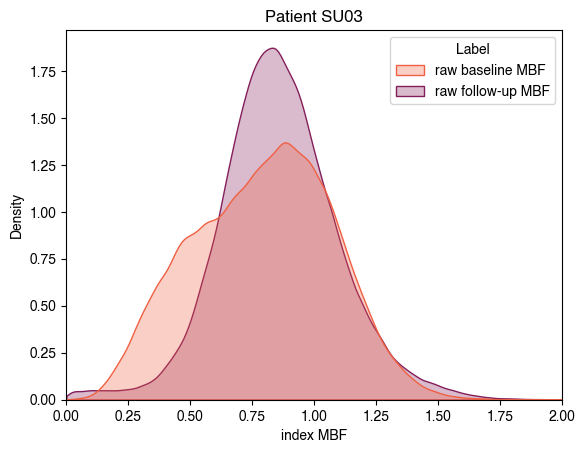

SU04


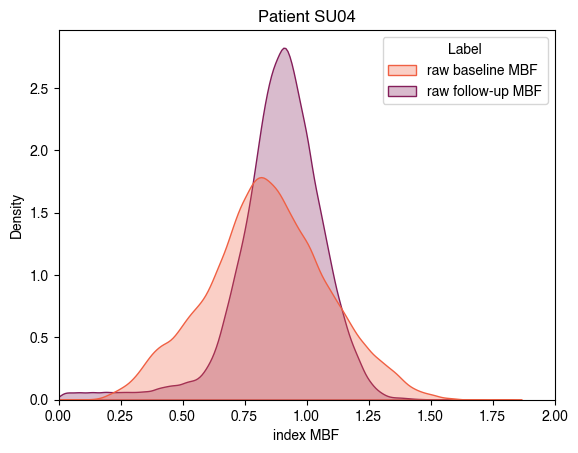

SU06


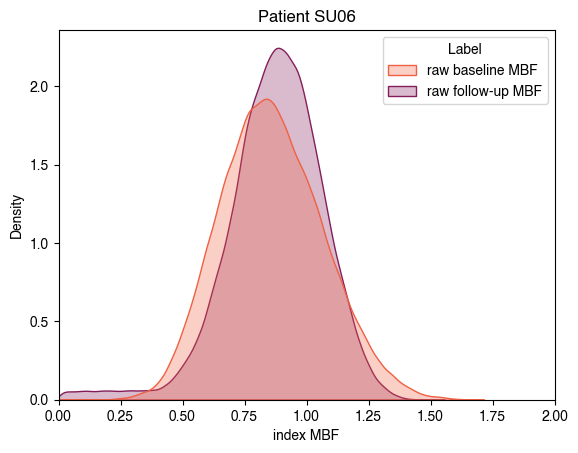

SU07


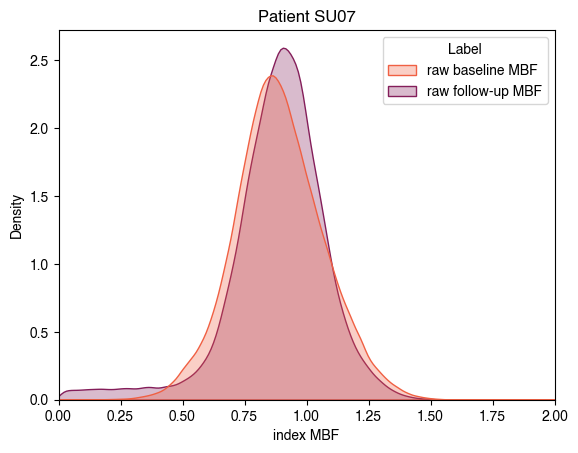

SU10


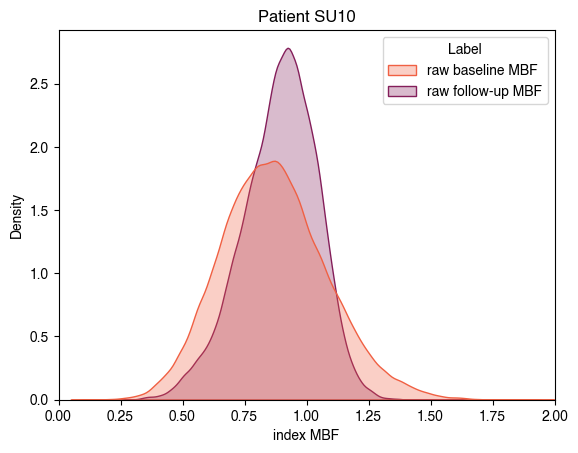

SU11


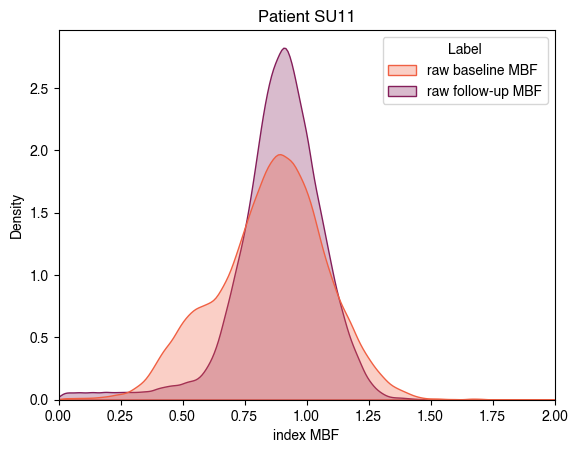

SU13


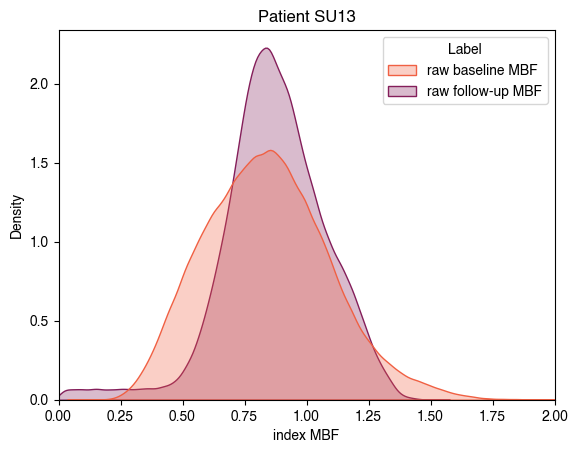

SU14


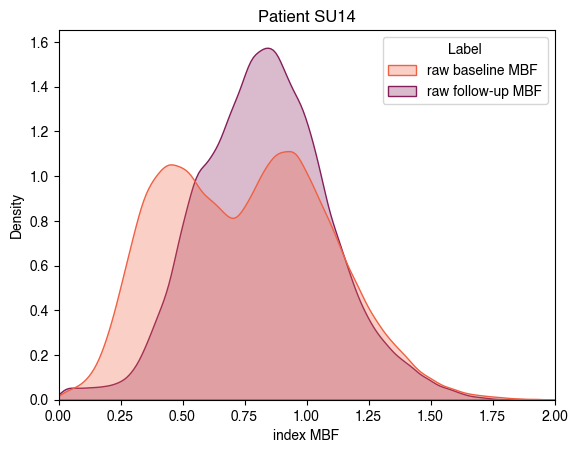

SU16


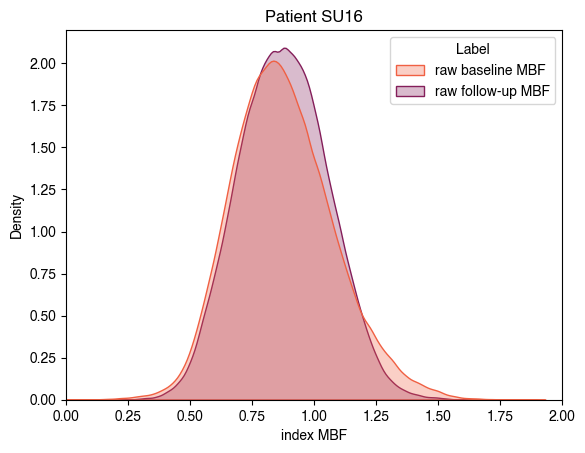

SU21


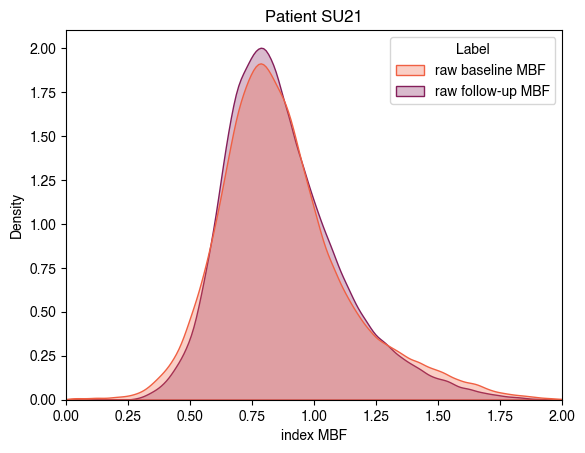

SU23


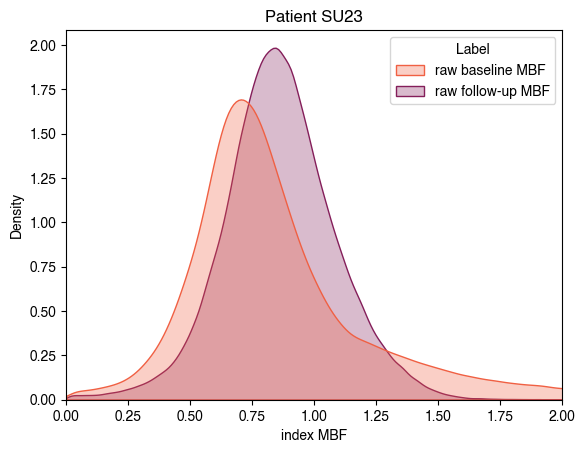

SU24


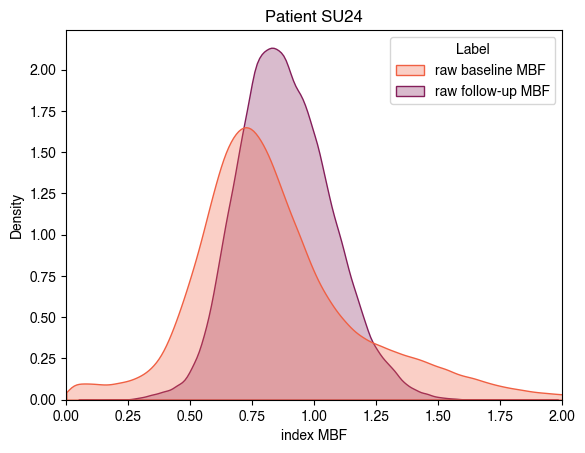

SU26


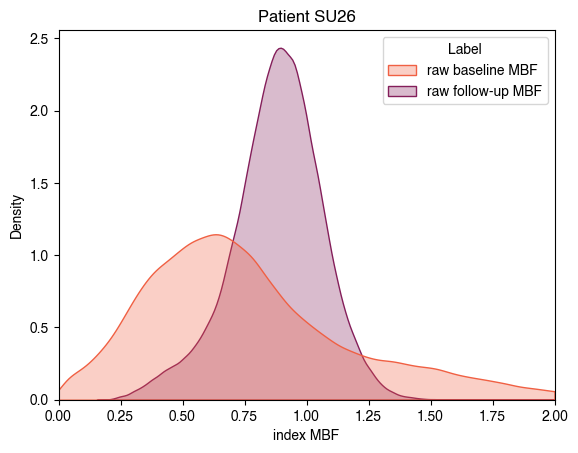

SU27


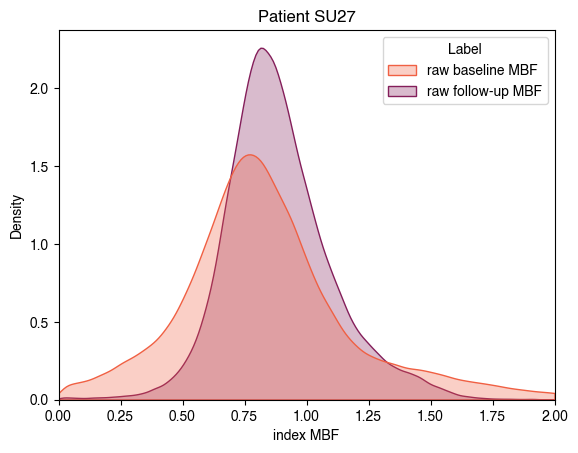

SU28


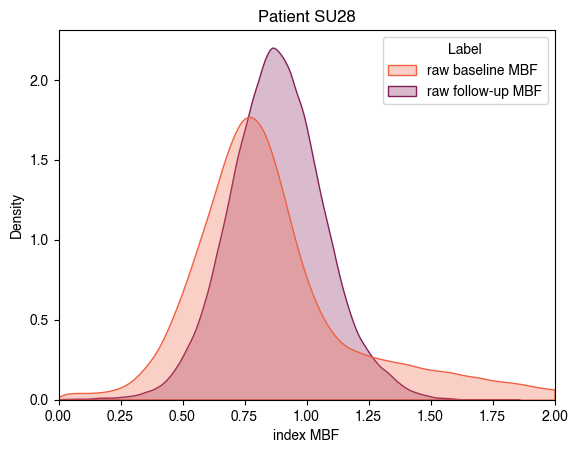

SU30


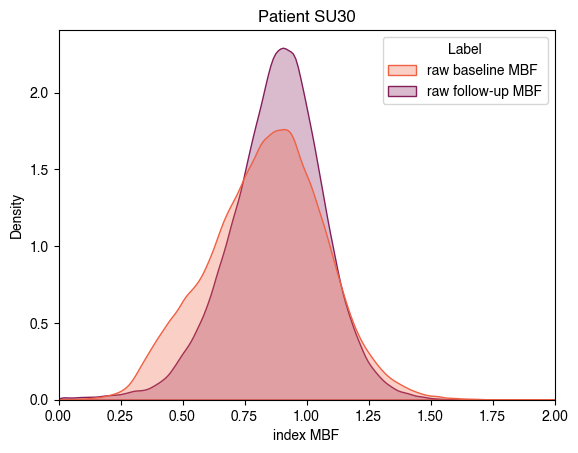

SU33


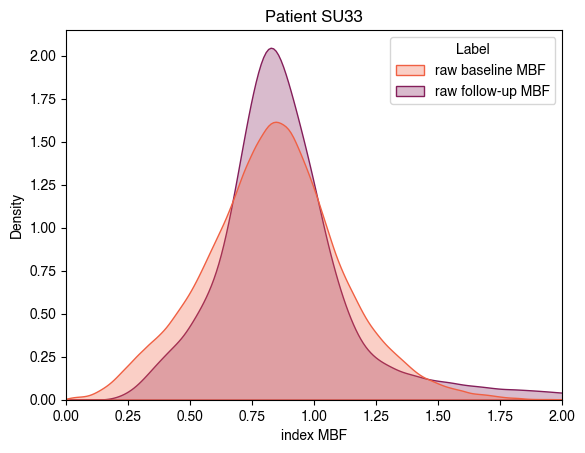

SU34


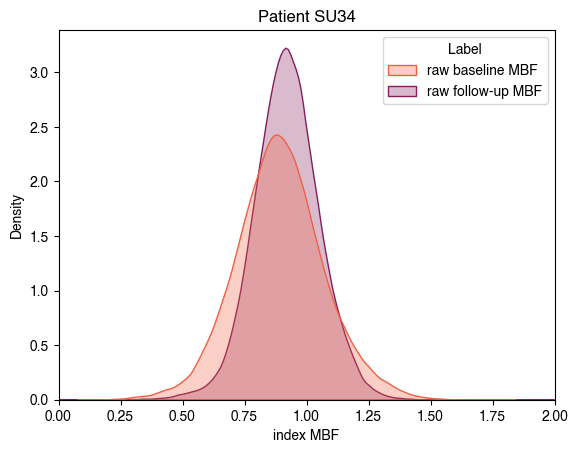

VA02


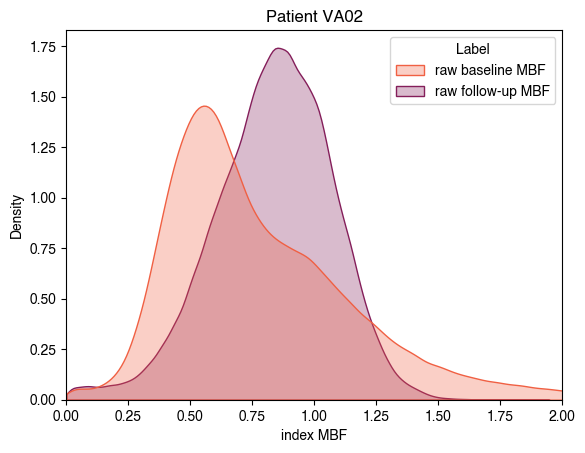

VA06


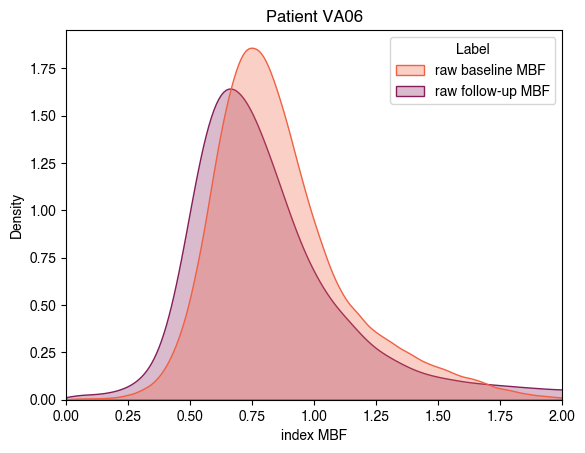

VA08


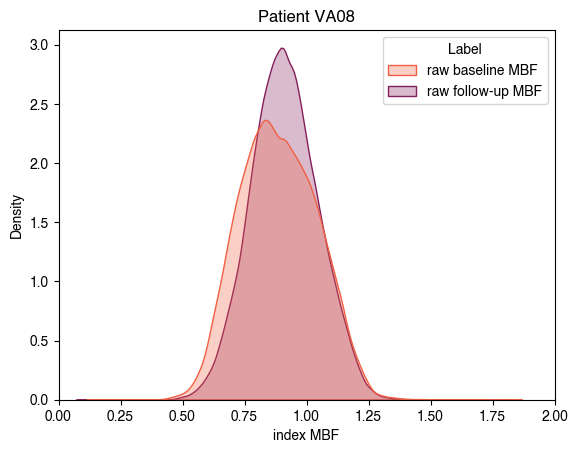

VA10


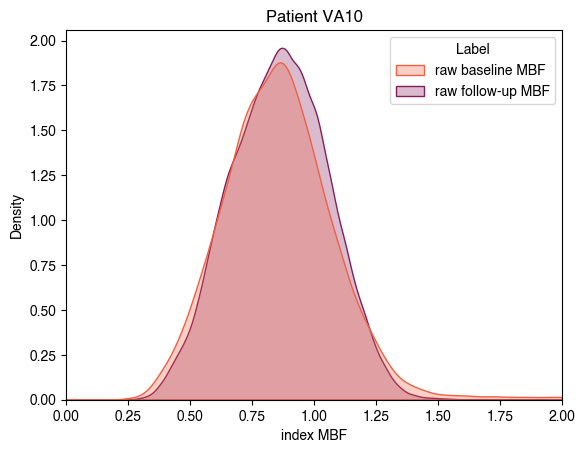

VA13


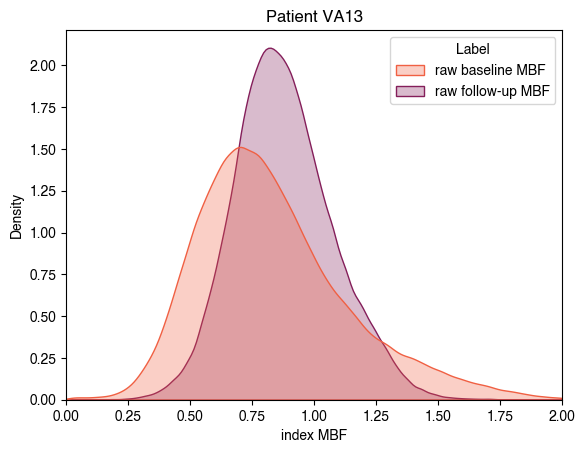

VA14


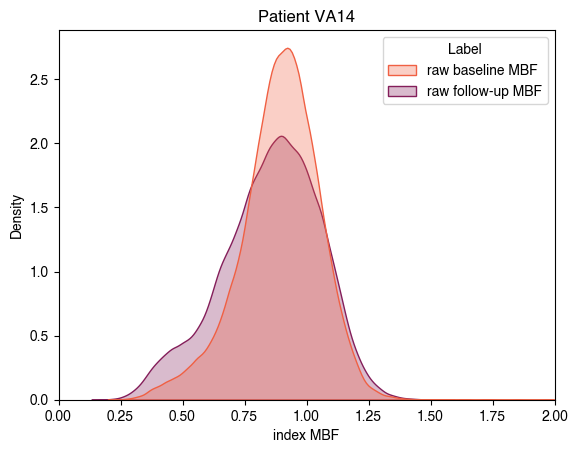

VA16


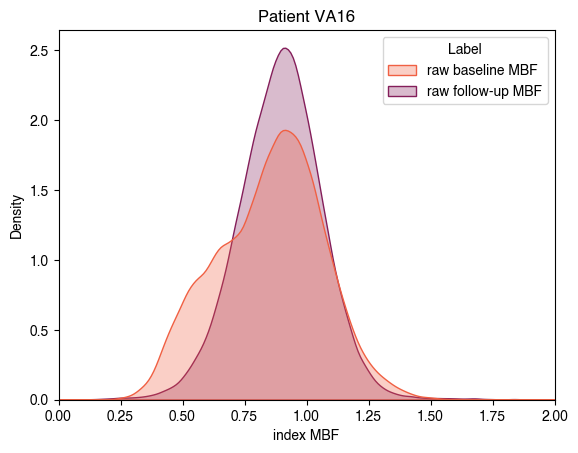

VA20


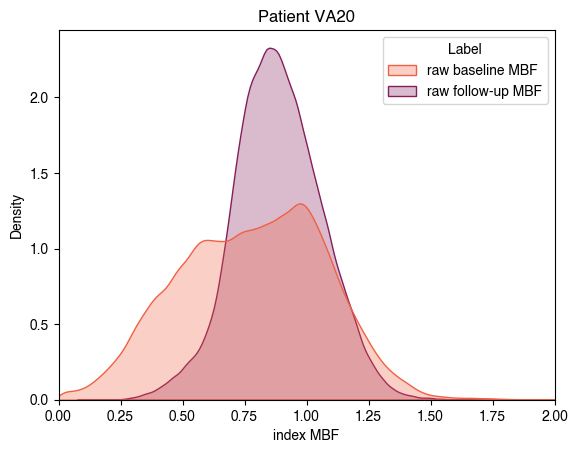

In [7]:


stats = []
for patient_id in patient_ids:
    if patient_id in Removed_Cases: 
        continue
    print(patient_id)
    VTKFiles = np.array(VTKFiles)
    out = np.where(np.char.find(VTKFiles, patient_id+'B') !=-1)
    MBF_B_unregistered = ReadVTKFile(VTKFiles[out].item())

    ScalaraArrayName = GetScalarArrayName(MBF_B_unregistered)
    MBF_B_array = vtk_to_numpy(MBF_B_unregistered.GetPointData().GetArray(ScalaraArrayName))
    MBF_B_array = MBF_B_array[MBF_B_array > 0]
    index_MBF_B = MBF_B_array/np.percentile(MBF_B_array, 75)

    out = np.where(np.char.find(VTKFiles, patient_id+'A') !=-1)
    MBF_A_unregistered = ReadVTKFile(VTKFiles[out].item())

    ScalaraArrayName = GetScalarArrayName(MBF_A_unregistered)
    MBF_A_array = vtk_to_numpy(MBF_A_unregistered.GetPointData().GetArray(ScalaraArrayName))
    MBF_A_array = MBF_A_array[MBF_A_array > 0]
    index_MBF_A = MBF_A_array/np.percentile(MBF_A_array, 75)

    stats.append({'case': patient_id, 'median_A': np.median(index_MBF_A), 'median_B': np.median(index_MBF_B), 'is_ischemic':False})

    df = pd.DataFrame({
        'MBF':np.concatenate([index_MBF_A, index_MBF_B]),
        'Label': ['raw baseline MBF'] * len(MBF_A_array) +
                ['raw follow-up MBF'] * len(MBF_B_array)
    })

    plt.figure()
    sns.kdeplot(data=df, x="MBF", hue='Label',
                    fill=True, common_norm=False, palette="rocket_r",
                alpha=.3, linewidth=1, clip=(0, 2))
    plt.xlabel('index MBF')
    plt.title(f"Patient {patient_id}")
    plt.xlim((0, 2))
    plt.show()



#### z-score mapping

SU03


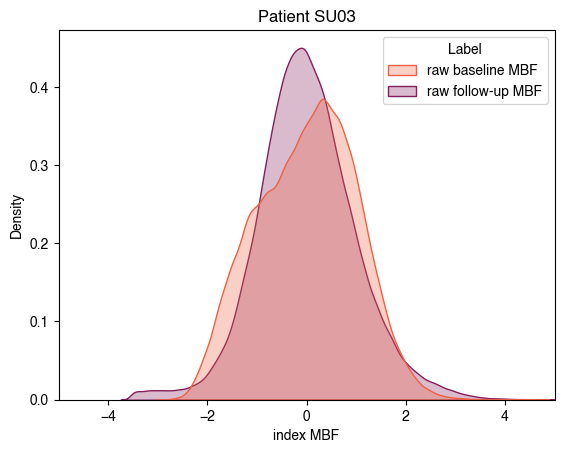

SU04


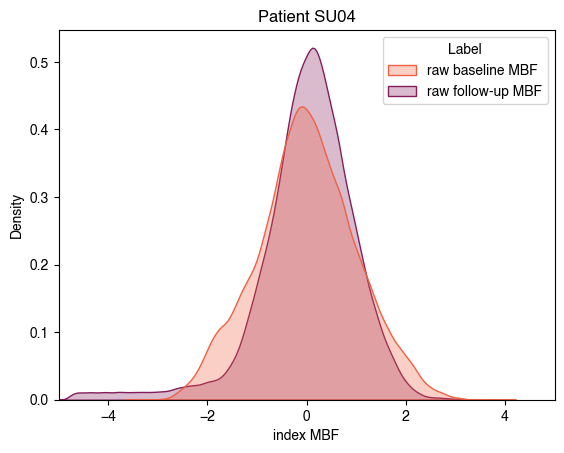

SU06


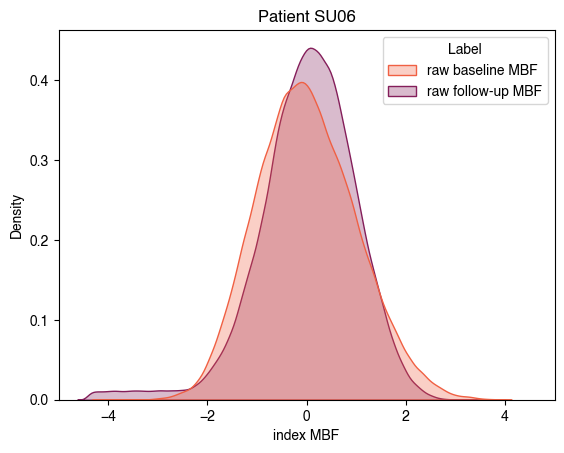

SU07


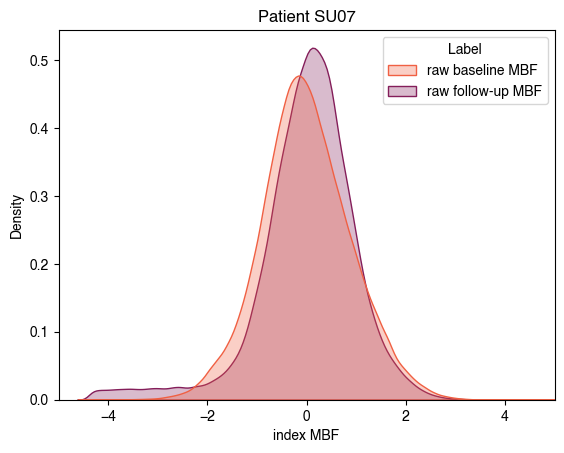

SU10


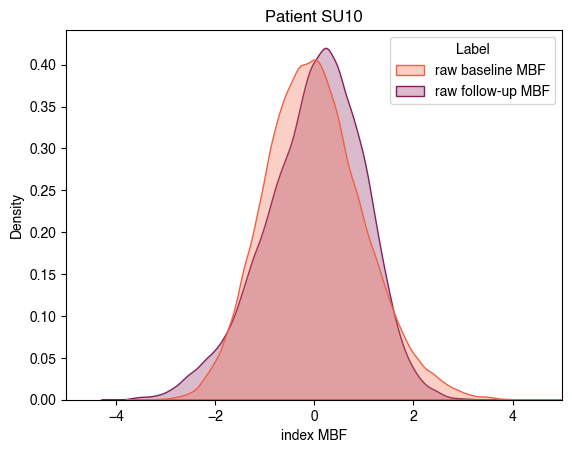

SU11


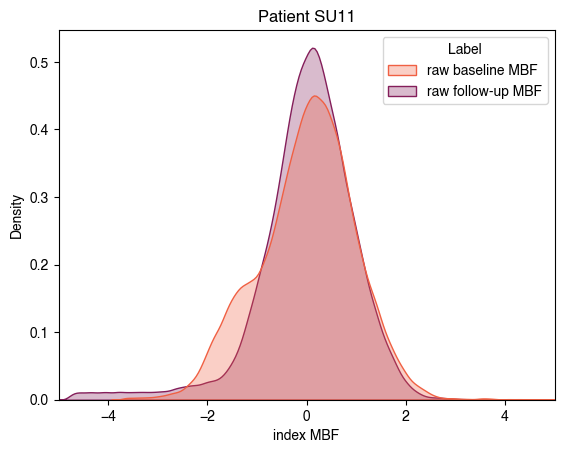

SU13


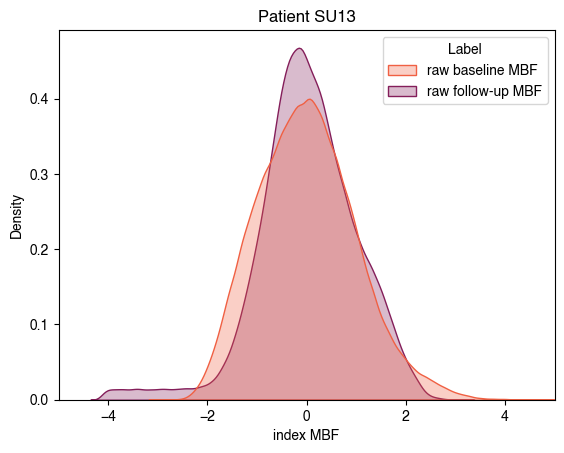

SU14


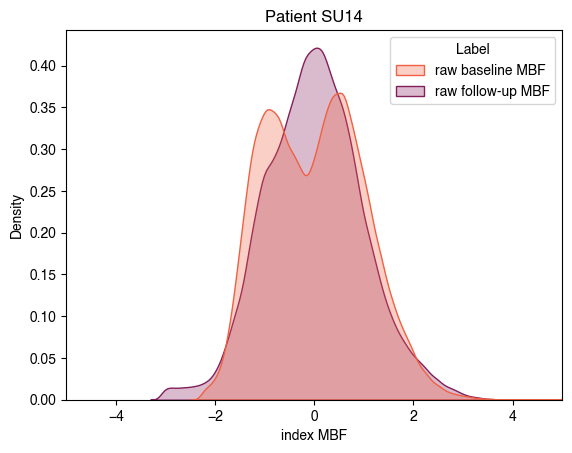

SU16


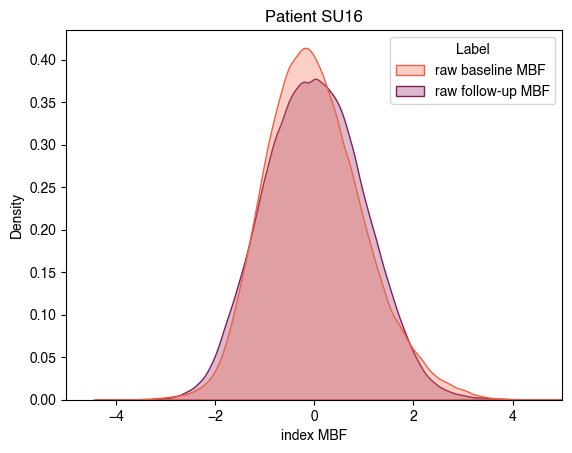

SU21


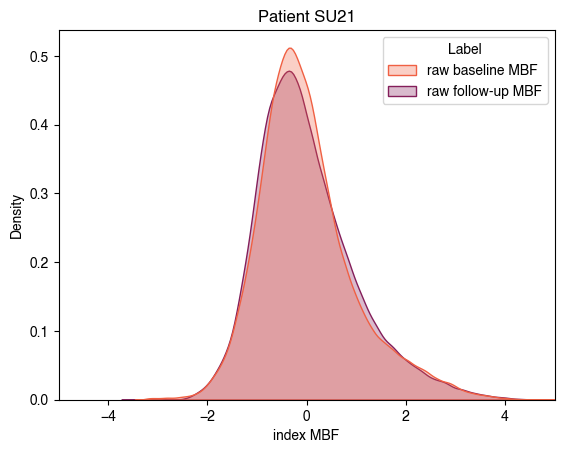

SU23


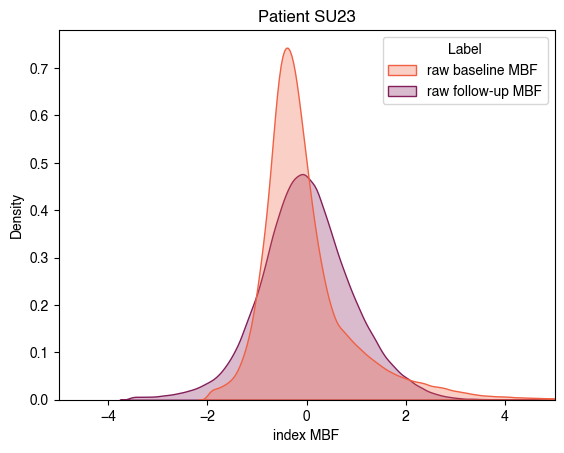

SU24


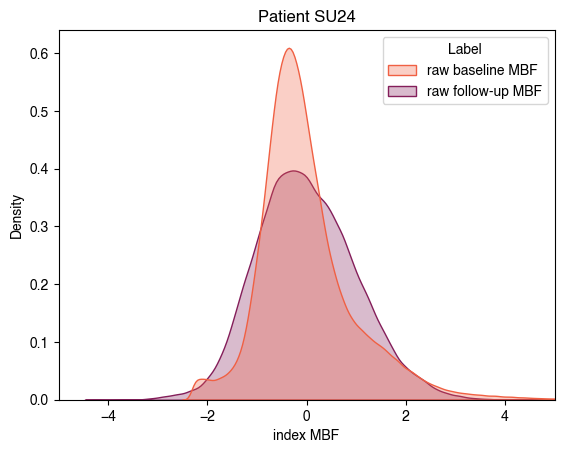

SU25


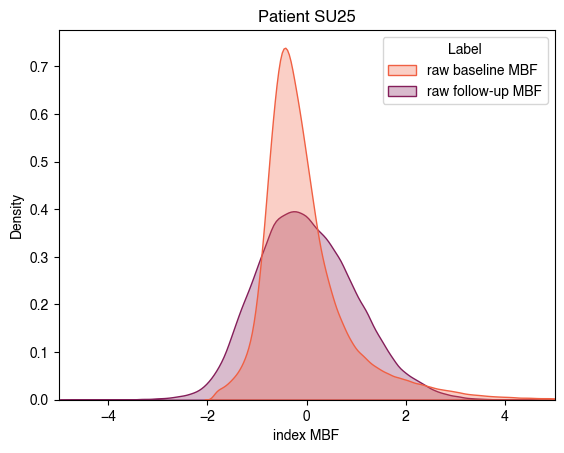

SU26


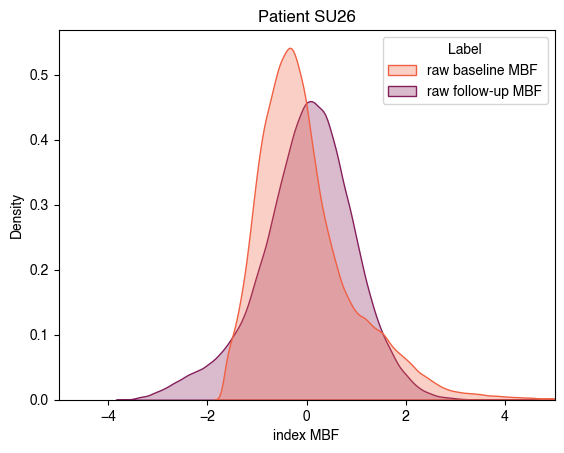

SU27


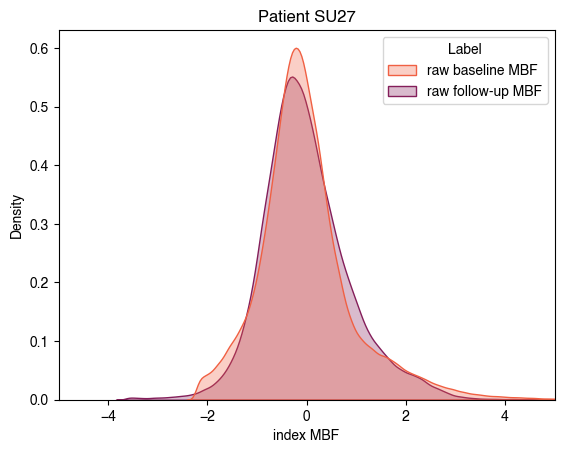

SU28


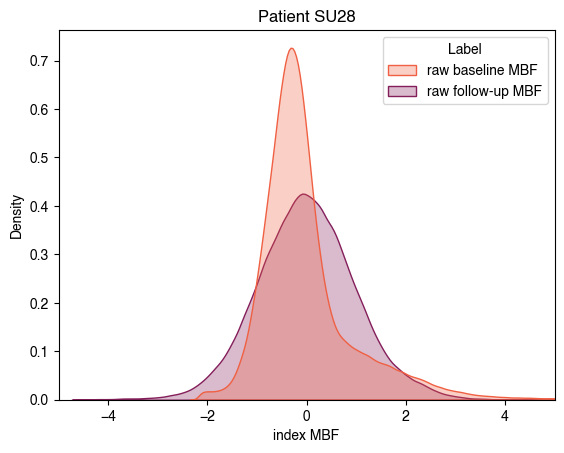

SU30


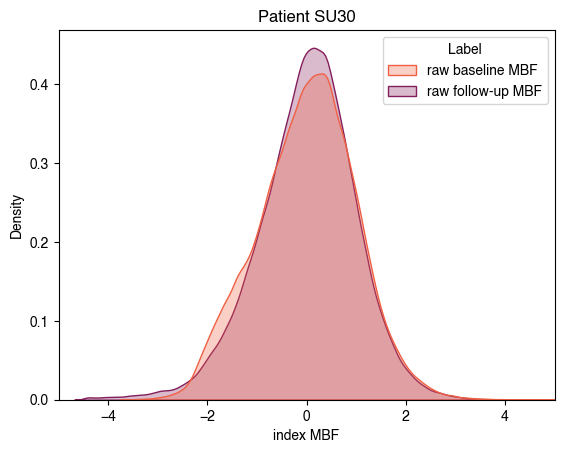

SU33


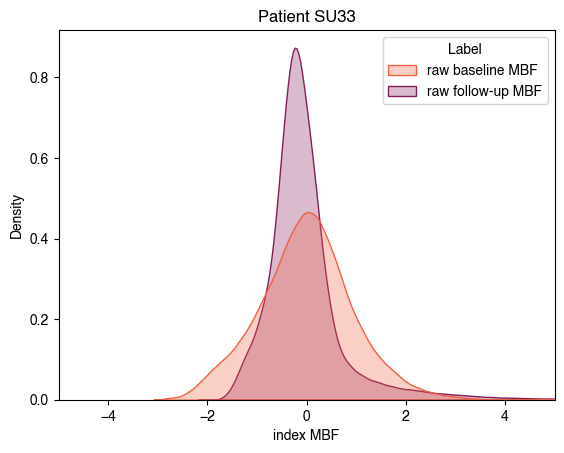

SU34


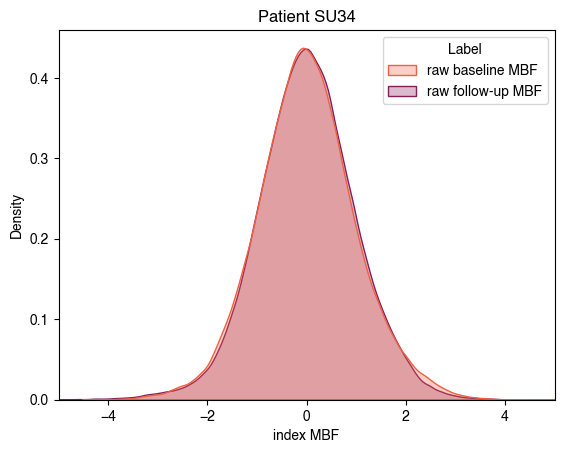

VA02


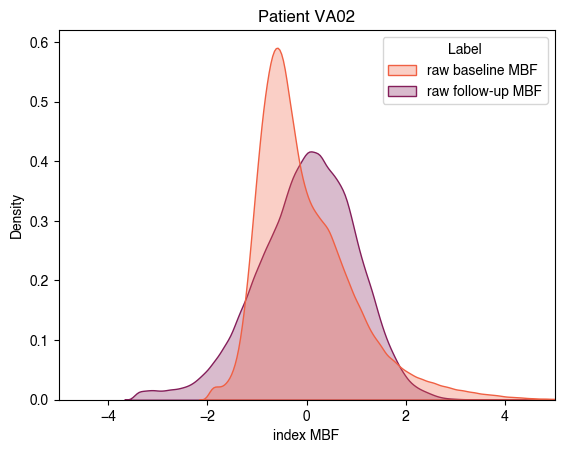

VA04


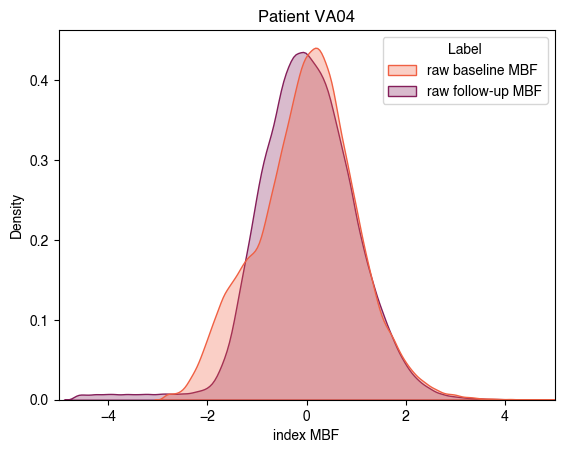

VA06


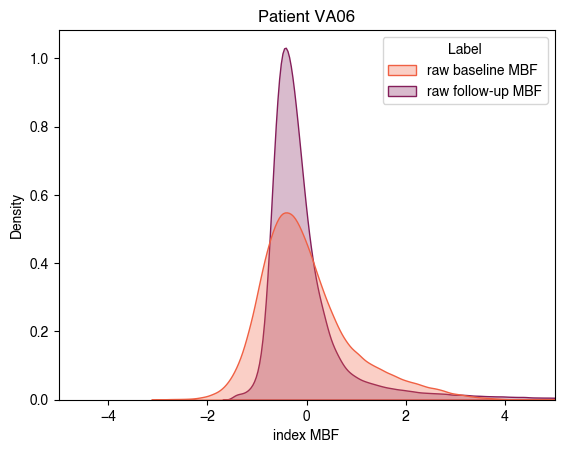

VA08


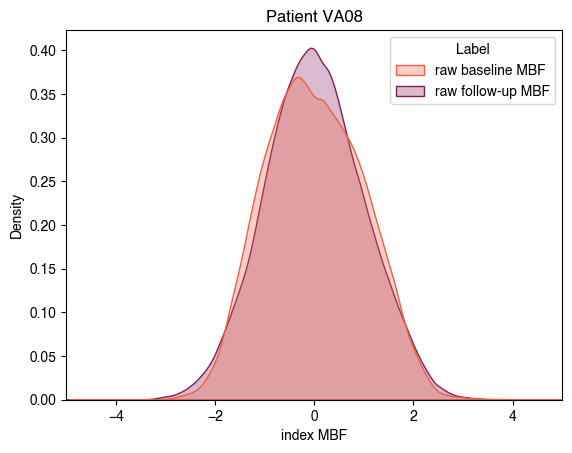

VA10


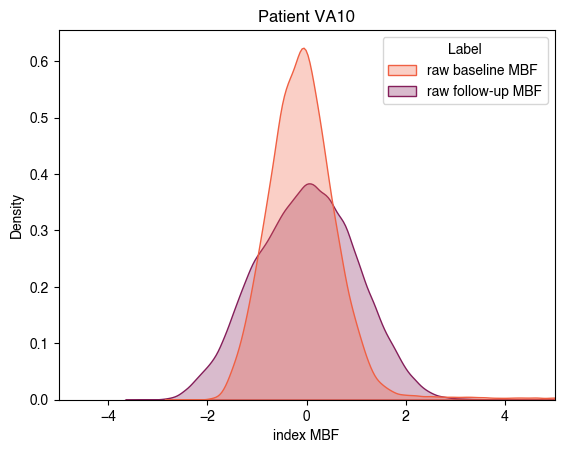

VA13


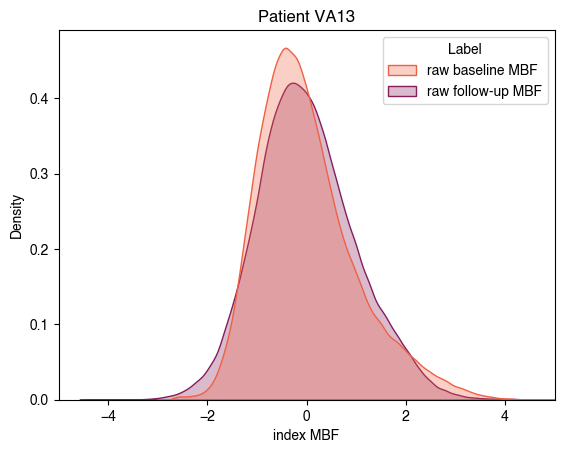

VA14


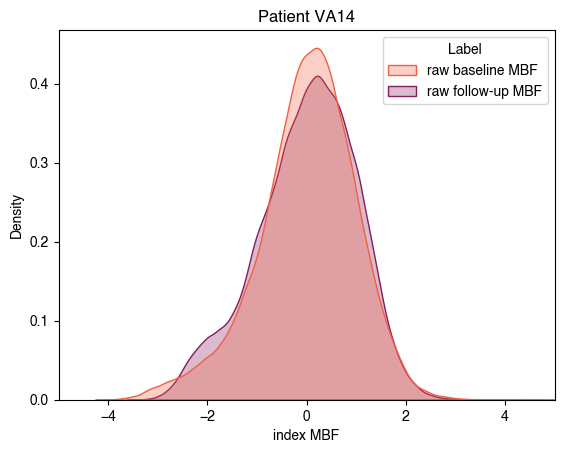

VA16


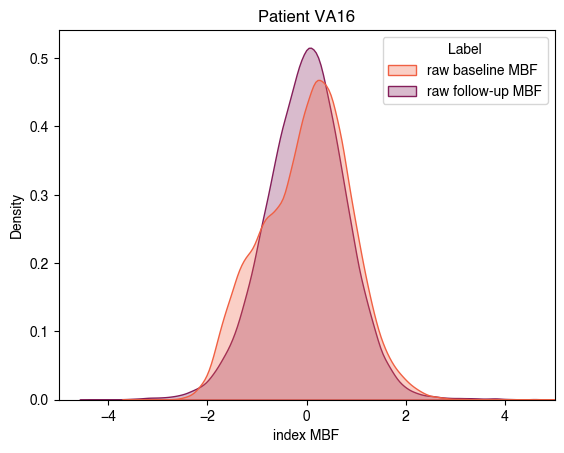

VA20


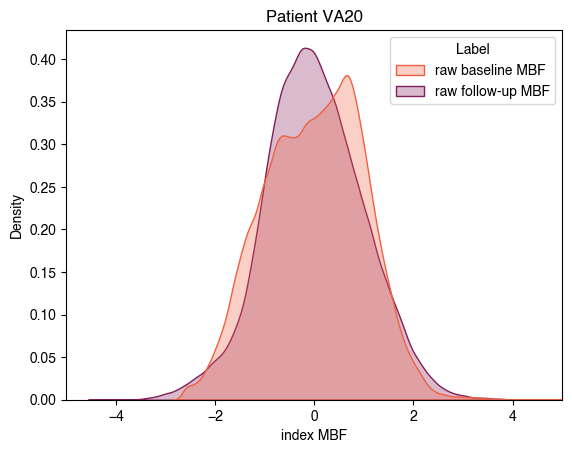

In [8]:
for patient_id in patient_ids:
    print(patient_id)
    VTKFiles = np.array(VTKFiles)
    out = np.where(np.char.find(VTKFiles, patient_id+'B') !=-1)
    MBF_B_unregistered = ReadVTKFile(VTKFiles[out].item())

    ScalaraArrayName = GetScalarArrayName(MBF_B_unregistered)
    MBF_B_array = vtk_to_numpy(MBF_B_unregistered.GetPointData().GetArray(ScalaraArrayName))
    MBF_B_array = MBF_B_array[MBF_B_array > 0]
    index_MBF_B = (MBF_B_array - np.mean(MBF_B_array))/np.std(MBF_B_array)

    out = np.where(np.char.find(VTKFiles, patient_id+'A') !=-1)
    MBF_A_unregistered = ReadVTKFile(VTKFiles[out].item())

    ScalaraArrayName = GetScalarArrayName(MBF_A_unregistered)
    MBF_A_array = vtk_to_numpy(MBF_A_unregistered.GetPointData().GetArray(ScalaraArrayName))
    MBF_A_array = MBF_A_array[MBF_A_array > 0]
    index_MBF_A = (MBF_A_array - np.mean(MBF_A_array))/np.std(MBF_A_array)

    df = pd.DataFrame({
        'MBF':np.concatenate([index_MBF_A, index_MBF_B]),
        'Label': ['raw baseline MBF'] * len(MBF_A_array) +
                ['raw follow-up MBF'] * len(MBF_B_array)
    })

    plt.figure()
    sns.kdeplot(data=df, x="MBF", hue='Label',
                    fill=True, common_norm=False, palette="rocket_r",
                alpha=.3, linewidth=1, clip=(-5,5))
    plt.xlabel('index MBF')
    plt.title(f"Patient {patient_id}")
    plt.xlim((-5, 5))
    plt.show()

### Finding regional MBF drop

In [9]:
df = pd.DataFrame({
    'class': [1, 2, 3],
    'Name': ['John', 'Joe', 'Ana'],
    'status': [False, True, True]

})


data = df.loc[df['class'] == 1, 'status']
data['status'] = True

df

,class,Name,status
0,1,John,False
1,2,Joe,True
2,3,Ana,True


In [10]:
dataMapped = []

for patient_id in patient_ids:
    if patient_id in Removed_Cases: 
        continue
    tags = list(PatientMetadata[PatientMetadata['patient-id'] == patient_id]['stenosis tag'])
    ischemia = list(PatientMetadata[PatientMetadata['patient-id'] == patient_id]['is-ischemic'])
    TerritoryTags = [f'post_{tag}' for tag in tags]
    cutoff = list(PatientMetadata[PatientMetadata['patient-id'] == patient_id]['cutoff'])[0]
    grafts = list(PatientMetadata[PatientMetadata['patient-id'] == patient_id]['graft'])
    graft_stenosis = list(PatientMetadata[PatientMetadata['patient-id'] == patient_id]['graft-stenosis'])
    if cutoff == 0:
        cutoff = 142
    for file in TerritoryLabels:
        if patient_id in os.path.basename(os.path.splitext(file)[0]):
            LabelFile = file
    MBF_Labels = ReadLabels(LabelFile, TerritoryTags)
    normalization_method = "classic"
    for file in VTUFiles:
        if f"{patient_id}A" in os.path.basename(os.path.splitext(file)[0]):
            MBF_A = ReadVTUFile(file)
        elif f"{patient_id}B" in os.path.basename(os.path.splitext(file)[0]):
            MBF_B = ReadVTUFile(file)
    AbsMBFData_A = CollectMBFData(MBF_A, MBF_Labels)
    AbsMBFData_B = CollectMBFData(MBF_B, MBF_Labels)

    t = "Non-grafted\nstenosis<50%"
    array_A = AbsMBFData_A[t]
    mean_A = np.mean(array_A)
    std_A = np.std(array_A)
    array_B = AbsMBFData_B[t]
    mean_B = np.mean(array_B)
    std_B = np.std(array_B)

    t = "Non-grafted\nstenosis>50%"
    if t in MBF_Labels.keys():
        array_A_ = AbsMBFData_A[t]
    mbf_median_non_grafted = np.median(MapNongrafted(mean_A, mean_B, std_A, std_B, np.concatenate([array_A, array_A_])))
    threshold1 = 0.9 * mbf_median_non_grafted  # 10% drop
    threshold2 = 0.8 * mbf_median_non_grafted  # 20% drop
    threshold3 = 0.7 * mbf_median_non_grafted  # 30% drop


    for i, t in enumerate(tags):
        AbsMBFData_A_mapped = MapNongrafted(mean_A, mean_B, std_A, std_B, AbsMBFData_A[t])
        mbf_median = np.median(AbsMBFData_A_mapped)
        if mbf_median > threshold1:
            is_ischemic = False
            ischemia_grade = 0
        elif threshold2 < mbf_median <= threshold1:
            is_ischemic = True
            ischemia_grade = 1
        elif threshold3 < mbf_median <= threshold2:
            is_ischemic = True
            ischemia_grade = 2
        else:
            is_ischemic = True
            ischemia_grade = 3

        data_ = {"patient_id": patient_id, "tag": t, "graft_type": grafts[i], "is_ischemic": is_ischemic, "ischemic_grade":ischemia_grade, "graft_stenosis": graft_stenosis[i], "absMBF_A": AbsMBFData_A_mapped, "absMBF_B": AbsMBFData_B[t], "rawMBF_A": AbsMBFData_A[t]}
        dataMapped.append(data_)
    t = "Non-grafted\nstenosis>50%"
    if t in MBF_Labels.keys():
        AbsMBFData_A_mapped = MapNongrafted(mean_A, mean_B, std_A, std_B, AbsMBFData_A[t])
        data_ = {"patient_id": patient_id, "tag": t, "graft_type": None, "is_ischemic": False, "ischemic_grade":0, "graft_stenosis": 0, "absMBF_A": AbsMBFData_A_mapped, "absMBF_B": AbsMBFData_B[t], "rawMBF_A": AbsMBFData_A[t]}
        dataMapped.append(data_)
    t = "Non-grafted\nstenosis<50%"
    AbsMBFData_A_mapped = MapNongrafted(mean_A, mean_B, std_A, std_B, AbsMBFData_A[t])
    data_ = {"patient_id": patient_id, "tag": t, "graft_type": None, "is_ischemic": False, "ischemic_grade":0, "graft_stenosis": 0, "absMBF_A": AbsMBFData_A_mapped, "absMBF_B": AbsMBFData_B[t], "rawMBF_A": AbsMBFData_A[t]}
    dataMapped.append(data_)

df = pd.DataFrame(dataMapped)


df

2026-04-22 19:00:54.058 ( 108.909s) [         29A4037]RuntimeDeviceInformatio:237   WARN| Initializing 'RuntimeDeviceConfigurations' with uninitialized configOptions. Did you call viskores::cont::Initialize?


,patient_id,tag,graft_type,is_ischemic,ischemic_grade,graft_stenosis,absMBF_A,absMBF_B,rawMBF_A
0,SU03,Diag,Radial,True,3,0,"[-1.58393972761084, 0.18660967361756775, -6.89...","[162.0, 155.0, 187.0, 179.0, 168.0, 162.0, 159...","[39.0, 40.0, 36.0, 38.0, 39.0, 40.0, 37.0, 35...."
1,SU03,LAD,LIMA,False,0,0,"[132.9778147657465, 134.74836416697488, 134.74...","[158.0, 158.0, 154.0, 149.0, 143.0, 148.0, 151...","[115.0, 116.0, 116.0, 117.0, 116.0, 114.0, 117..."
2,SU03,RCA,SVG,True,3,0,"[125.89561716083294, 118.81341955591941, 109.9...","[154.0, 159.0, 175.0, 91.0, 93.0, 96.0, 229.0,...","[111.0, 107.0, 102.0, 78.0, 95.0, 78.0, 88.0, ..."
3,SU03,Non-grafted\nstenosis>50%,NaN,False,0,0,"[28.515400093271722, 40.909245901870435, 53.30...","[74.0, 74.0, 75.0, 79.0, 86.0, 94.0, 103.0, 11...","[56.0, 63.0, 70.0, 79.0, 88.0, 96.0, 105.0, 11..."
4,SU03,Non-grafted\nstenosis<50%,NaN,False,0,0,"[125.89561716083294, 125.89561716083294, 122.3...","[111.0, 123.0, 139.0, 126.0, 107.0, 106.0, 110...","[111.0, 111.0, 109.0, 109.0, 109.0, 109.0, 109..."
...,...,...,...,...,...,...,...,...,...
102,VA16,Non-grafted\nstenosis<50%,NaN,False,0,0,"[35.473983359094106, 9.21962141633233, 19.9158...","[201.0, 204.0, 288.0, 285.0, 128.0, 134.0, 386...","[55.0, 28.0, 39.0, 15.0, 52.0, 75.0, 38.0, 58...."
103,VA20,LAD,LIMA,True,3,0,"[-59.00010222006746, -94.40367607944468, -88.5...","[221.0, 145.0, 185.0, 129.0, 33.0, 80.0, 9.0, ...","[33.0, 15.0, 18.0, 30.0, 27.0, 15.0, 19.0, 30...."
104,VA20,LCx,SVG,False,0,0,"[31.47569764278542, 11.80704549868696, -1.9610...","[42.0, 41.0, 42.0, 45.0, 46.0, 34.0, 29.0, 46....","[79.0, 69.0, 62.0, 59.0, 58.0, 60.0, 62.0, 64...."
105,VA20,RCA,SVG,True,3,0,"[125.88522793445799, 125.88522793445799, 125.8...","[6.0, 8.0, 15.0, 5.0, 90.0, 92.0, 88.0, 88.0, ...","[127.0, 127.0, 127.0, 123.0, 99.0, 94.0, 101.0..."


In [11]:
set(df[df["ischemic_grade"] == 3]["patient_id"])

{'SU03', 'SU04', 'SU11', 'SU13', 'SU14', 'SU30', 'VA20'}

In [12]:
np.unique(df[df["ischemic_grade"] == 2]["patient_id"])

array(['SU07', 'SU10', 'SU11', 'SU13', 'SU26', 'SU27', 'SU30', 'SU33'],
      dtype=object)

In [13]:
np.setdiff1d(np.unique(df[df["ischemic_grade"] == 2]["patient_id"]),np.unique(df[df["ischemic_grade"] == 3]["patient_id"]))

array(['SU07', 'SU10', 'SU26', 'SU27', 'SU33'], dtype=object)

In [14]:
np.setdiff1d(np.unique(df[df["ischemic_grade"] == 1]["patient_id"]), np.unique(df[df["ischemic_grade"] > 1]["patient_id"]))

array(['SU06', 'VA10', 'VA16'], dtype=object)

In [15]:
diseased = np.unique(df[df["ischemic_grade"] > 0]["patient_id"])
diseased

array(['SU03', 'SU04', 'SU06', 'SU07', 'SU10', 'SU11', 'SU13', 'SU14',
       'SU26', 'SU27', 'SU30', 'SU33', 'VA10', 'VA16', 'VA20'],
      dtype=object)

In [16]:
non_ischemic = np.setdiff1d(df[df["ischemic_grade"] == 0]["patient_id"], diseased)
non_ischemic

array(['SU16', 'SU21', 'SU23', 'SU24', 'SU28', 'SU34', 'VA02', 'VA06',
       'VA08', 'VA13', 'VA14'], dtype=object)

In [17]:
stats = pd.DataFrame(stats)


In [18]:
stats.loc[stats['case'].isin(diseased), 'is_ischemic'] = True
stats

,case,median_A,median_B,is_ischemic
0,SU03,0.806452,0.849057,True
1,SU04,0.837321,0.900000,True
2,SU06,0.850575,0.883978,True
3,SU07,0.878049,0.894737,True
4,SU10,0.860656,0.906542,True
5,SU11,0.867257,0.900000,True
6,SU13,0.833333,0.870504,True
7,SU14,0.756098,0.827815,True
8,SU16,0.857143,0.874419,False
9,SU21,0.836066,0.834146,False


In [19]:
median_ischemic_A = stats.loc[stats['is_ischemic'] == True, 'median_A']
median_ischemic_B = stats.loc[stats['is_ischemic'] == True, 'median_B']

WilcoxonTest(median_ischemic_A, median_ischemic_B)

Wilcoxon test statistics:  0.0
p-value:  6.103515625e-05
number of datapoints: 15
Reject the null hypothesis: There is a significant difference between the two samples.


np.float64(6.103515625e-05)

In [20]:
median_nonischemic_A = stats.loc[stats['is_ischemic'] == False, 'median_A']
median_nonischemic_B = stats.loc[stats['is_ischemic'] == False, 'median_B']

WilcoxonTest(median_nonischemic_A, median_nonischemic_B)

Wilcoxon test statistics:  12.0
p-value:  0.0673828125
number of datapoints: 11
Fail to reject the null hypothesis: There is no significant difference between the two samples.


np.float64(0.0673828125)

### Mapping Pre on Post

SU03


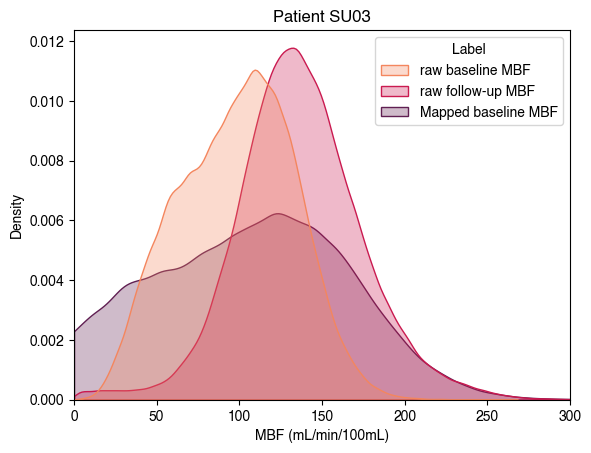

SU04


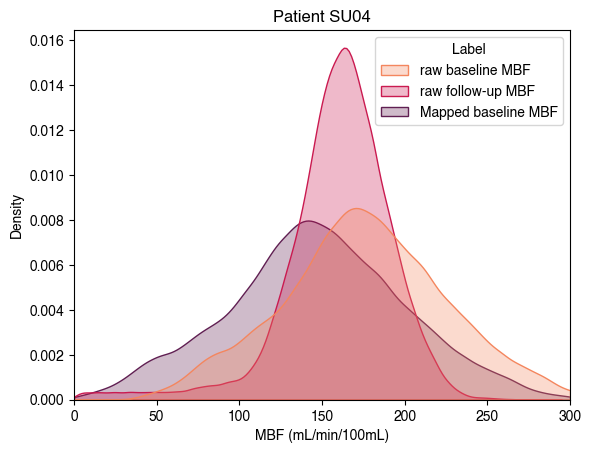

SU06


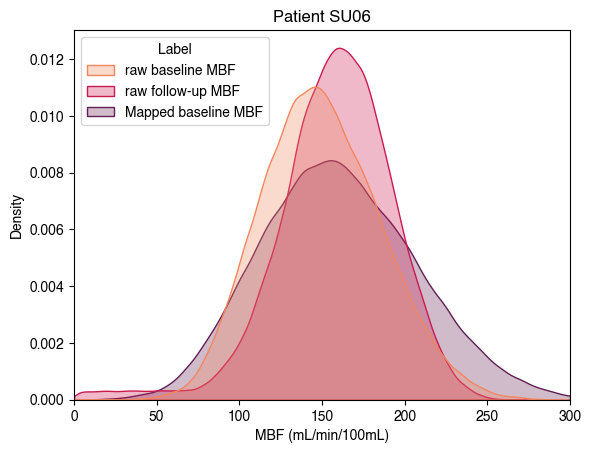

SU07


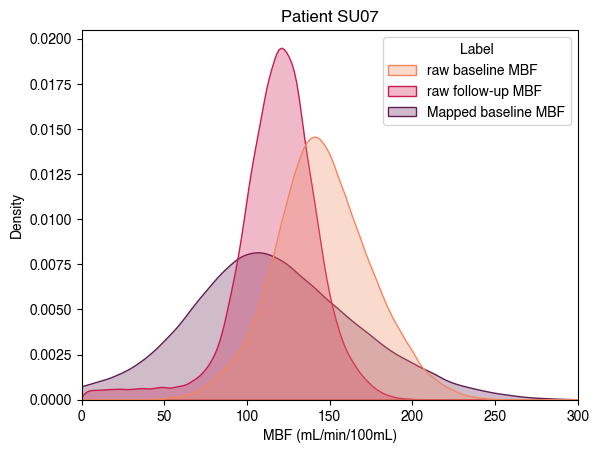

SU10


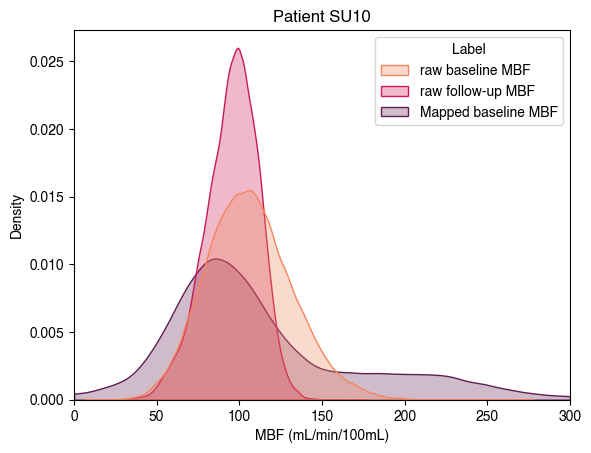

SU11


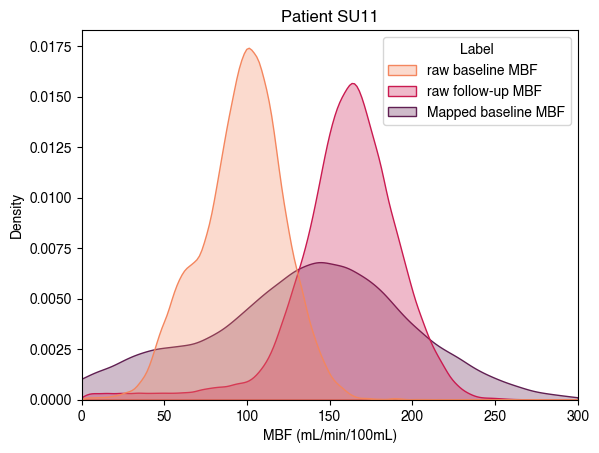

SU13


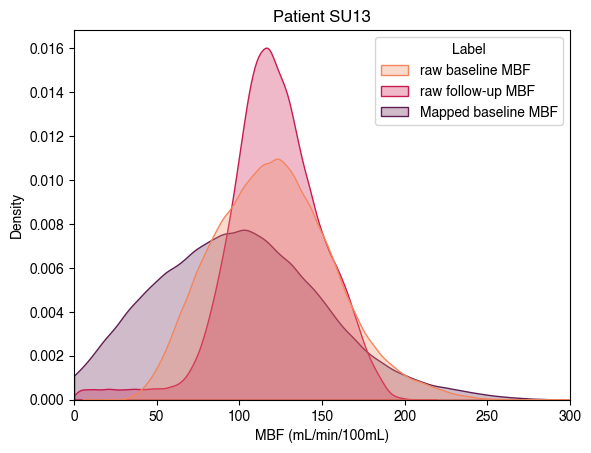

SU14


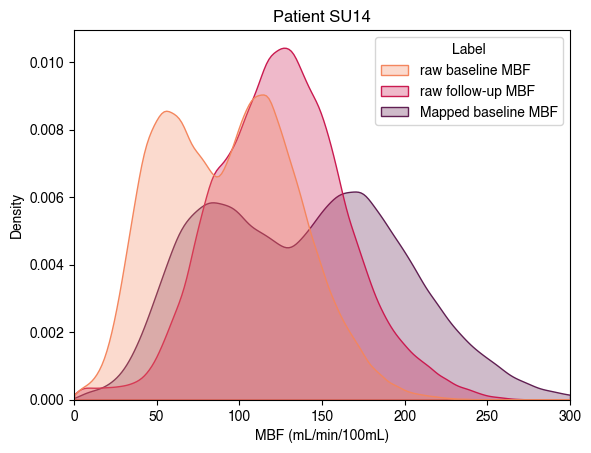

SU16


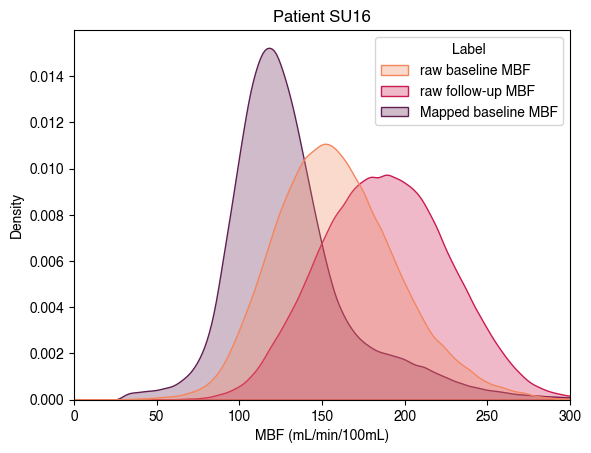

SU21


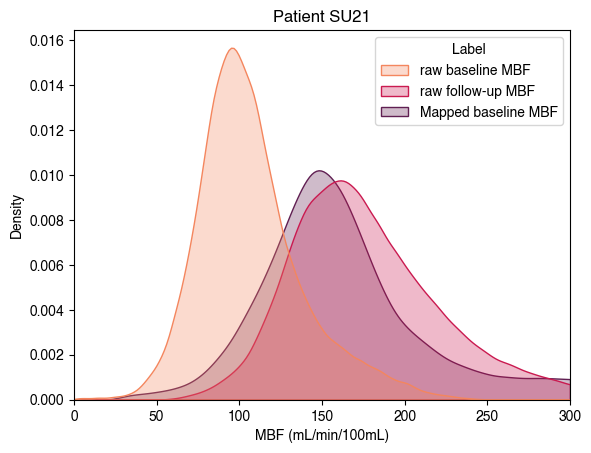

SU23


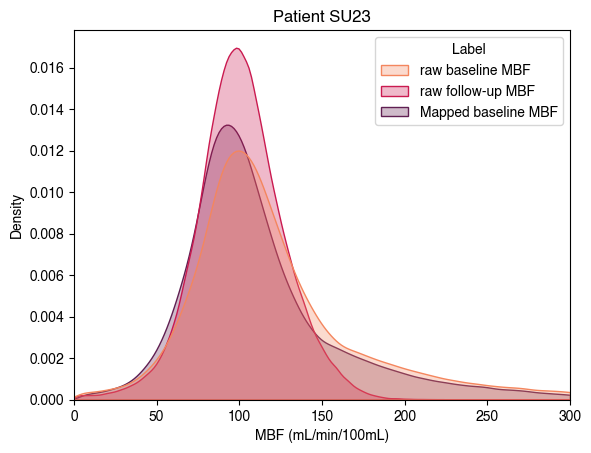

SU24


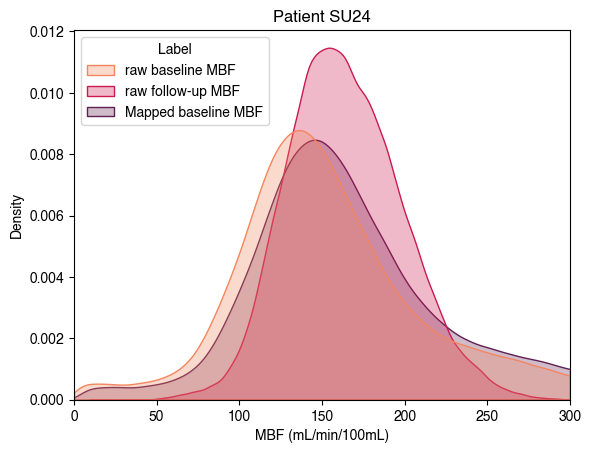

SU25


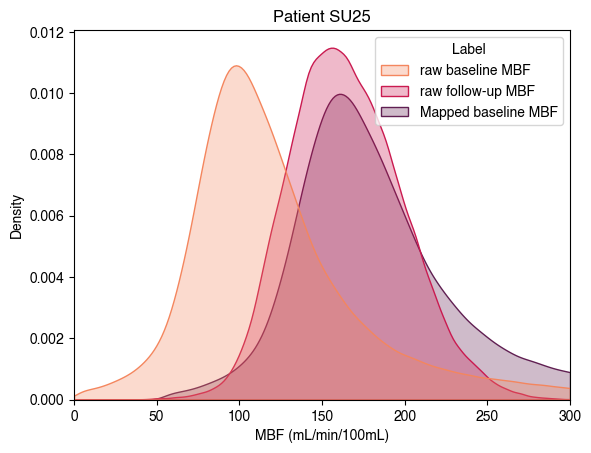

SU26


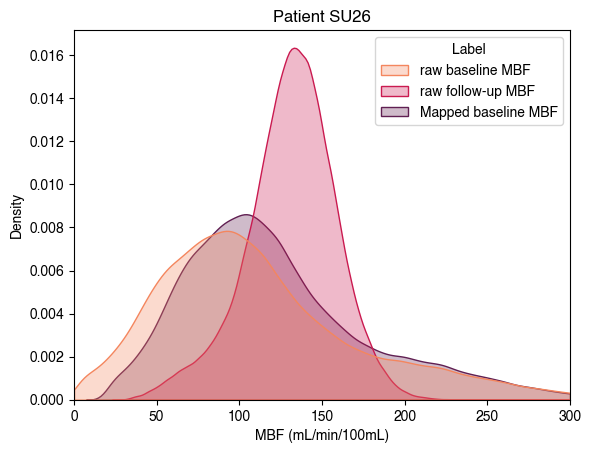

SU27


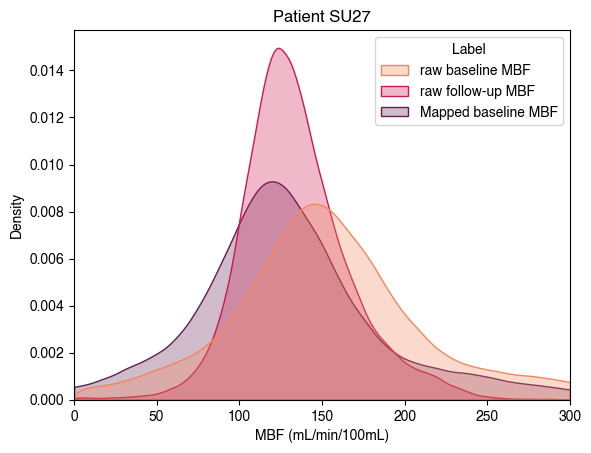

SU28


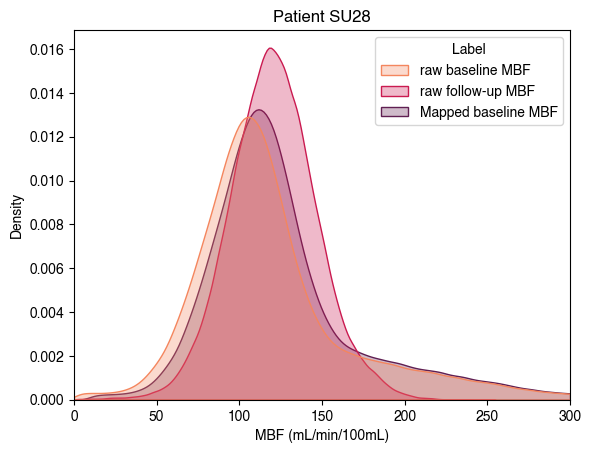

SU30


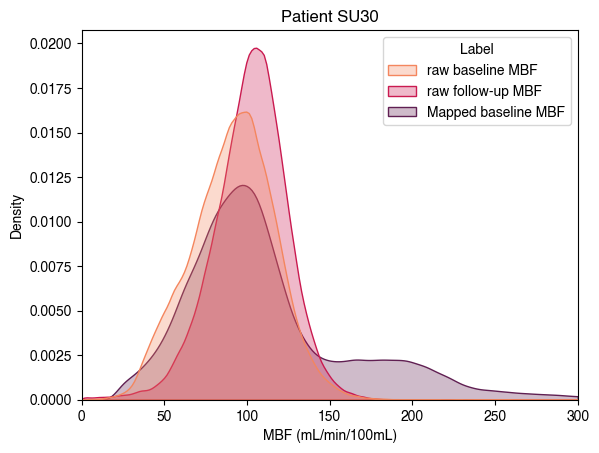

SU33


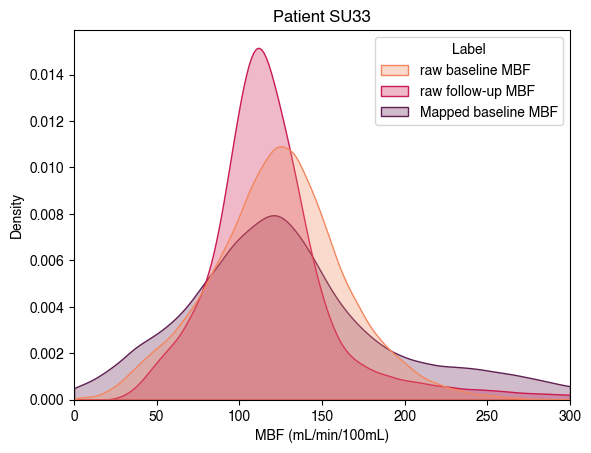

SU34


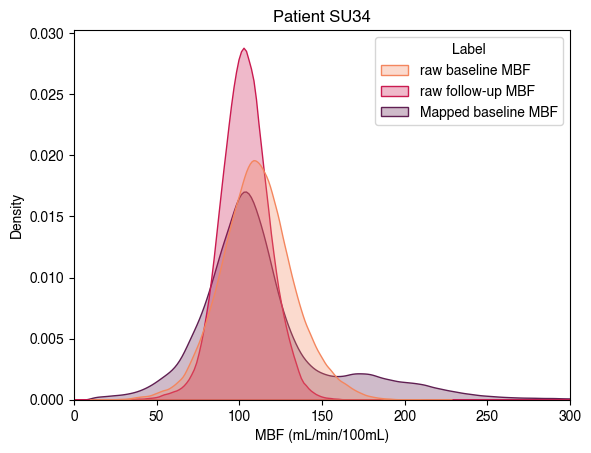

VA02


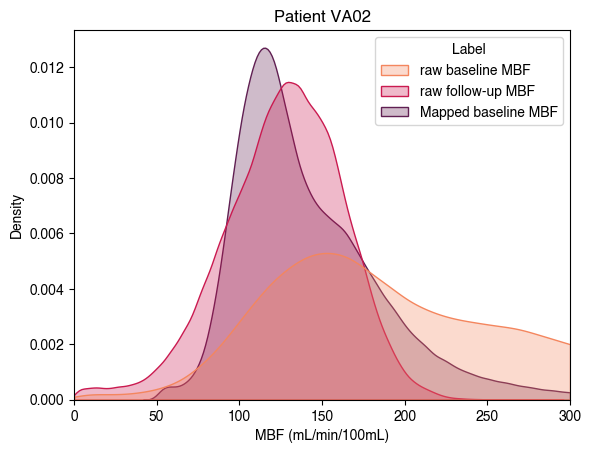

VA04


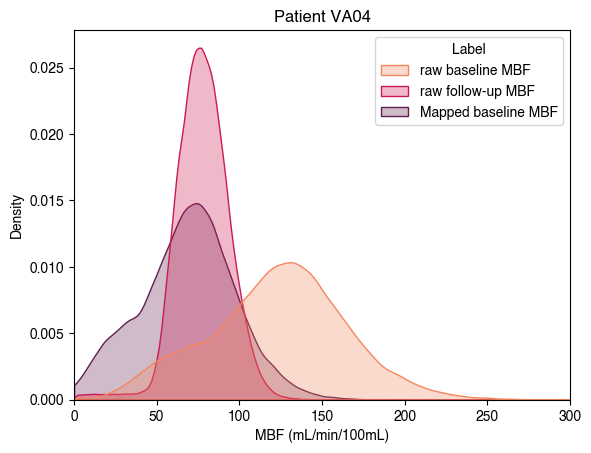

VA06


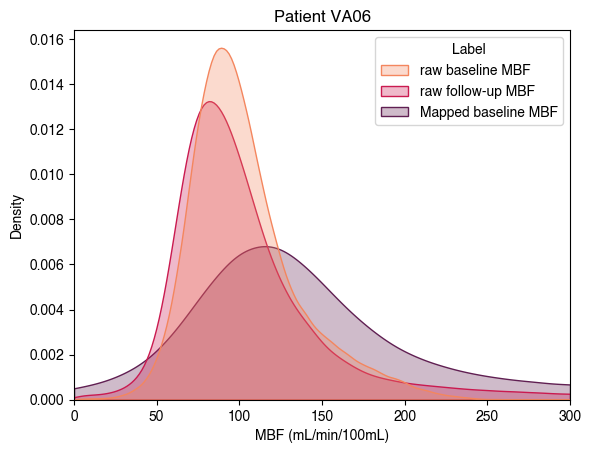

VA08


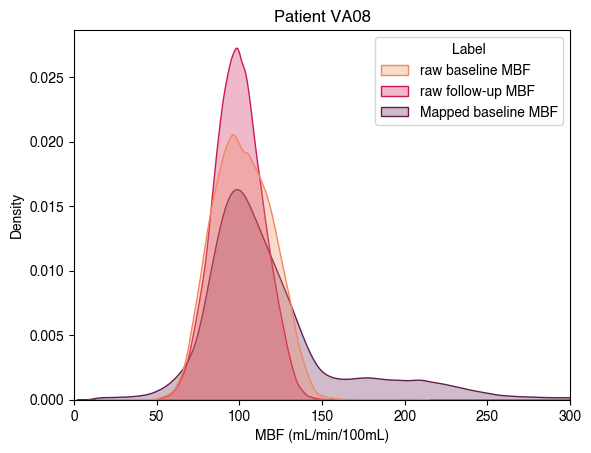

VA10


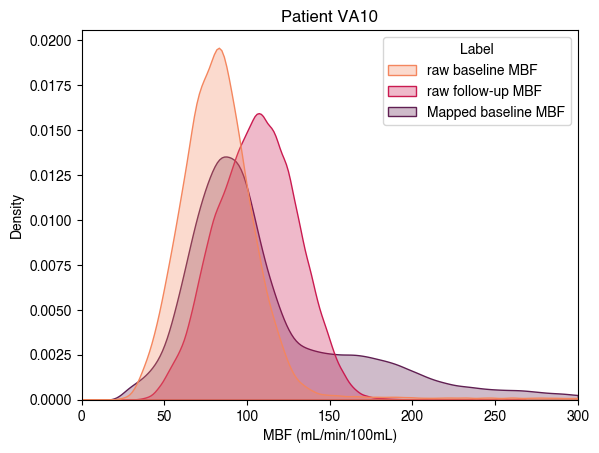

VA13


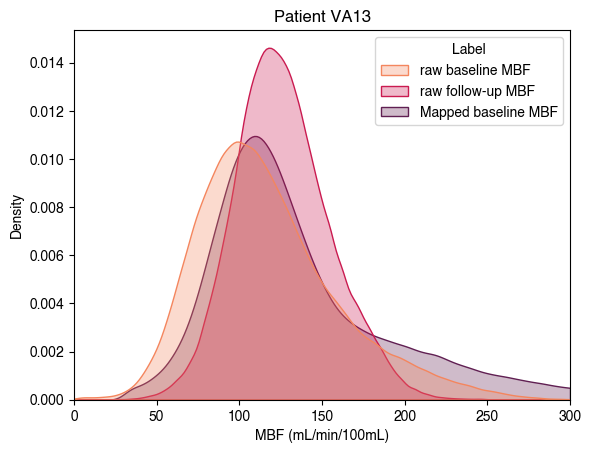

VA14


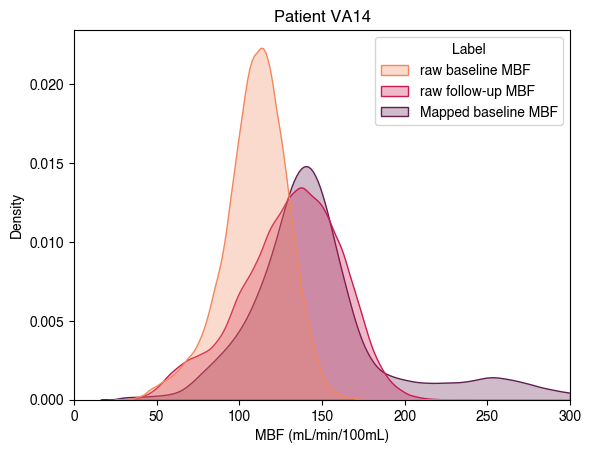

VA16


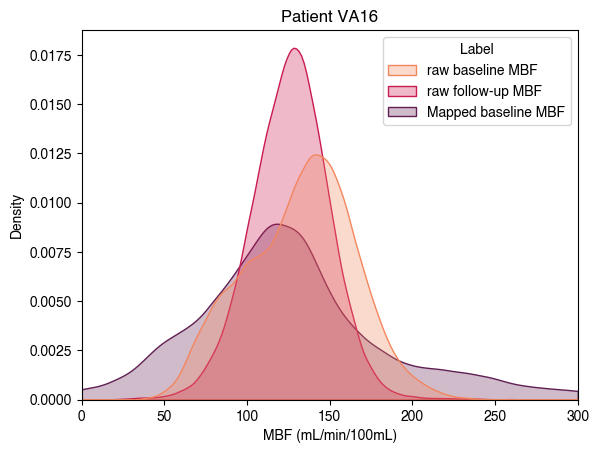

VA20


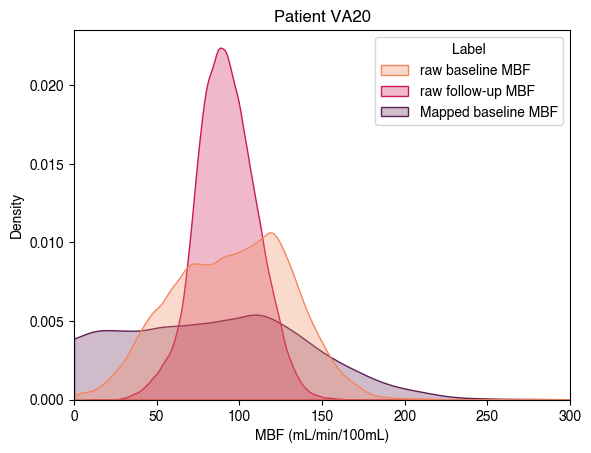

In [21]:
for patient_id in patient_ids:
    print(patient_id)
    VTKFiles = np.array(VTKFiles)
    out = np.where(np.char.find(VTKFiles, patient_id+'B') !=-1)
    MBF_B_unregistered = ReadVTKFile(VTKFiles[out].item())

    ScalaraArrayName = GetScalarArrayName(MBF_B_unregistered)
    MBF_B_array = vtk_to_numpy(MBF_B_unregistered.GetPointData().GetArray(ScalaraArrayName))
    MBF_B_array = MBF_B_array[MBF_B_array > 0]
    index_MBF_B = MBF_B_array/np.percentile(MBF_B_array, 75)

    out = np.where(np.char.find(VTKFiles, patient_id+'A') !=-1)
    MBF_A_unregistered = ReadVTKFile(VTKFiles[out].item())

    ScalaraArrayName = GetScalarArrayName(MBF_A_unregistered)
    MBF_A_array = vtk_to_numpy(MBF_A_unregistered.GetPointData().GetArray(ScalaraArrayName))
    MBF_A_array = MBF_A_array[MBF_A_array > 0]
    index_MBF_A = MBF_A_array/np.percentile(MBF_A_array, 75)


    tags = list(PatientMetadata[PatientMetadata['patient-id'] == patient_id]['stenosis tag'])
    TerritoryTags = [f'post_{tag}' for tag in tags]
    for file in TerritoryLabels:
        if patient_id in os.path.basename(os.path.splitext(file)[0]):
            LabelFile = file
    MBF_Labels = ReadLabels(LabelFile, TerritoryTags)

    for file in VTUFiles:
        if f"{patient_id}A" in os.path.basename(os.path.splitext(file)[0]):
            MBF_A = ReadVTUFile(file)
        elif f"{patient_id}B" in os.path.basename(os.path.splitext(file)[0]):
            MBF_B = ReadVTUFile(file)
    AbsMBFData_A = CollectMBFData(MBF_A, MBF_Labels)
    AbsMBFData_B = CollectMBFData(MBF_B, MBF_Labels)
    t = "Non-grafted\nstenosis<50%"
    array_A = AbsMBFData_A[t]
    mean_A = np.mean(array_A)
    std_A = np.std(array_A)
    array_B = AbsMBFData_B[t]
    mean_B = np.mean(array_B)
    std_B = np.std(array_B)

    MBF_A_array2_name = GetScalarArrayName(MBF_A)
    MBF_A_array2 = vtk_to_numpy(MBF_A.GetPointData().GetArray(MBF_A_array2_name))
    MBF_A_array2 = MapNongrafted(mean_A, mean_B, std_A, std_B, MBF_A_array2)
    #MBF_A_array2 /= np.percentile(MBF_A_array2, 75)


    df = pd.DataFrame({
        'MBF':np.concatenate([MBF_A_array, MBF_B_array, MBF_A_array2]),
        'Label': ['raw baseline MBF'] * len(MBF_A_array) +
                ['raw follow-up MBF'] * len(MBF_B_array) +
                ['Mapped baseline MBF'] * len(MBF_A_array2)
    })

    plt.figure()
    sns.kdeplot(data=df, x="MBF", hue='Label',
                    fill=True, common_norm=False, palette="rocket_r",
                alpha=.3, linewidth=1, clip=(0, 300))
    plt.xlabel('MBF (mL/min/100mL)')
    plt.title(f"Patient {patient_id}")
    plt.xlim((0, 300))
    plt.show()

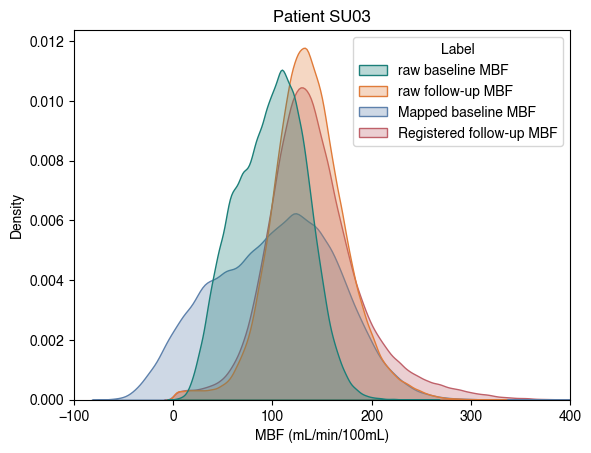

In [22]:
patient_id = 'SU03'
VTKFiles = np.array(VTKFiles)
out = np.where(np.char.find(VTKFiles, patient_id+'B') !=-1)
MBF_B_unregistered = ReadVTKFile(VTKFiles[out].item())

ScalaraArrayName = GetScalarArrayName(MBF_B_unregistered)
MBF_B_array = vtk_to_numpy(MBF_B_unregistered.GetPointData().GetArray(ScalaraArrayName))
MBF_B_array = MBF_B_array[MBF_B_array > 0]
index_MBF_B = MBF_B_array/np.percentile(MBF_B_array, 75)


VTUFiles = np.array(VTUFiles)
out = np.where(np.char.find(VTUFiles, patient_id+'B') != -1)
MBF_B = ReadVTUFile(VTUFiles[out].item())

ScalarArrayName = GetScalarArrayName(MBF_B)
MBF_B_array_registered = vtk_to_numpy(MBF_B.GetPointData().GetArray(ScalarArrayName))

out = np.where(np.char.find(VTKFiles, patient_id+'A') !=-1)
MBF_A_unregistered = ReadVTKFile(VTKFiles[out].item())

ScalaraArrayName = GetScalarArrayName(MBF_A_unregistered)
MBF_A_array = vtk_to_numpy(MBF_A_unregistered.GetPointData().GetArray(ScalaraArrayName))
MBF_A_array = MBF_A_array[MBF_A_array > 0]
index_MBF_A = MBF_A_array/np.percentile(MBF_A_array, 75)


tags = list(PatientMetadata[PatientMetadata['patient-id'] == patient_id]['stenosis tag'])
TerritoryTags = [f'post_{tag}' for tag in tags]
for file in TerritoryLabels:
    if patient_id in os.path.basename(os.path.splitext(file)[0]):
        LabelFile = file
MBF_Labels = ReadLabels(LabelFile, TerritoryTags)

out = np.where(np.char.find(VTUFiles, patient_id+'A') != -1)
MBF_A = ReadVTUFile(VTUFiles[out].item())

AbsMBFData_A = CollectMBFData(MBF_A, MBF_Labels)
AbsMBFData_B = CollectMBFData(MBF_B, MBF_Labels)
t = "Non-grafted\nstenosis<50%"
array_A = AbsMBFData_A[t]
mean_A = np.mean(array_A)
std_A = np.std(array_A)
array_B = AbsMBFData_B[t]
mean_B = np.mean(array_B)
std_B = np.std(array_B)

MBF_A_array2_name = GetScalarArrayName(MBF_A)
MBF_A_array2 = vtk_to_numpy(MBF_A.GetPointData().GetArray(MBF_A_array2_name))
MBF_A_array2 = MapNongrafted(mean_A, mean_B, std_A, std_B, MBF_A_array2)
#MBF_A_array2 /= np.percentile(MBF_A_array2, 75)


df = pd.DataFrame({
    'MBF':np.concatenate([MBF_A_array, MBF_B_array, MBF_A_array2, MBF_B_array_registered]),
    'Label': ['raw baseline MBF'] * len(MBF_A_array) +
            ['raw follow-up MBF'] * len(MBF_B_array) +
            ['Mapped baseline MBF'] * len(MBF_A_array2) +
            ['Registered follow-up MBF'] * len(MBF_B_array_registered)
})

palette = {
    'raw baseline MBF': '#1B7F79',
    'raw follow-up MBF': '#E07B39',
    'Mapped baseline MBF': '#5E81AC',
    'Registered follow-up MBF': '#BF616A'
}

plt.figure()
sns.kdeplot(data=df, x="MBF", hue='Label',
                fill=True, common_norm=False, palette=palette,
            alpha=.3, linewidth=1, clip=(-100, 400))
plt.xlabel('MBF (mL/min/100mL)')
plt.title(f"Patient {patient_id}")
plt.xlim((-100, 400))
plt.show()





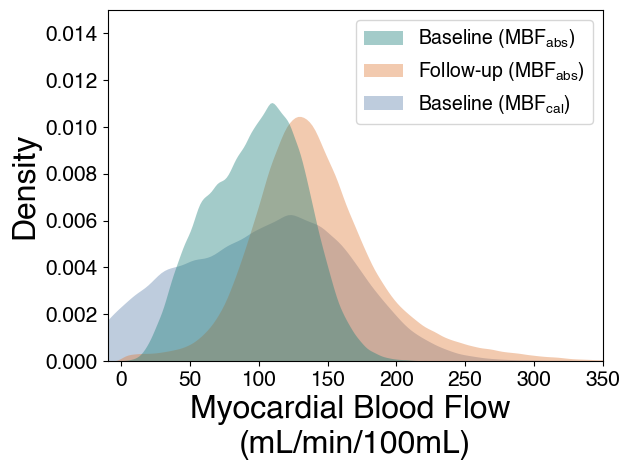

In [23]:
df = pd.DataFrame({
    'MBF':np.concatenate([MBF_A_array, MBF_B_array_registered, MBF_A_array2]),
    'Label': ['Baseline ($\\mathrm{MBF_{abs}}$)'] * len(MBF_A_array) +
            ['Follow-up ($\\mathrm{MBF_{abs}}$)'] * len(MBF_B_array_registered) +
            ['Baseline ($\\mathrm{MBF_{cal}}$)'] * len(MBF_A_array2)
})

palette = {
    'Baseline ($\\mathrm{MBF_{abs}}$)': '#1B7F79',
    'Follow-up ($\\mathrm{MBF_{abs}}$)': '#E07B39',
    'Baseline ($\\mathrm{MBF_{cal}}$)': '#5E81AC',
}

plt.rcParams['legend.fontsize'] = 14
plt.figure()
ax = sns.kdeplot(data=df, x="MBF", hue=df['Label'].tolist(),
                fill=True, common_norm=False, palette=palette,
            alpha=.4, linewidth=0, clip=(-100, 400))
ax.set_xlabel("Myocardial Blood Flow \n(mL/min/100mL)", fontsize = 23)
ax.set_ylabel("Density", fontsize = 23)
#ax.legend()
#plt.title(f"Patient {patient_id}")
plt.xlim((-10, 350))
plt.ylim((0, 0.015))
plt.xticks(fontsize=15)
plt.yticks(fontsize=15)
plt.tight_layout()
plt.show()

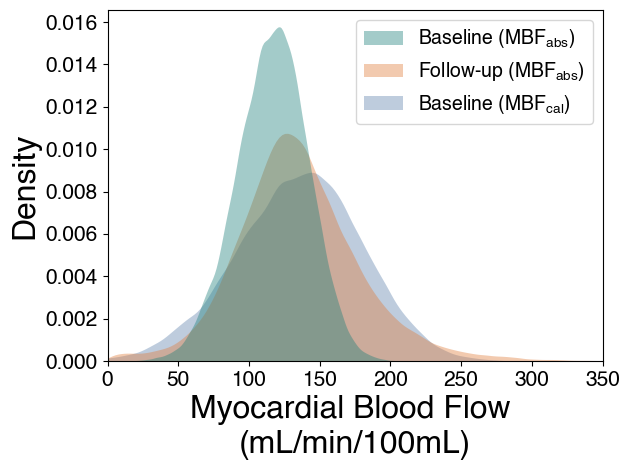

In [24]:
t = "Non-grafted\nstenosis<50%"

df = pd.DataFrame({
    'MBF':np.concatenate([AbsMBFData_A[t], AbsMBFData_B[t], MapNongrafted(mean_A, mean_B, std_A, std_B, AbsMBFData_A[t])]),
    'Label': ['Baseline ($\\mathrm{MBF_{abs}}$)'] * len(AbsMBFData_A[t]) +
            ['Follow-up ($\\mathrm{MBF_{abs}}$)'] * len(AbsMBFData_B[t]) +
            ['Baseline ($\\mathrm{MBF_{cal}}$)'] * len(AbsMBFData_A[t])
})

palette = {
    'Baseline ($\\mathrm{MBF_{abs}}$)': '#1B7F79',
    'Follow-up ($\\mathrm{MBF_{abs}}$)': '#E07B39',
    'Baseline ($\\mathrm{MBF_{cal}}$)': '#5E81AC',
}

plt.rcParams['legend.fontsize'] = 14
plt.figure()
ax = sns.kdeplot(data=df, x="MBF", hue=df['Label'].tolist(),
                fill=True, common_norm=False, palette=palette,
            alpha=.4, linewidth=0, clip=(-100, 400))
ax.set_xlabel("Myocardial Blood Flow \n(mL/min/100mL)", fontsize = 23)
ax.set_ylabel("Density", fontsize = 23)
#ax.legend()
#plt.title("Distribution of the not grafted regions")
plt.xlim((0, 350))
#plt.ylim((0, 0.015))
plt.xticks(fontsize=15)
plt.yticks(fontsize=15)
plt.tight_layout()
plt.show()

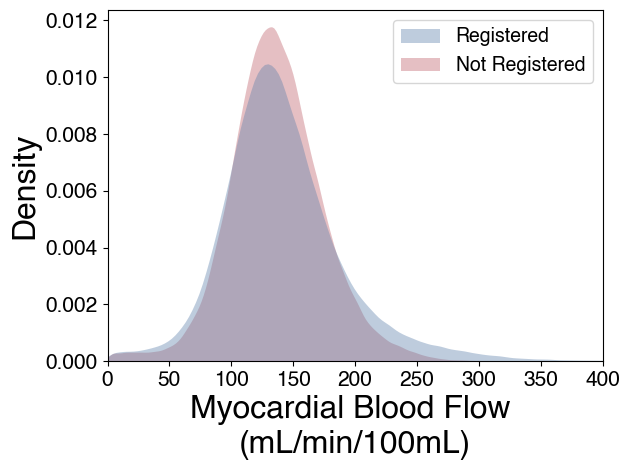

In [25]:
new_path = os.path.join(nr_path, "Registered/*.vtk")
vtk_file = glob.glob(new_path)[0]
MBF_B_new_registration = ReadVTKFile(vtk_file)
ScalarArrayName = GetScalarArrayName(MBF_B_new_registration)
MBF_B_array_registered_new = vtk_to_numpy(MBF_B_new_registration.GetPointData().GetArray(ScalarArrayName))


df = pd.DataFrame({
    'MBF':np.concatenate([MBF_B_array_registered, MBF_B_array]),
    'Label':['Registered'] * len(MBF_B_array_registered) +
            ['Not Registered'] * len(MBF_B_array)
})

palette = {
    'Registered': '#5E81AC',
    'Not Registered': '#BF616A'
}

plt.rcParams['legend.fontsize'] = 14
plt.figure()
ax = sns.kdeplot(data=df, x="MBF", hue=df['Label'].tolist(),
                fill=True, common_norm=False, palette=palette,
            alpha=.4, linewidth=0)
ax.set_xlabel("Myocardial Blood Flow \n(mL/min/100mL)", fontsize = 23)
ax.set_ylabel("Density", fontsize = 23)
#ax.legend()
#plt.title(f"Patient {patient_id}")
plt.xlim((0, 400))
#plt.ylim((0, 0.015))
plt.xticks(fontsize=15)
plt.yticks(fontsize=15)
plt.tight_layout()
plt.show()

### Regional MBF Improvements

In [26]:
patient_id = 'SU03'
tags = list(PatientMetadata[PatientMetadata['patient-id'] == patient_id]['stenosis tag'])
ischemia = list(PatientMetadata[PatientMetadata['patient-id'] == patient_id]['is-ischemic'])
TerritoryTags = [f'post_{tag}' for tag in tags]

for file in TerritoryLabels:
    if patient_id in os.path.basename(os.path.splitext(file)[0]):
        LabelFile = file
MBF_Labels = ReadLabels(LabelFile, TerritoryTags)


for file in VTUFiles:
    if f"{patient_id}A" in os.path.basename(os.path.splitext(file)[0]):
        MBF_A = ReadVTUFile(file)
    elif f"{patient_id}B" in os.path.basename(os.path.splitext(file)[0]):
        MBF_B = ReadVTUFile(file)

AbsMBFData_A = CollectMBFData(MBF_A, MBF_Labels)
AbsMBFData_B = CollectMBFData(MBF_B, MBF_Labels)

In [27]:
ref_A = np.percentile(np.concatenate([value for value in AbsMBFData_A.values()]), 75)
ref_B = np.percentile(np.concatenate([value for value in AbsMBFData_B.values()]), 75)

In [28]:
t = "Non-grafted\nstenosis<50%"
array_A = AbsMBFData_A[t]
mean_A = np.mean(array_A)
std_A = np.std(array_A)
array_B = AbsMBFData_B[t]
mean_B = np.mean(array_B)
std_B = np.std(array_B)

In [29]:
tags.append("Non-grafted\nstenosis<50%")
if "Non-grafted\nstenosis>50%" in MBF_Labels.keys():
    tags.append("Non-grafted\nstenosis>50%")
tags

['Diag',
 'LAD',
 'RCA',
 'Non-grafted\nstenosis<50%',
 'Non-grafted\nstenosis>50%']

In [30]:
for tag in tags:
    array_A = AbsMBFData_A[tag]
    array_B = AbsMBFData_B[tag]
    # Mapping Pre-CABG on Post-CABG: similar to the paper
    Mapped_A = MapNongrafted(mean_A, mean_B, std_A, std_B, array_A)
    # Mapping Post-CABG to Pre-CABG: opposing to paper
    Mapped_B = MapNongrafted(mean_B, mean_A, std_B, std_A, array_B)
    # Normalizing against 75th percentile
    Index_A = array_A/ref_A
    Index_B = array_B/ref_B
    


### Mapping post on pre

SU03


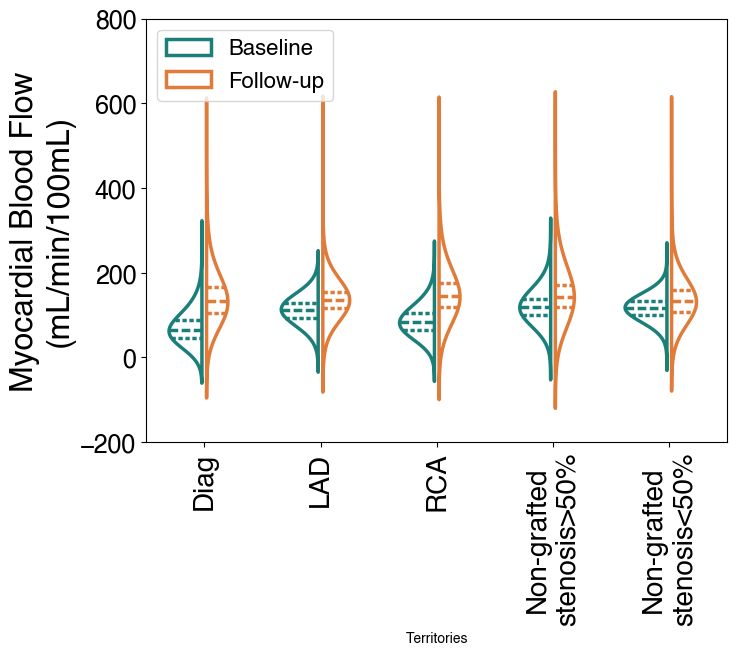

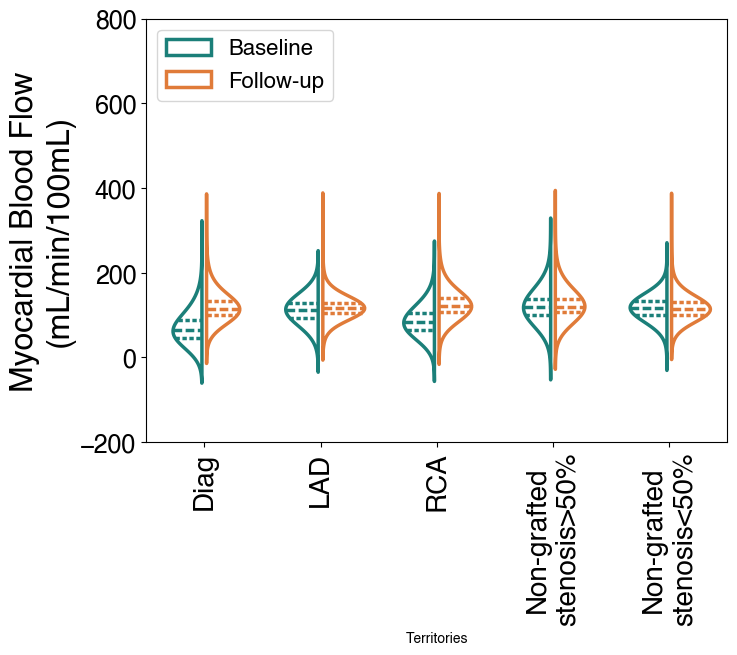

SU04


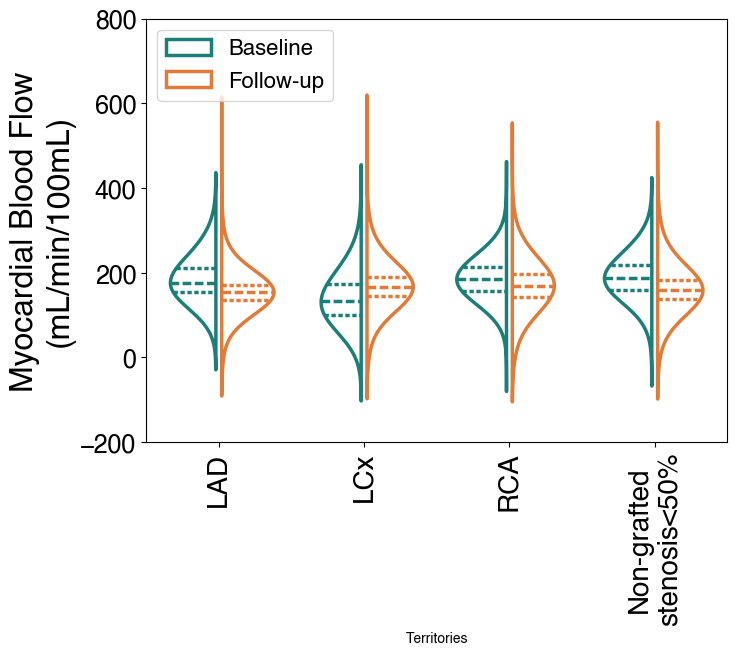

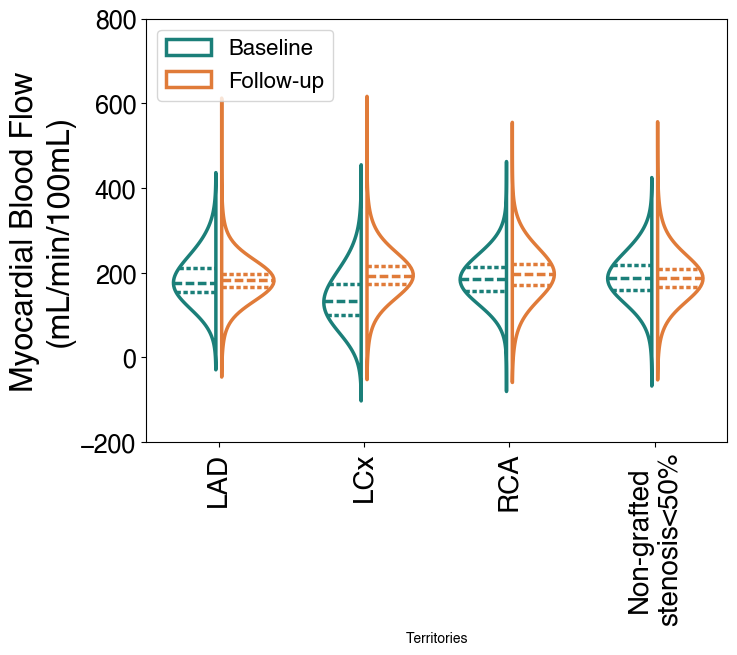

SU06


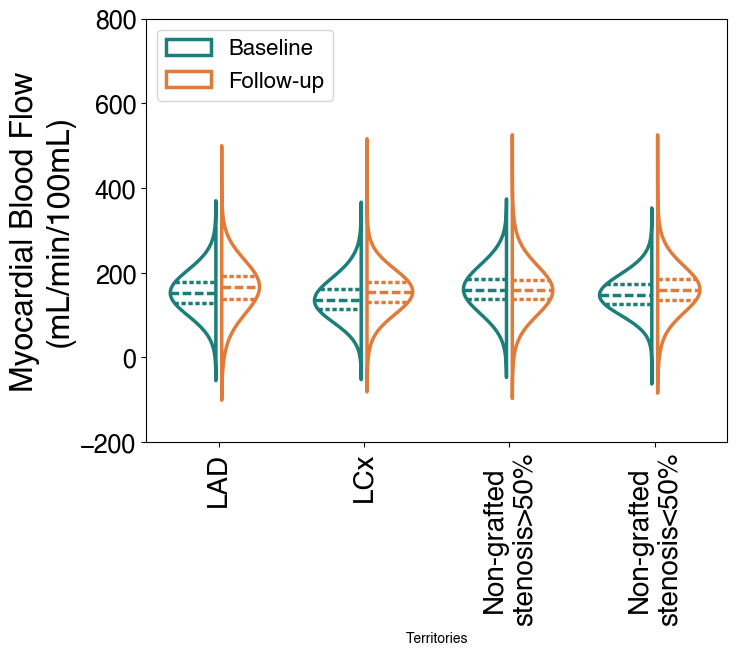

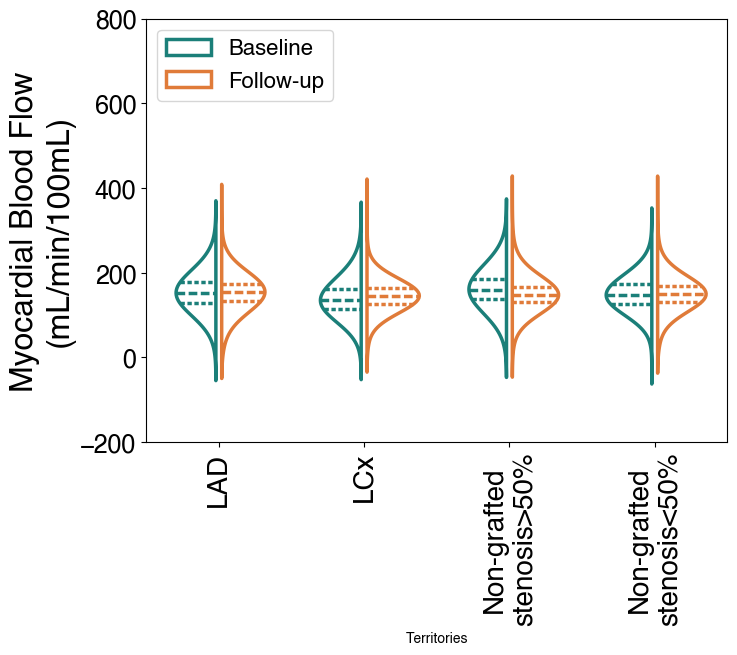

SU07


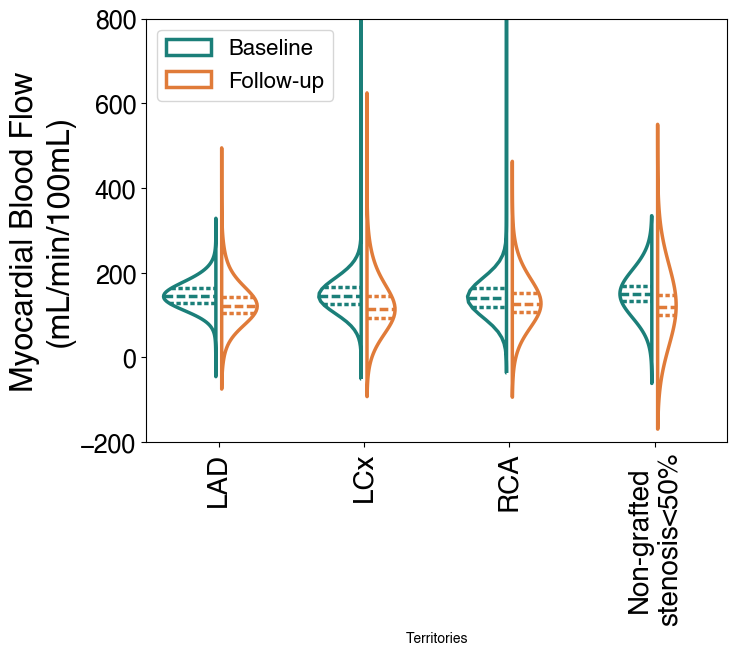

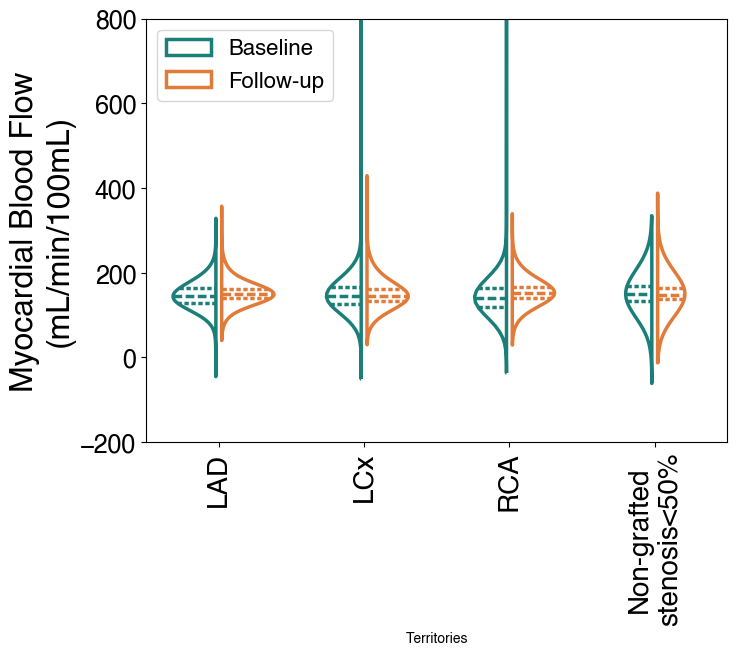

SU10


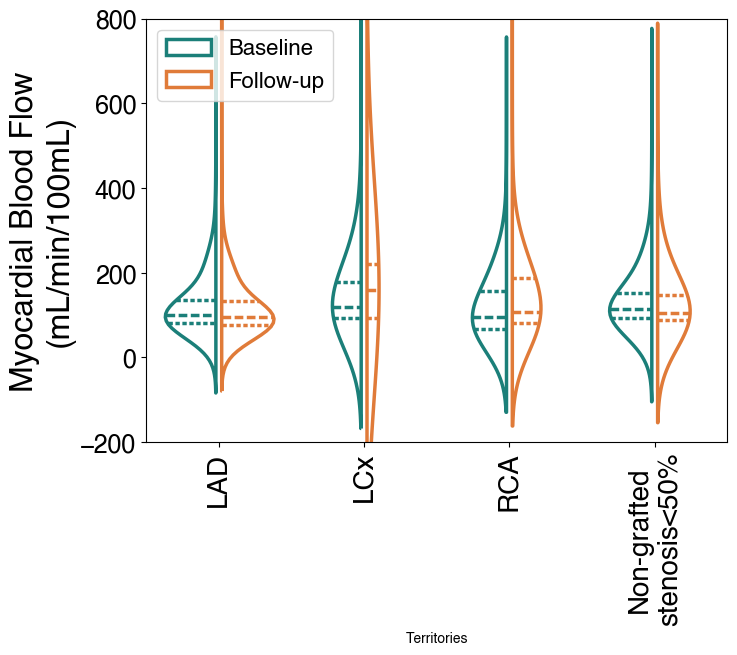

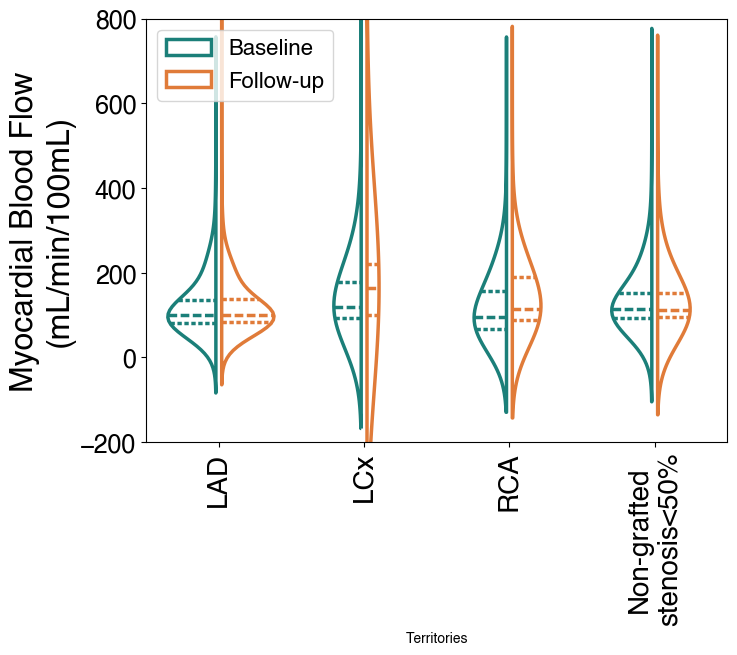

SU11


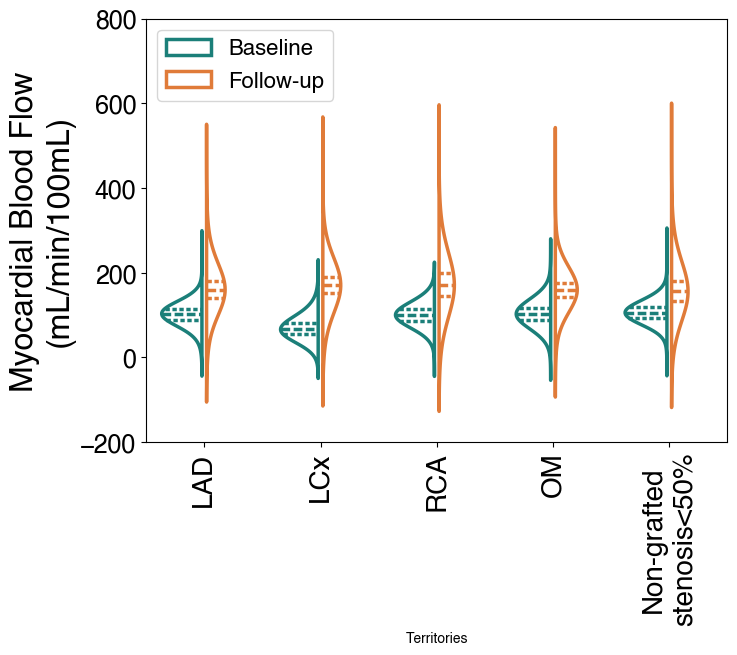

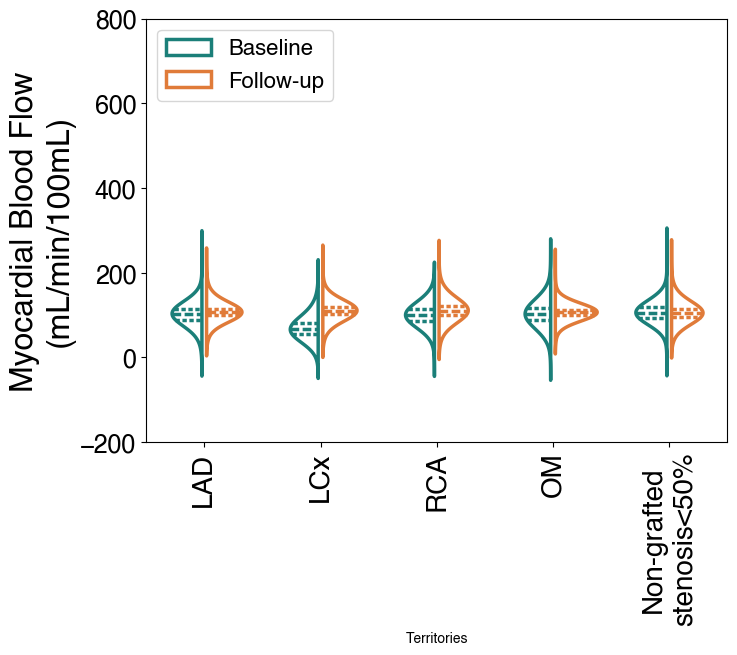

SU13


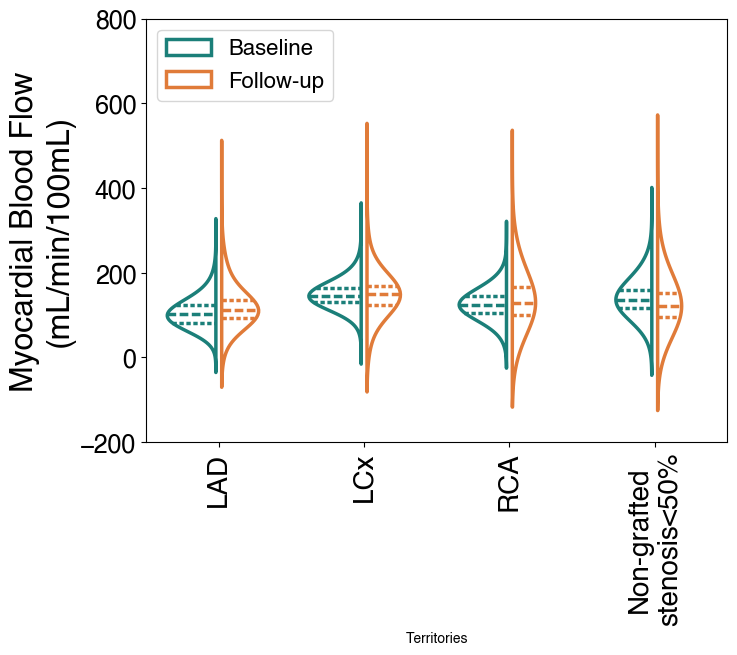

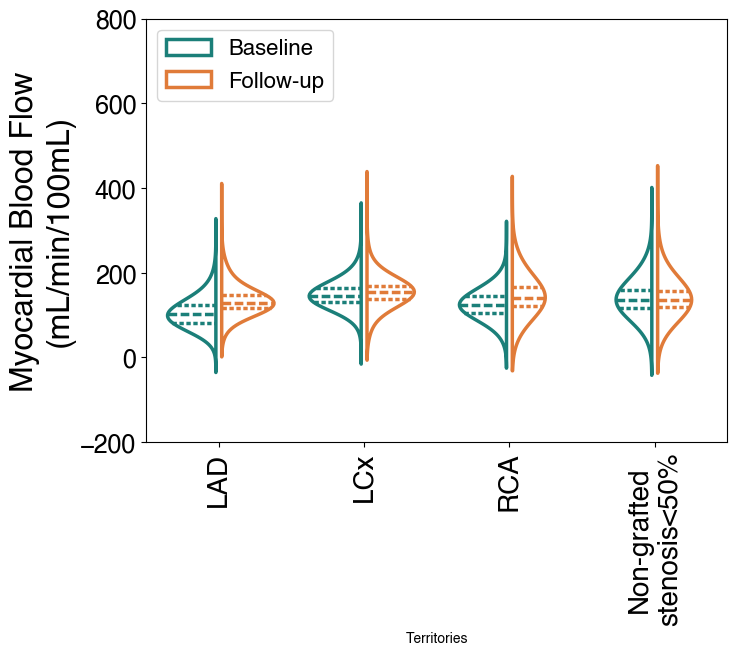

SU14


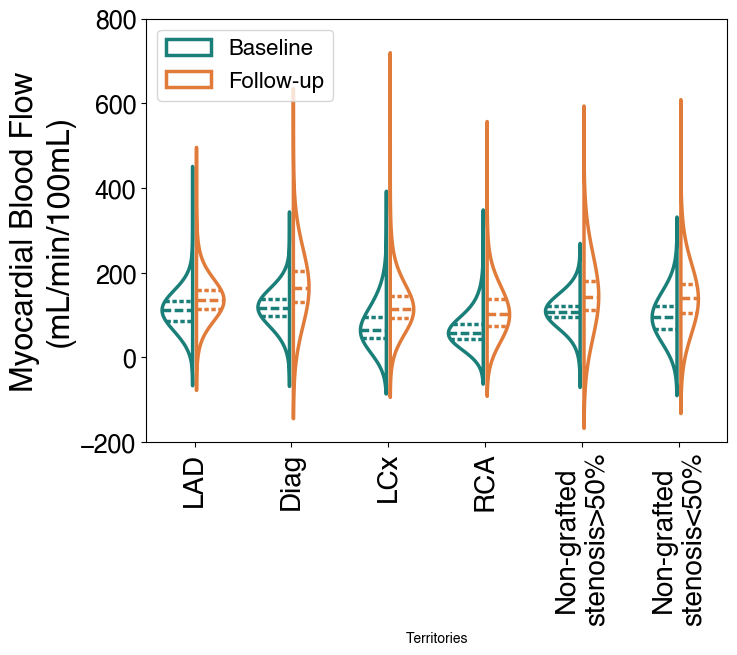

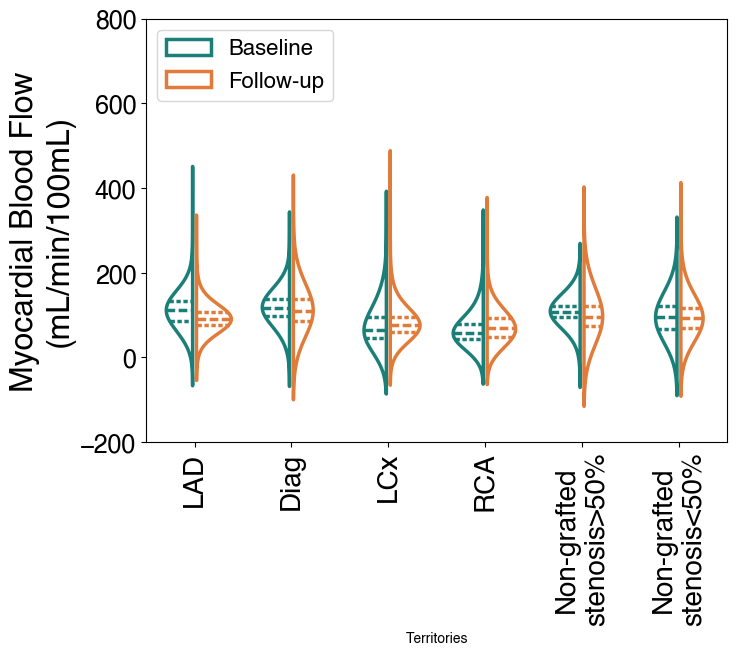

SU16


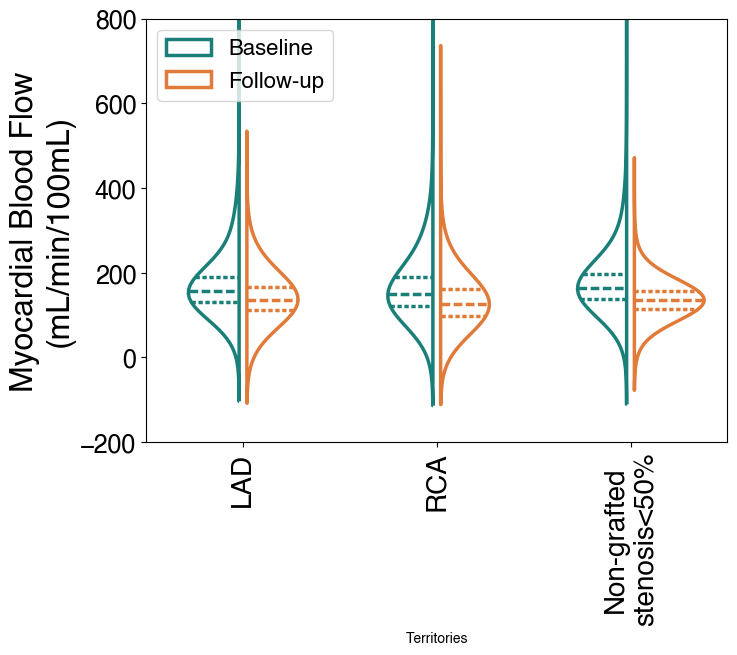

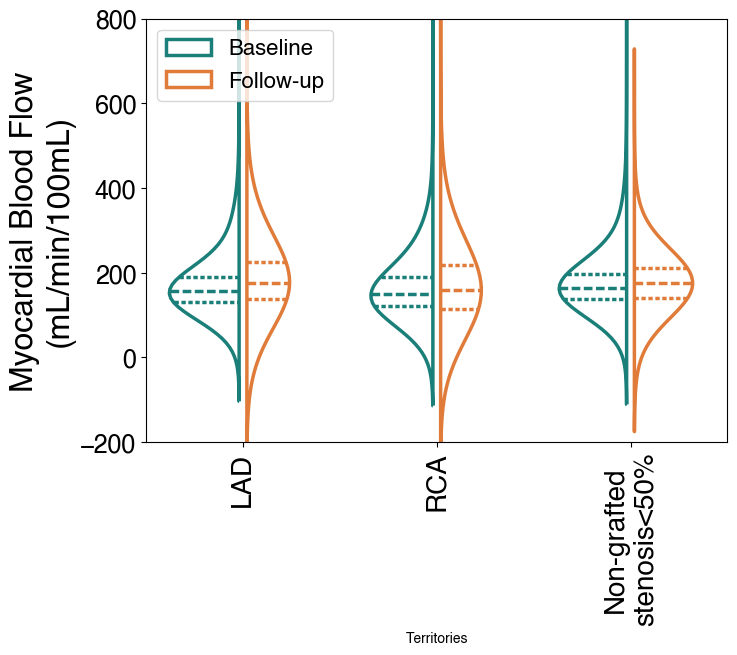

SU21


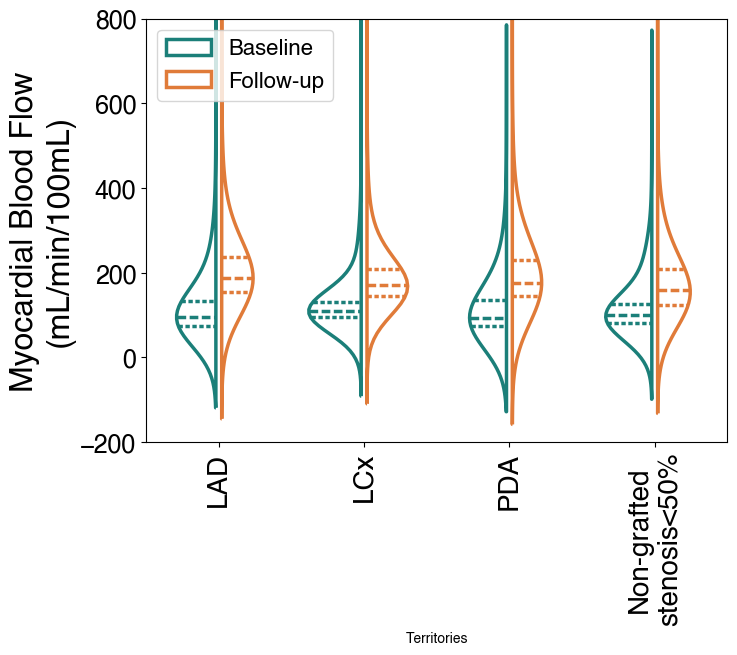

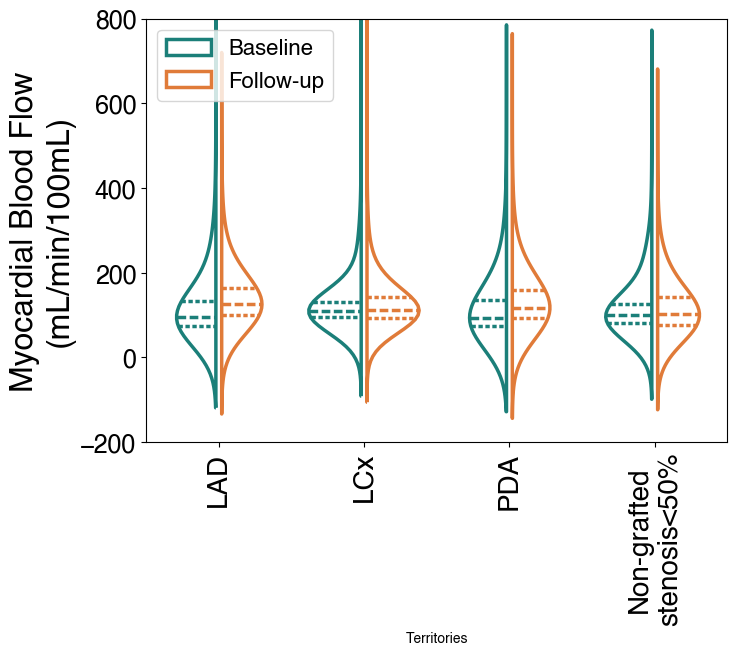

SU23


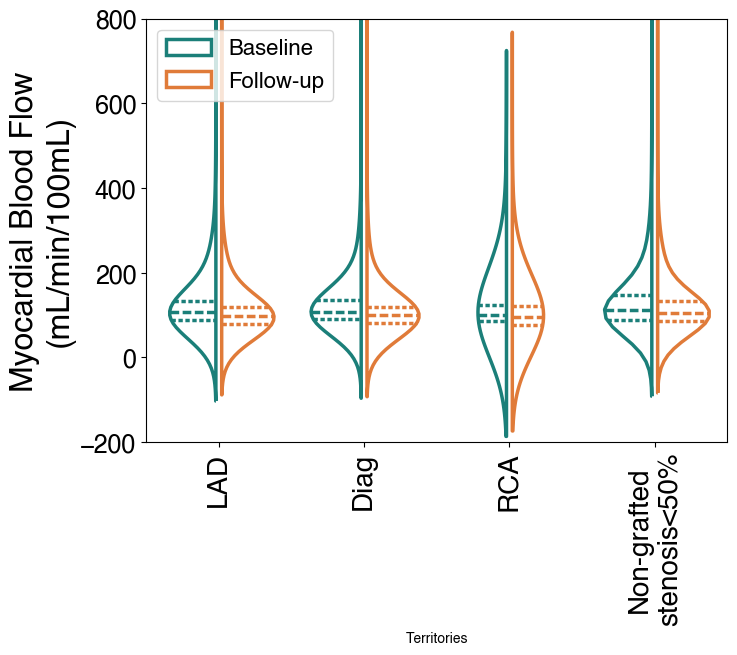

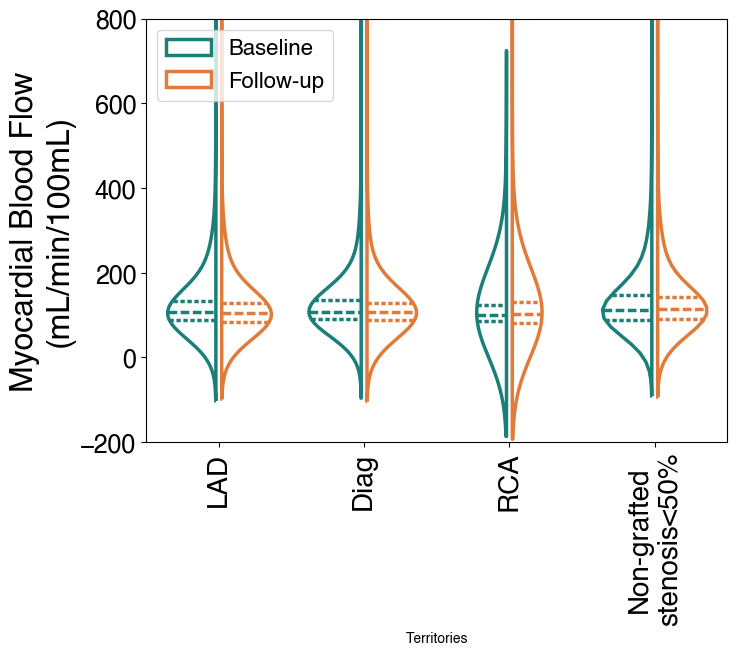

SU24


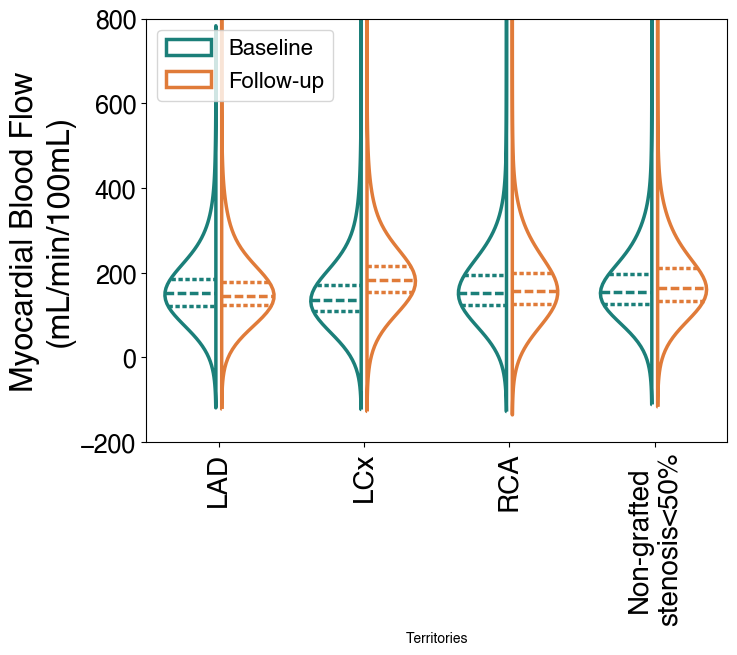

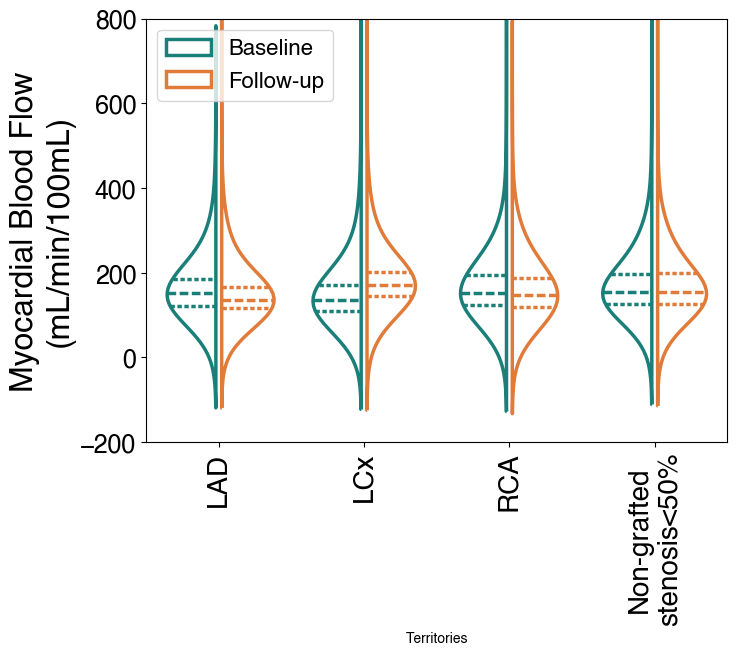

SU25


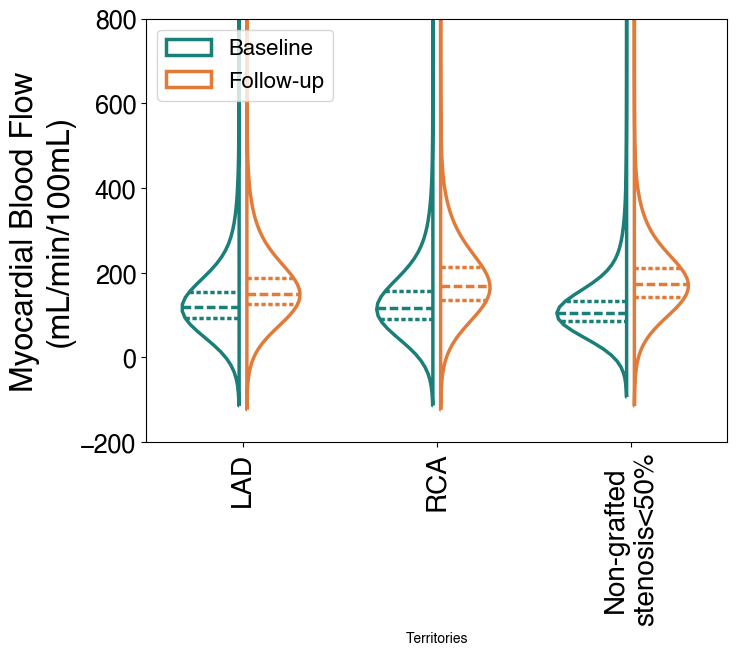

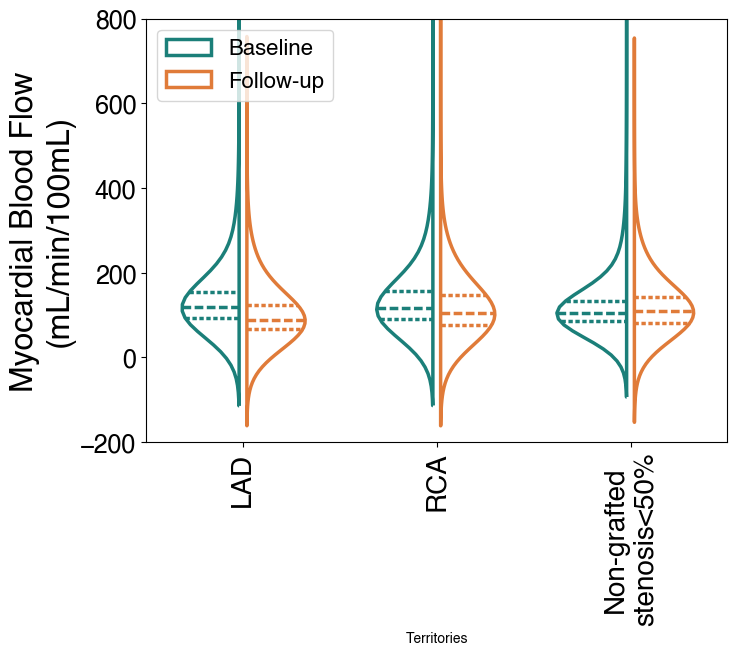

SU26


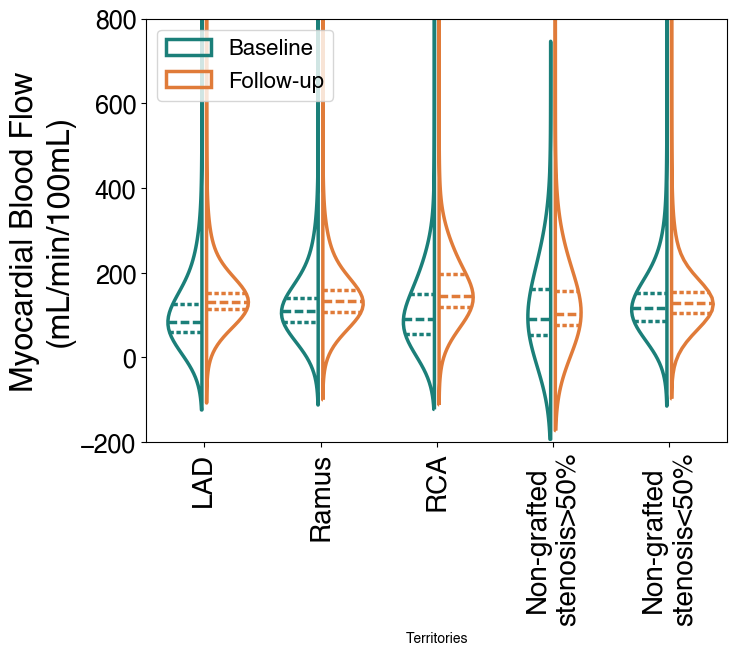

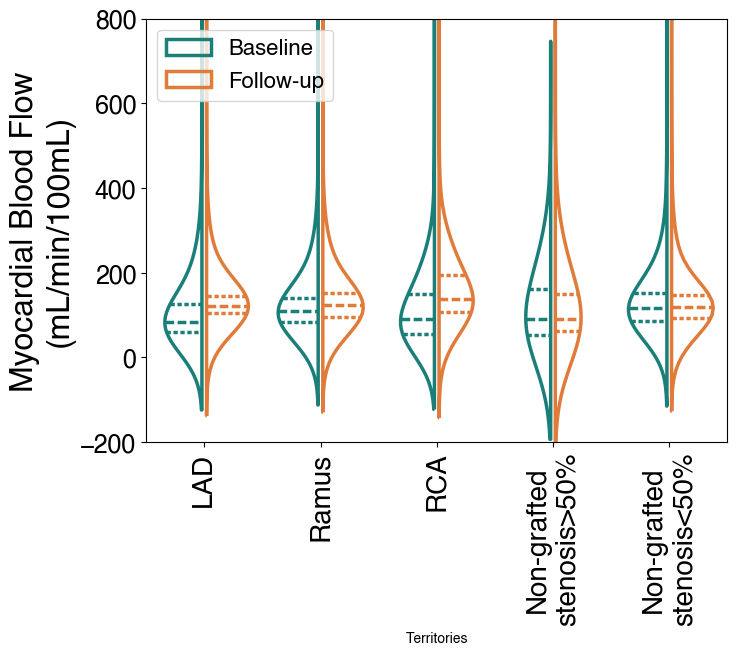

SU27


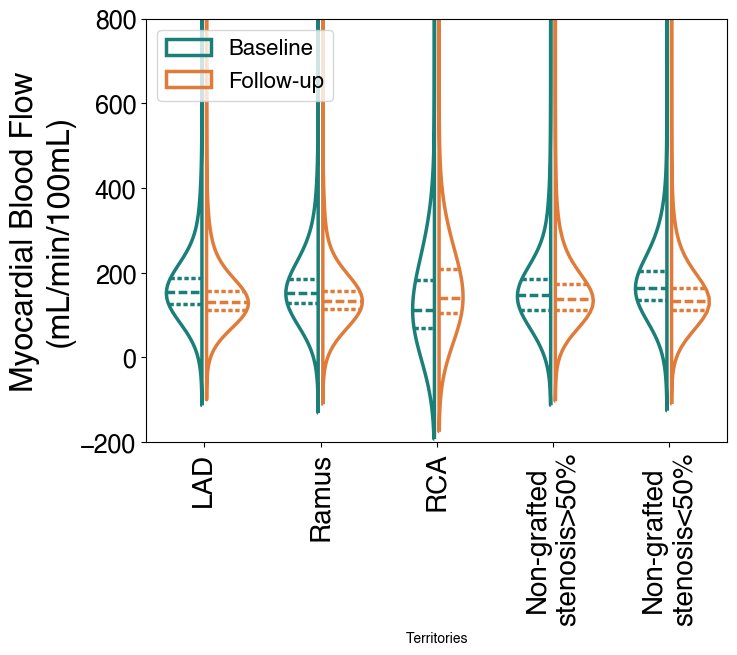

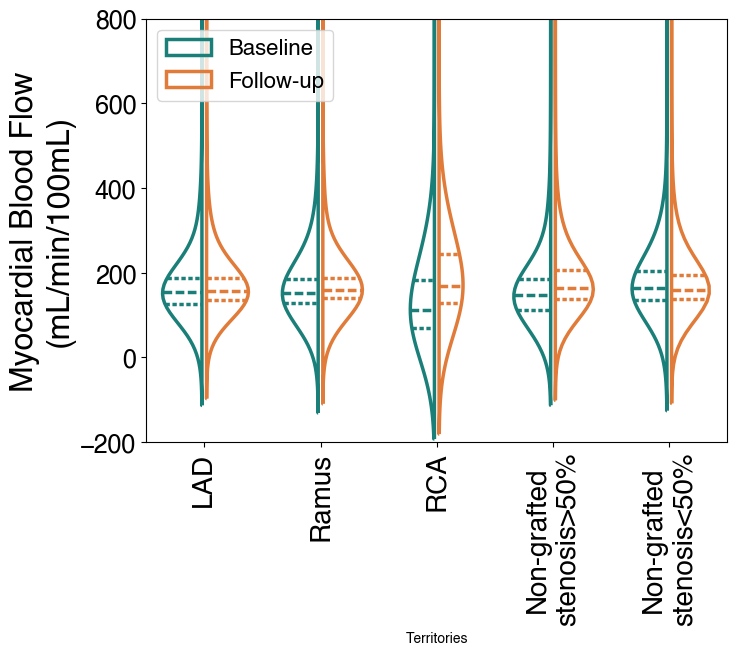

SU28


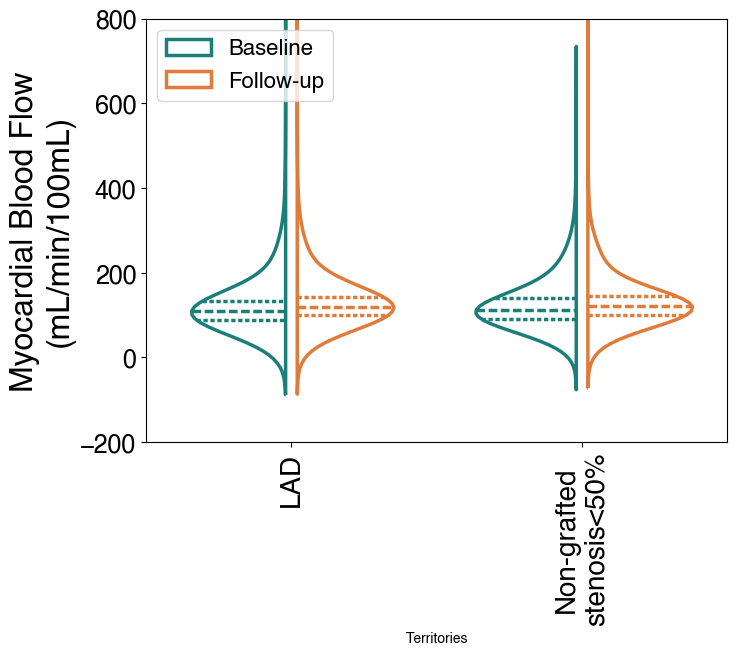

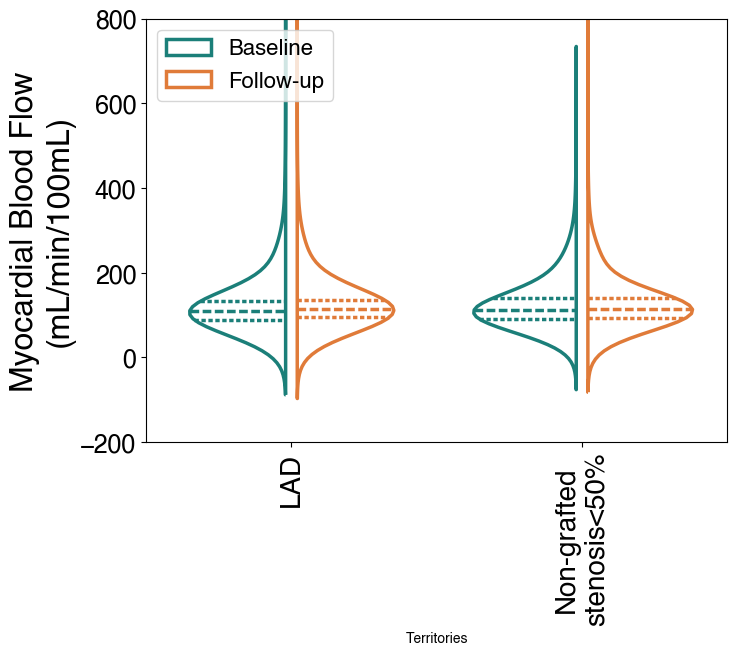

SU30


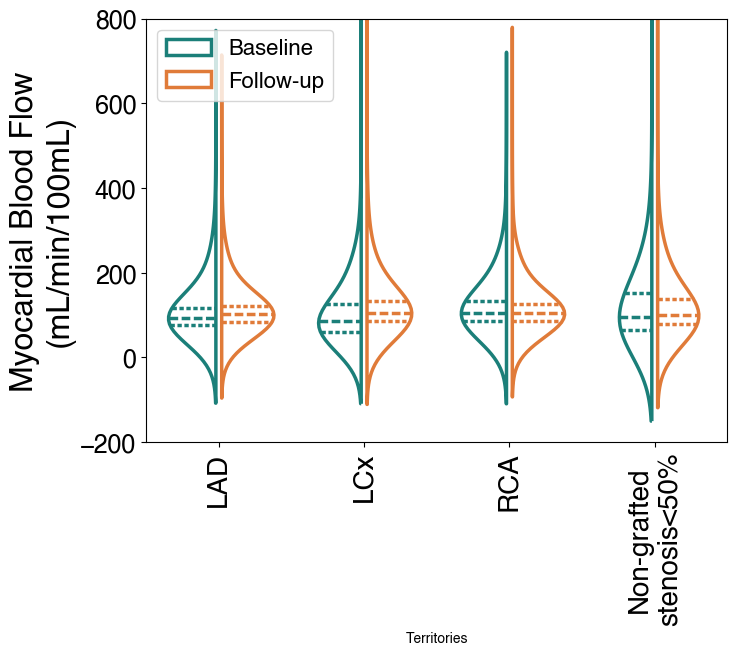

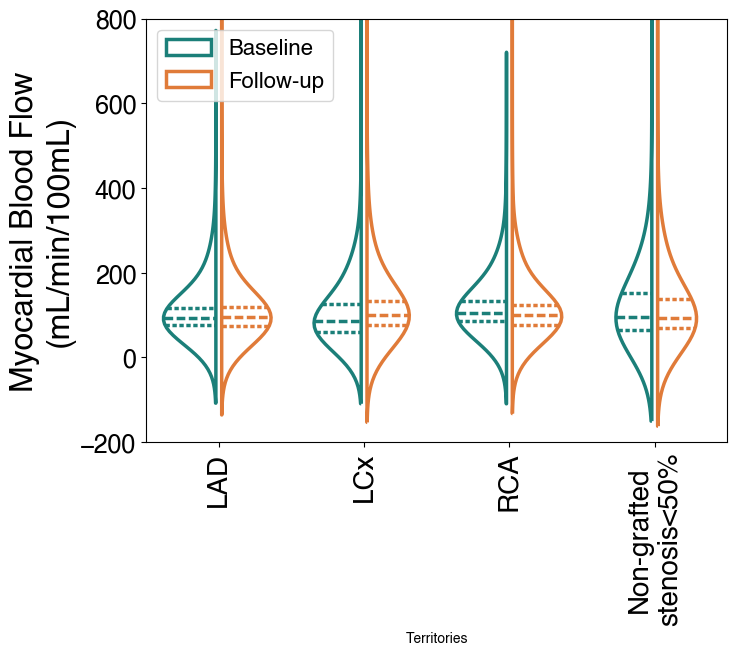

SU33


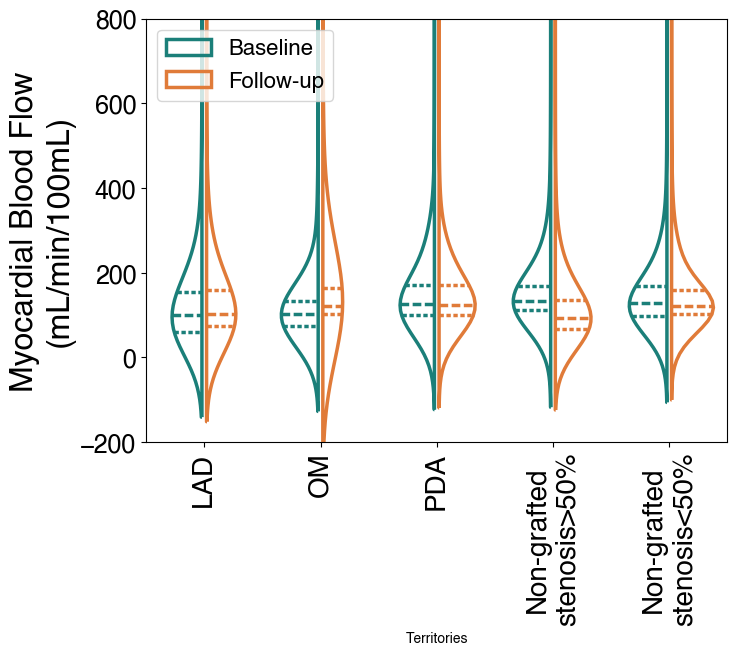

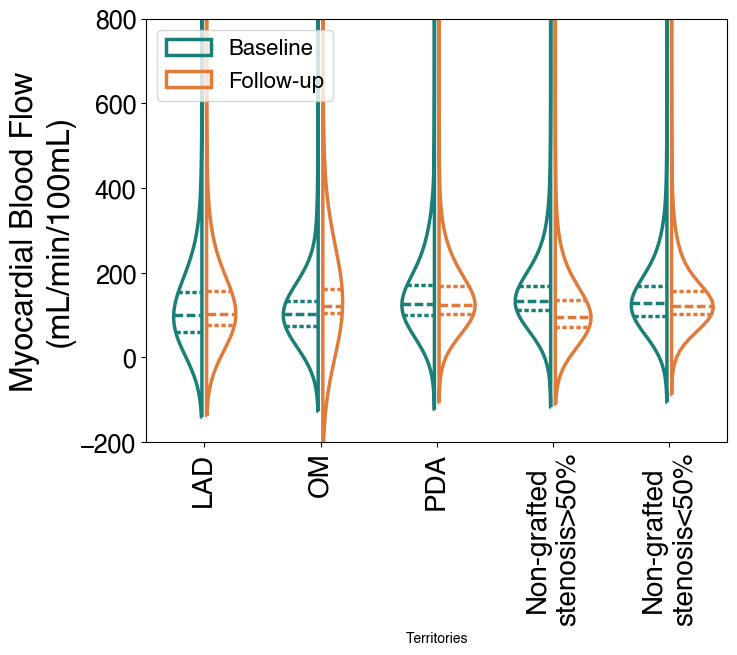

SU34


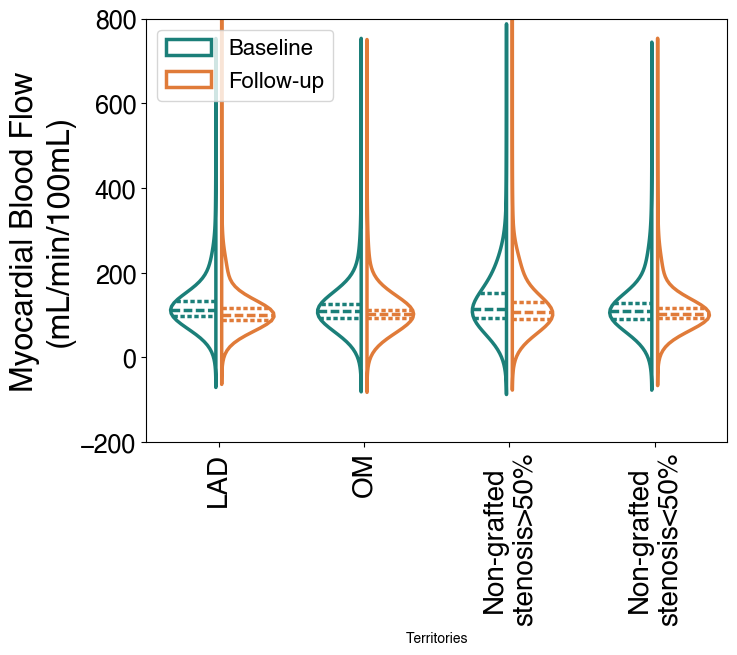

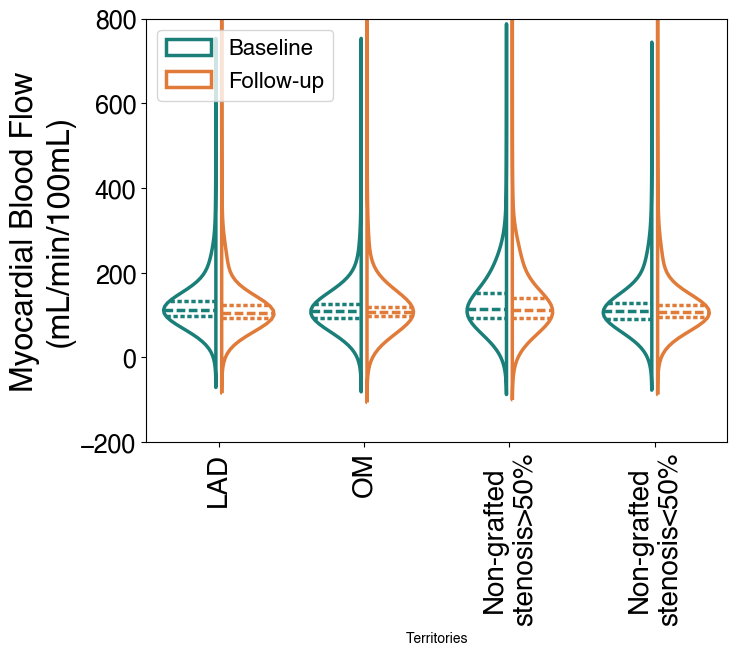

VA02


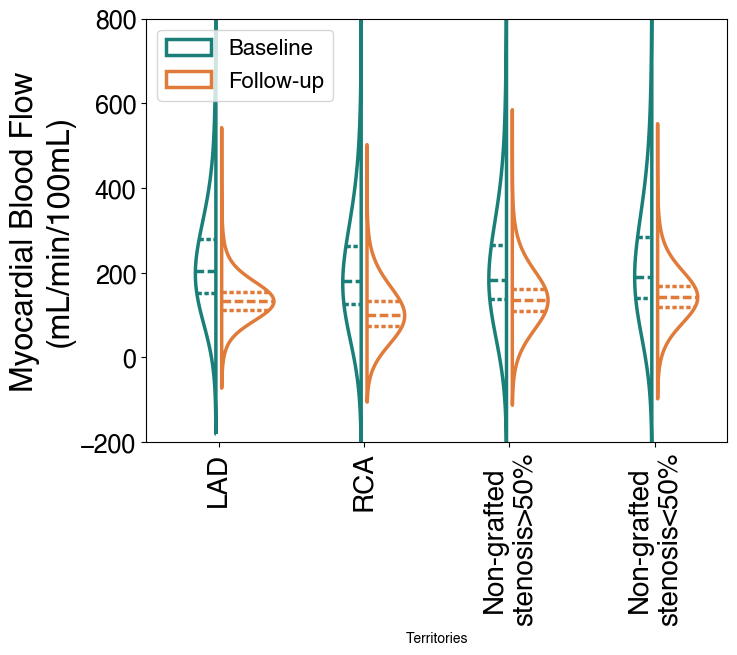

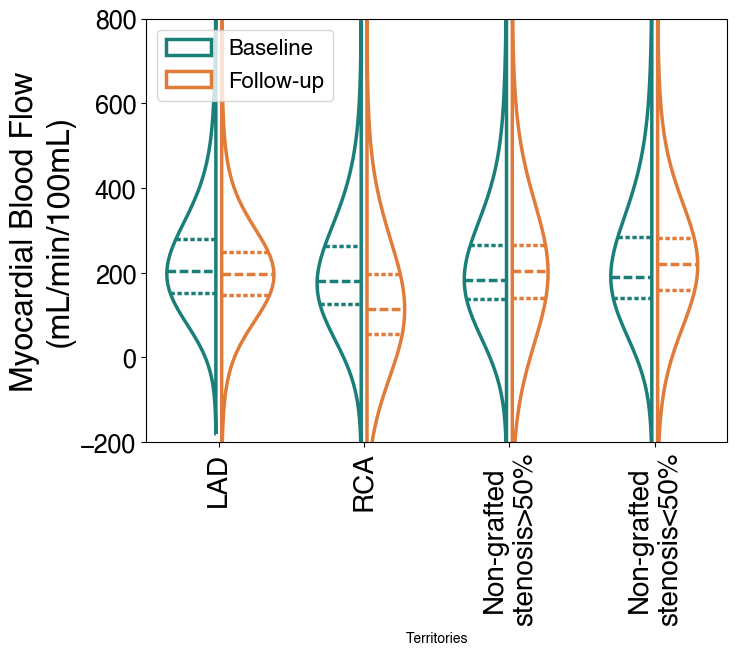

VA04


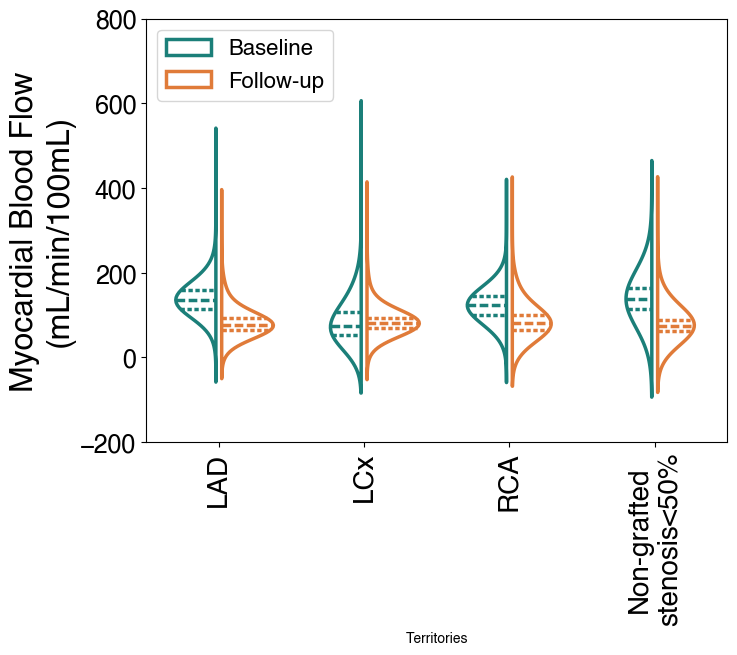

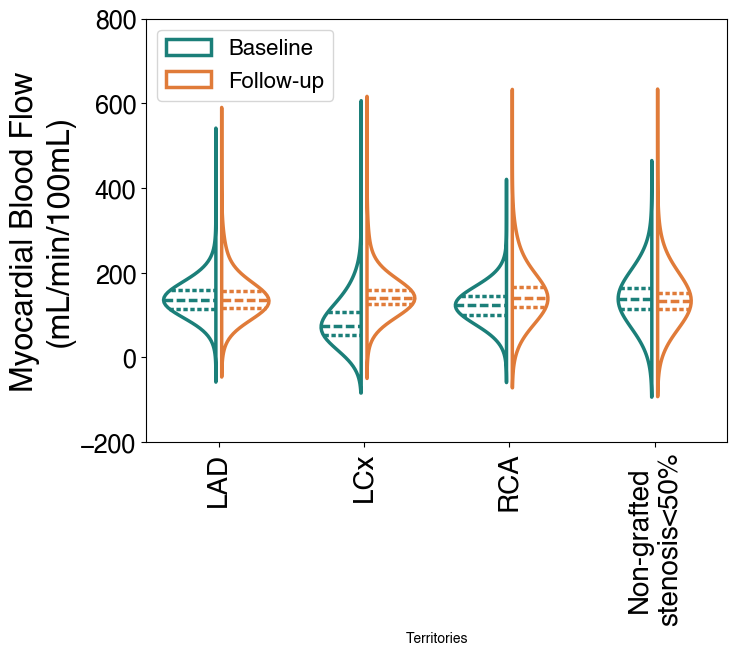

VA06


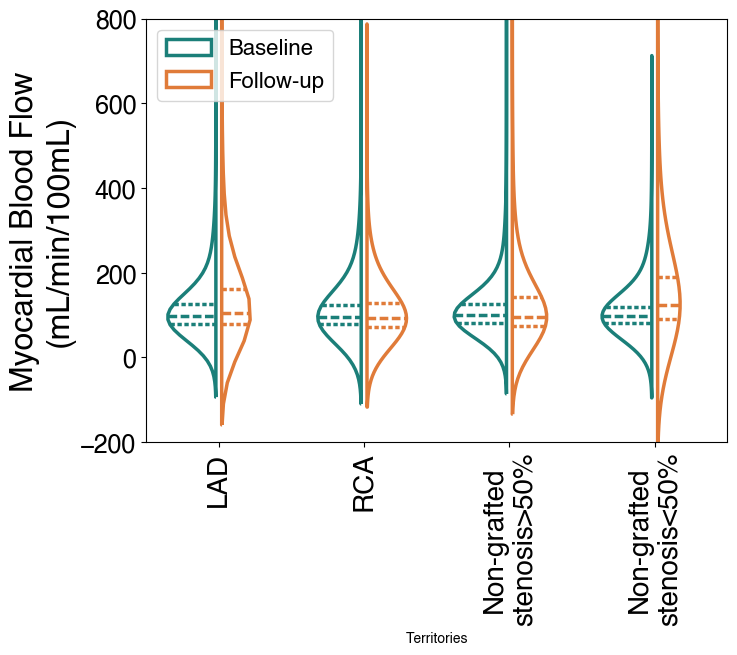

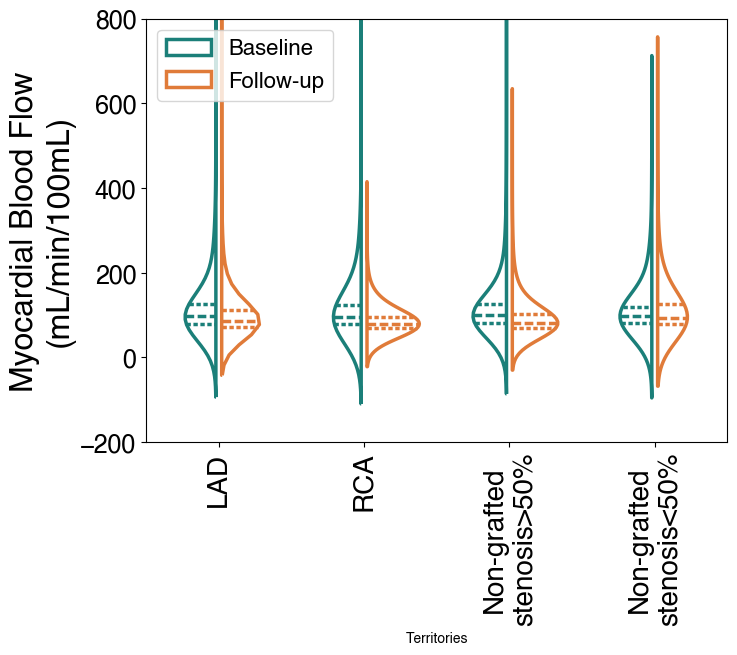

VA08


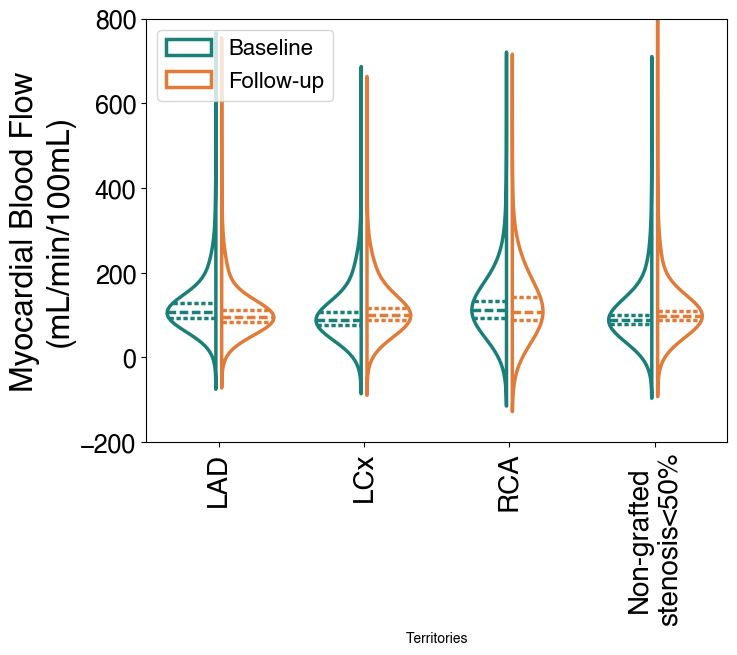

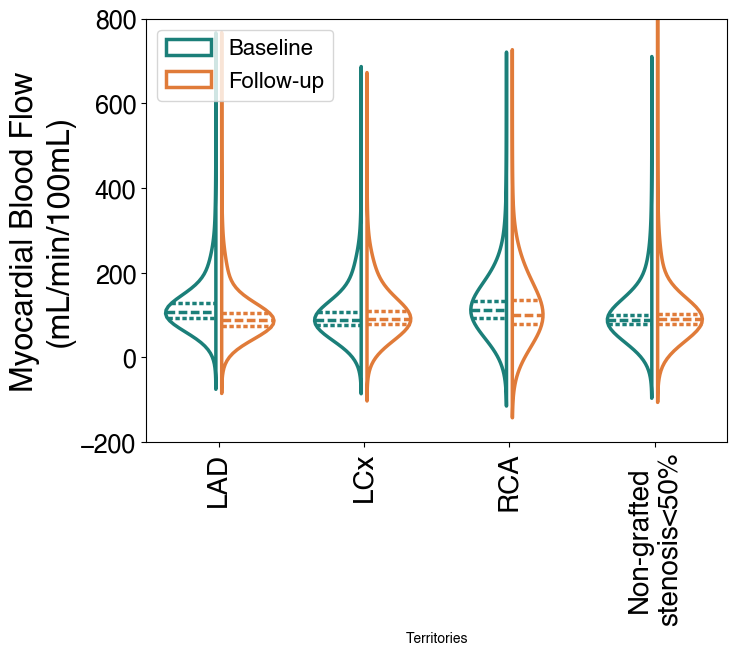

VA10


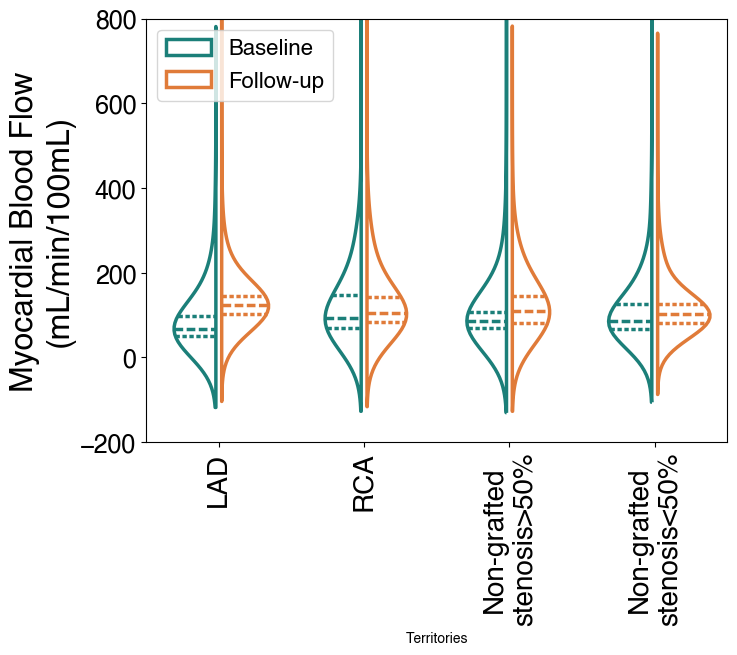

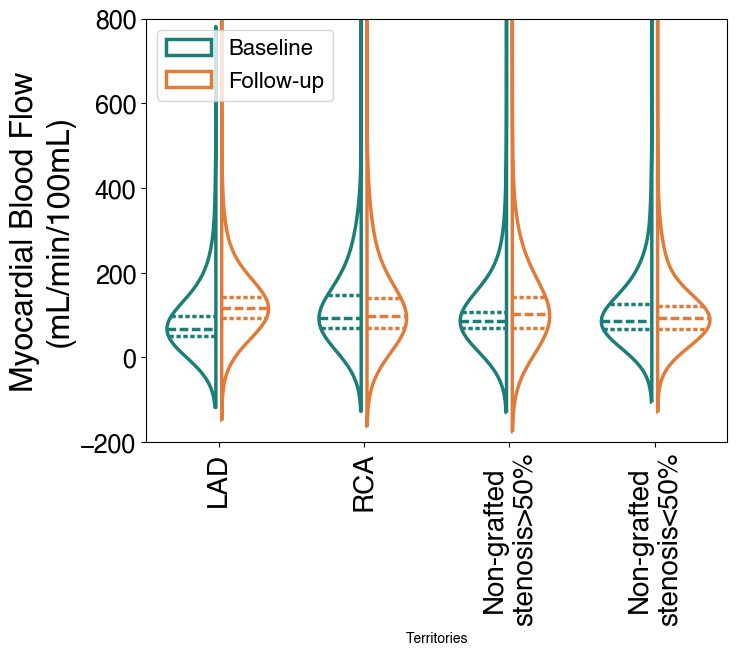

VA13


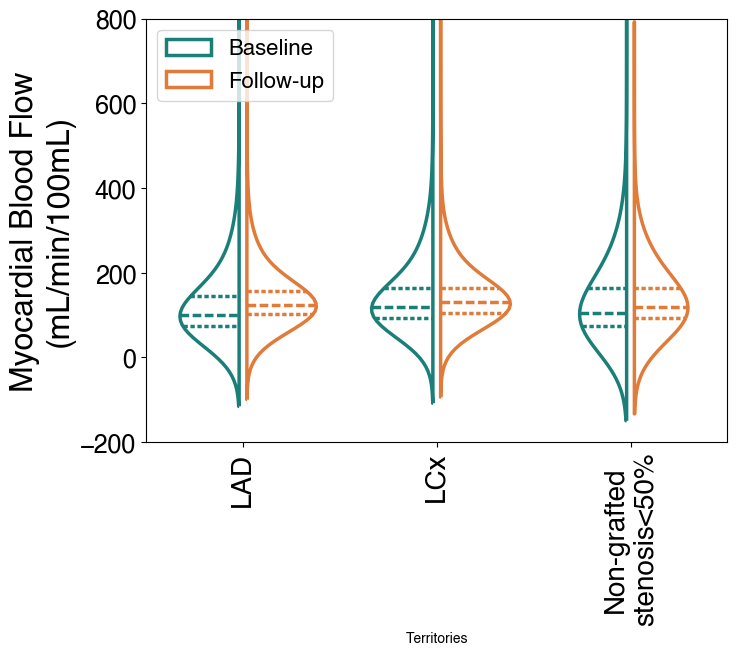

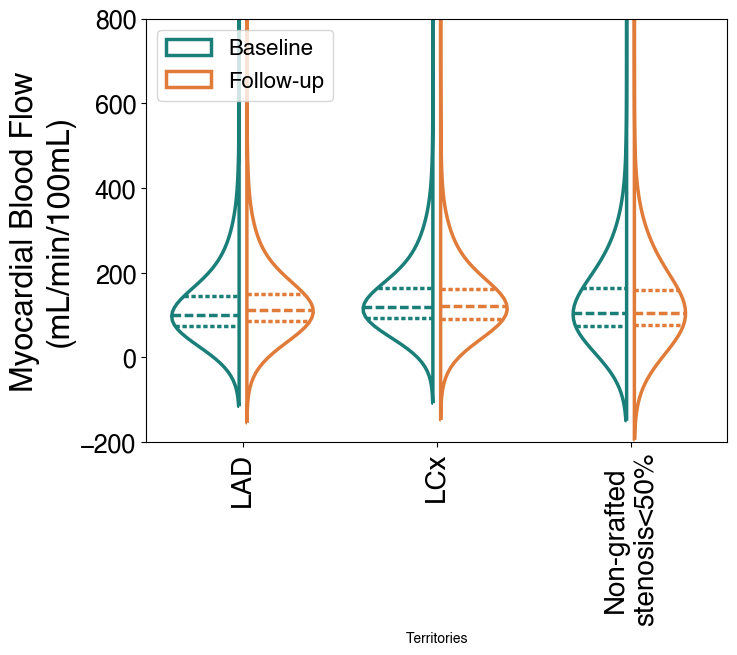

VA14


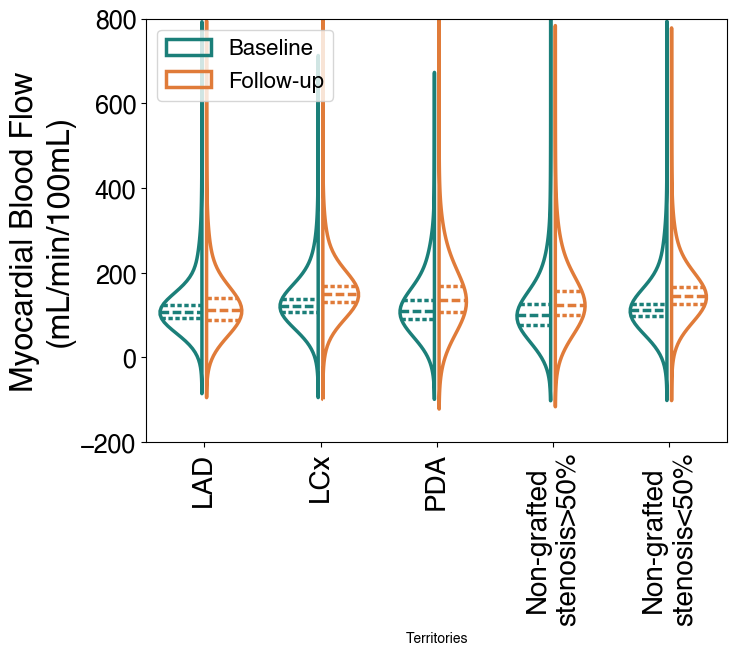

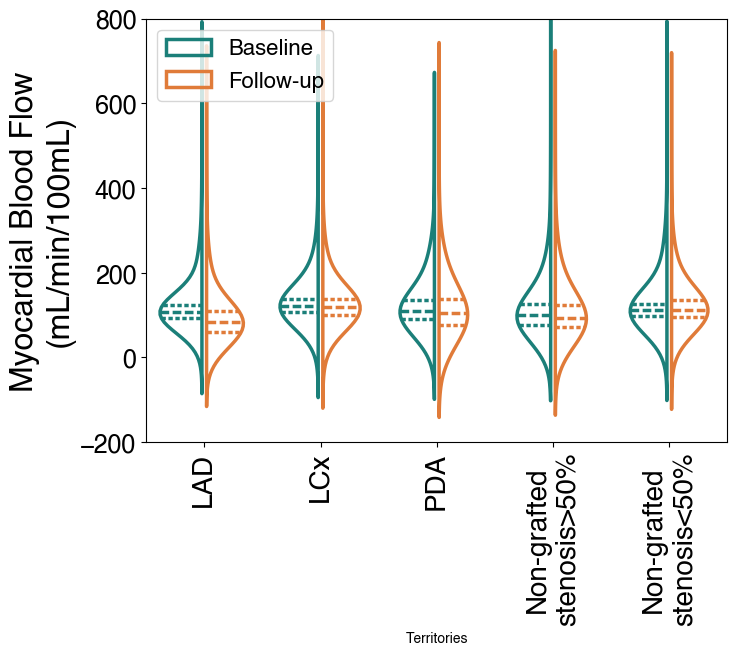

VA16


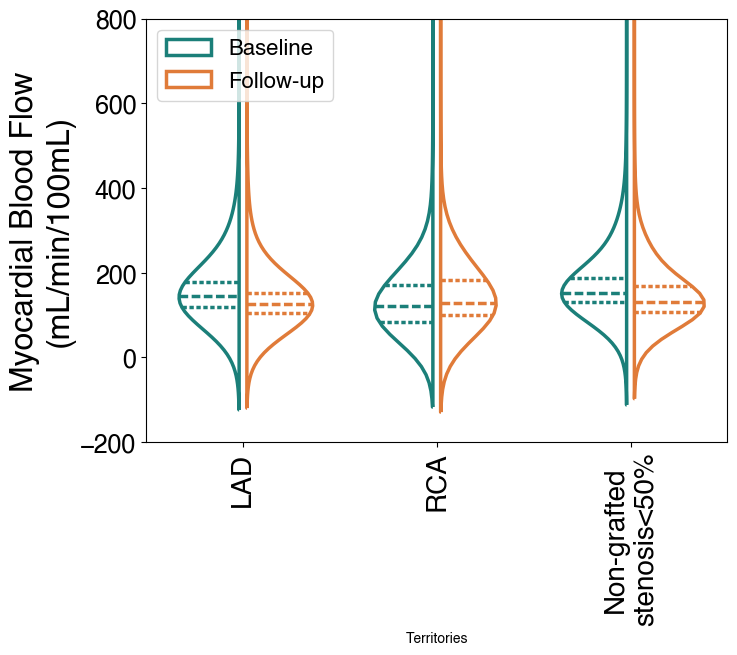

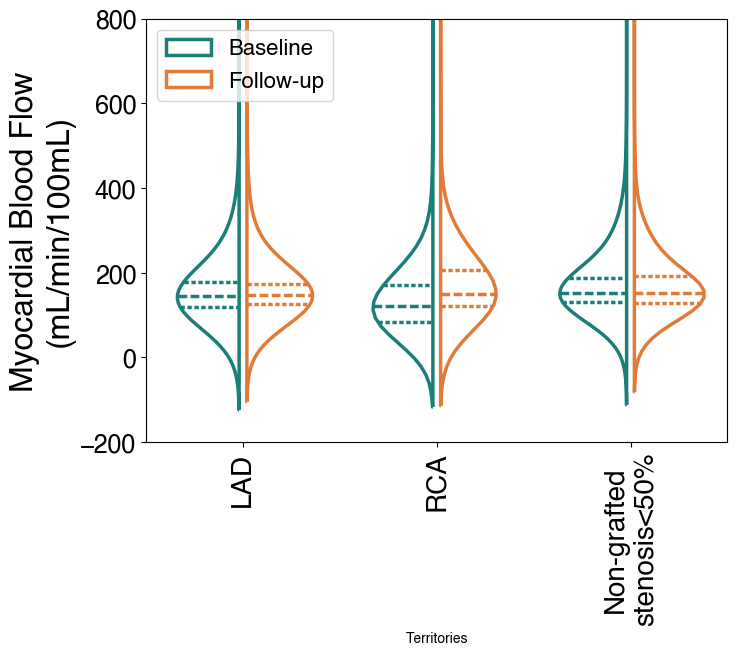

VA20


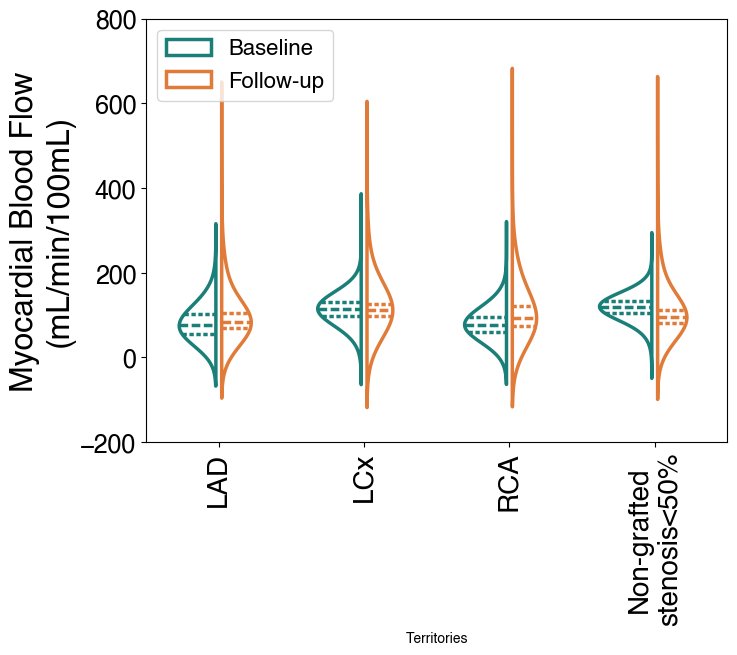

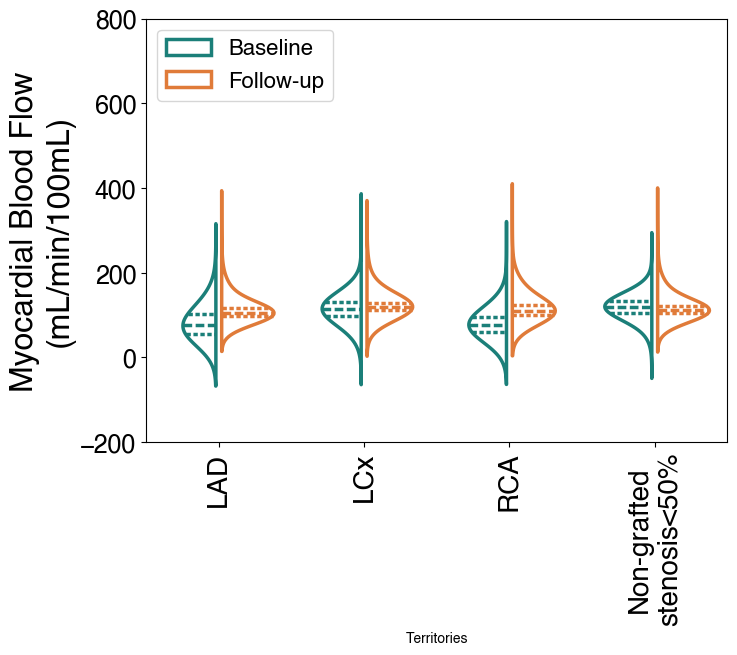

In [31]:
for patient_id in patient_ids:
    print(patient_id)
    tags = list(PatientMetadata[PatientMetadata['patient-id'] == patient_id]['stenosis tag'])
    ischemia = list(PatientMetadata[PatientMetadata['patient-id'] == patient_id]['is-ischemic'])
    TerritoryTags = [f'post_{tag}' for tag in tags]
    
    for file in TerritoryLabels:
        if patient_id in os.path.basename(os.path.splitext(file)[0]):
            LabelFile = file
    MBF_Labels = ReadLabels(LabelFile, TerritoryTags)

    for file in VTUFiles:
        if f"{patient_id}A" in os.path.basename(os.path.splitext(file)[0]):
            MBF_A = ReadVTUFile(file)
        elif f"{patient_id}B" in os.path.basename(os.path.splitext(file)[0]):
            MBF_B = ReadVTUFile(file)
    AbsMBFData_A = CollectMBFData(MBF_A, MBF_Labels)
    AbsMBFData_B = CollectMBFData(MBF_B, MBF_Labels)
    data = pd.DataFrame({"MBF": [], "Territories": [], "Type": []})
    dataMapped = pd.DataFrame({"MBF": [], "Territories": [], "Type": []})
    t = "Non-grafted\nstenosis<50%"
    array_A = AbsMBFData_A[t]
    mean_A = np.mean(array_A)
    std_A = np.std(array_A)
    array_B = AbsMBFData_B[t]
    mean_B = np.mean(array_B)
    std_B = np.std(array_B)
    
    #data_ = pd.DataFrame({"MBF": np.concatenate([array_A, array_B]), "Territories": [t]*len(array_A) + [t]*len(array_B), "Type": ['A']*len(array_A) + ['B']*len(array_B)})
    #data = pd.concat([data, data_], ignore_index=True)
    # Mapping
    #data_mapped_ = pd.DataFrame({"MBF": np.concatenate([MapNongrafted(mean_A, mean_B, std_A, std_B, array_A), array_B]), "Territories": [t]*len(array_A) + [t]*len(array_B), "Type": ['A']*len(array_A) + ['B']*len(array_B)})
    #dataMapped = pd.concat([dataMapped, data_mapped_], ignore_index=True)
    for i, t in enumerate(tags):
        array_A = AbsMBFData_A[t]
        array_B = AbsMBFData_B[t]
        data_ = pd.DataFrame({"MBF": np.concatenate([array_A, array_B]), "Territories": [t]*len(array_A) + [t]*len(array_B), "Type": ['Baseline']*len(array_A) + ['Follow-up']*len(array_B)})
        data = pd.concat([data, data_], ignore_index=True)
        # Mapping
        data_mapped_ = pd.DataFrame({"MBF": np.concatenate([array_A, MapNongrafted(mean_B, mean_A, std_B, std_A, array_B)]), "Territories": [t]*len(array_A) + [t]*len(array_B), "Type": ['Baseline']*len(array_A) + ['Follow-up']*len(array_B)})
        dataMapped = pd.concat([dataMapped, data_mapped_], ignore_index=True)
    t = "Non-grafted\nstenosis>50%"
    if t in MBF_Labels.keys():
        array_A = AbsMBFData_A[t]
        array_B = AbsMBFData_B[t]
        data_ = pd.DataFrame({"MBF": np.concatenate([array_A, array_B]), "Territories": [t]*len(array_A) + [t]*len(array_B), "Type": ['Baseline']*len(array_A) + ['Follow-up']*len(array_B)})
        data = pd.concat([data, data_], ignore_index=True)
        # Mapping
        data_mapped_ = pd.DataFrame({"MBF": np.concatenate([array_A, MapNongrafted(mean_B, mean_A, std_B, std_A, array_B)]), "Territories": [t]*len(array_A) + [t]*len(array_B), "Type": ['Baseline']*len(array_A) + ['Follow-up']*len(array_B)})
        dataMapped = pd.concat([dataMapped, data_mapped_], ignore_index=True)
    t = "Non-grafted\nstenosis<50%"
    array_A = AbsMBFData_A[t]
    array_B = AbsMBFData_B[t]
    data_ = pd.DataFrame({"MBF": np.concatenate([array_A, array_B]), "Territories": [t]*len(array_A) + [t]*len(array_B), "Type": ['Baseline']*len(array_A) + ['Follow-up']*len(array_B)})
    data = pd.concat([data, data_], ignore_index=True)
    # Mapping
    data_mapped_ = pd.DataFrame({"MBF": np.concatenate([array_A, MapNongrafted(mean_B, mean_A, std_B, std_A, array_B)]), "Territories": [t]*len(array_A) + [t]*len(array_B), "Type": ['Baseline']*len(array_A) + ['Follow-up']*len(array_B)})
    dataMapped = pd.concat([dataMapped, data_mapped_], ignore_index=True)
    
    
    #BoxPlot(data)
    ViolinPlot(data)
    #print("--- Mapping Results:")
    ViolinPlot(dataMapped)


In [32]:
Removed_Cases = ["SU25", "VA04"]

### Mapping pre on post

In [278]:
dataMapped = []

for patient_id in patient_ids:
    if patient_id in Removed_Cases: 
        continue
    tags = list(PatientMetadata[PatientMetadata['patient-id'] == patient_id]['stenosis tag'])
    ischemia = list(PatientMetadata[PatientMetadata['patient-id'] == patient_id]['is-ischemic'])
    TerritoryTags = [f'post_{tag}' for tag in tags]
    cutoff = list(PatientMetadata[PatientMetadata['patient-id'] == patient_id]['cutoff'])[0]
    grafts = list(PatientMetadata[PatientMetadata['patient-id'] == patient_id]['graft'])
    graft_stenosis = list(PatientMetadata[PatientMetadata['patient-id'] == patient_id]['graft-stenosis'])
    if cutoff == 0:
        cutoff = 142
    for file in TerritoryLabels:
        if patient_id in os.path.basename(os.path.splitext(file)[0]):
            LabelFile = file
    MBF_Labels = ReadLabels(LabelFile, TerritoryTags)
    normalization_method = "classic"
    for file in VTUFiles:
        if f"{patient_id}A" in os.path.basename(os.path.splitext(file)[0]):
            MBF_A = Normalize(ReadVTUFile(file), normalization_method, cutoff/2)
        elif f"{patient_id}B" in os.path.basename(os.path.splitext(file)[0]):
            MBF_B = Normalize(ReadVTUFile(file), normalization_method, cutoff/2)
    AbsMBFData_A = CollectMBFData(MBF_A, MBF_Labels)
    AbsMBFData_B = CollectMBFData(MBF_B, MBF_Labels)

    t = "Non-grafted\nstenosis<50%"
    array_A = AbsMBFData_A[t]
    ref_A = np.median(array_A)
    # mean_A = np.mean(array_A)
    # std_A = np.std(array_A)
    array_B = AbsMBFData_B[t]
    ref_B = np.median(array_B)
    # mean_B = np.mean(array_B)
    # std_B = np.std(array_B)

    MBF_A_array = GetMBFArray(MBF_A)
    MBF_B_Array = GetMBFArray(MBF_B)

    # ref_A = np.percentile(MBF_A_array, 50)
    # ref_B = np.percentile(MBF_B_Array, 50)

    ref = np.percentile(MBF_A_array, 75)

    threshold1 = 0.9 * ref  # 10% drop
    threshold2 = 0.8 * ref  # 20% drop
    threshold3 = 0.7 * ref  # 30% drop

    for i, t in enumerate(tags):
        mbf_median = np.median(AbsMBFData_A[t])
        if mbf_median > threshold1:
            is_ischemic = False
            ischemia_grade = 0
        elif threshold2 < mbf_median <= threshold1:
            is_ischemic = False
            ischemia_grade = 1
        elif threshold3 < mbf_median <= threshold2:
            is_ischemic = True
            ischemia_grade = 2
        else:
            is_ischemic = True
            ischemia_grade = 3


        array_B = AbsMBFData_B[t]#MapNongrafted(mean_B, mean_A, std_B, std_A, AbsMBFData_B[t])#ShiftMBF(ref_B, ref_A, AbsMBFData_B[t])# # 
        array_A = AbsMBFData_A[t]#ShiftMBF(ref_A, ref_B, AbsMBFData_A[t])#
        data_ = {"patient_id": patient_id, "tag": t, "graft_type": grafts[i], "is_ischemic": is_ischemic, "ischemic_grade":ischemia_grade, "graft_stenosis": graft_stenosis[i], "absMBF_A": array_A, "absMBF_B": array_B}
        dataMapped.append(data_)
    t = "Non-grafted\nstenosis>50%"
    if t in MBF_Labels.keys():
        array_B = AbsMBFData_B[t]#MapNongrafted(mean_B, mean_A, std_B, std_A, AbsMBFData_B[t])#ShiftMBF(ref_B, ref_A, AbsMBFData_B[t])# # 
        array_A = AbsMBFData_A[t] #ShiftMBF(ref_A, ref_B, AbsMBFData_A[t])#
        data_ = {"patient_id": patient_id, "tag": t, "graft_type": None, "is_ischemic": False, "ischemic_grade":0, "graft_stenosis": 0, "absMBF_A": array_A, "absMBF_B": array_B}
        dataMapped.append(data_)
    t = "Non-grafted\nstenosis<50%"
    array_B = AbsMBFData_B[t]#MapNongrafted(mean_B, mean_A, std_B, std_A, AbsMBFData_B[t])#ShiftMBF(ref_B, ref_A, AbsMBFData_B[t])#AbsMBFData_B[t]# # 
    array_A = AbsMBFData_A[t] #ShiftMBF(ref_A, ref_B, AbsMBFData_A[t])#AbsMBFData_A[t]#ShiftMBF(ref_A, ref_B, AbsMBFData_A[t])
    data_ = {"patient_id": patient_id, "tag": t, "graft_type": None, "is_ischemic": False, "ischemic_grade":0, "graft_stenosis": 0, "absMBF_A": array_A, "absMBF_B": array_B}
    dataMapped.append(data_)


In [279]:
df = pd.DataFrame(dataMapped)

In [280]:
print("TerritoryTag", "Median", "IQR", "Mean", "std")
mbf_ischemic_A = np.concatenate(df[(df['tag'] != 'Non-grafted\nstenosis<50%') & (df['tag'] != "Non-grafted\nstenosis>50%")]['absMBF_A'].values)
q1, q2, q3 = np.percentile(mbf_ischemic_A, [25, 50, 75])
average_g = np.mean(mbf_ischemic_A)
std = np.std(mbf_ischemic_A)
print("all_grafted_A", q2, q3-q1, average_g, std)

mbf_ischemic_B = np.concatenate(df[(df['tag'] != 'Non-grafted\nstenosis<50%') & (df['tag'] != "Non-grafted\nstenosis>50%")]['absMBF_B'].values)
q1, q2, q3 = np.percentile(mbf_ischemic_B, [25, 50, 75])
average = np.mean(mbf_ischemic_B)
std = np.std(mbf_ischemic_B)
print("all_grafted_B",q2, q3-q1, average, std)

TerritoryTag Median IQR Mean std
all_grafted_A 114.0 66.0 126.86697778690359 64.78067297381784
all_grafted_B 121.0 67.0 133.92522540871403 62.241138084515605


In [281]:
print("TerritoryTag", "Median", "IQR", "Mean", "std")
mbf_ischemic_A = np.concatenate(df[(df['tag'] == 'Non-grafted\nstenosis<50%') | (df['tag'] == "Non-grafted\nstenosis>50%")]['absMBF_A'].values)
q1, q2, q3 = np.percentile(mbf_ischemic_A, [25, 50, 75])
average_ng = np.mean(mbf_ischemic_A)
std = np.std(mbf_ischemic_A)
print("all_not_grafted_A", q2, q3-q1, average_ng, std)

mbf_ischemic_B = np.concatenate(df[(df['tag'] == 'Non-grafted\nstenosis<50%') | (df['tag'] == "Non-grafted\nstenosis>50%")]['absMBF_B'].values)
q1, q2, q3 = np.percentile(mbf_ischemic_B, [25, 50, 75])
average = np.mean(mbf_ischemic_B)
std = np.std(mbf_ischemic_B)
print("all_not_grafted_B",q2, q3-q1, average, std)

TerritoryTag Median IQR Mean std
all_not_grafted_A 121.0 70.0 135.68990049194815 67.44702953780221
all_not_grafted_B 121.0 63.0 134.99193586295303 63.911882019185335


In [282]:
print("TerritoryTag", "Median", "IQR", "Mean", "std")
mbf_ischemic_A = np.concatenate(df[(df['tag'] == 'Non-grafted\nstenosis<50%')]['absMBF_A'].values)
q1, q2, q3 = np.percentile(mbf_ischemic_A, [25, 50, 75])
average_ng = np.mean(mbf_ischemic_A)
std = np.std(mbf_ischemic_A)
print("nosten_not_grafted_A", q2, q3-q1, average_ng, std)

print("TerritoryTag", "Median", "IQR", "Mean", "std")
mbf_ischemic_A = np.concatenate(df[(df['tag'] == "Non-grafted\nstenosis>50%")]['absMBF_A'].values)
q1, q2, q3 = np.percentile(mbf_ischemic_A, [25, 50, 75])
average_ng = np.mean(mbf_ischemic_A)
std = np.std(mbf_ischemic_A)
print("sten_not_grafted_A", q2, q3-q1, average_ng, std)

TerritoryTag Median IQR Mean std
nosten_not_grafted_A 121.0 70.0 135.49542030642618 66.1213015925952
TerritoryTag Median IQR Mean std
sten_not_grafted_A 120.0 73.0 136.28203037095275 71.32863030456936


In [283]:
median_mbf_ng_sten_A = [] #grafted regions
median_mbf_ng_nsten_A = [] # not grafted regions

for _, row in df[(df['tag'] == "Non-grafted\nstenosis>50%")].iterrows():
    median_mbf_ng_sten_A.append(np.median(row['absMBF_A']))
for _, row in df[(df['tag'] == 'Non-grafted\nstenosis<50%')].iterrows():
    median_mbf_ng_nsten_A.append(np.median(row['absMBF_A']))

stat, p_value_ = mannwhitneyu(median_mbf_ng_sten_A, median_mbf_ng_nsten_A, alternative="two-sided")
print(stat)
print(p_value_)
print(p_value_<0.05)

130.0
0.6777513702467113
False


In [284]:
median_mbf_g_A = [] #grafted regions
median_mbf_ng_A = [] # not grafted regions

for _, row in df[(df['tag'] != 'Non-grafted\nstenosis<50%') & (df['tag'] != "Non-grafted\nstenosis>50%")].iterrows():
    median_mbf_g_A.append(np.median(row['absMBF_A']))
for _, row in df[(df['tag'] == 'Non-grafted\nstenosis<50%') | (df['tag'] == "Non-grafted\nstenosis>50%")].iterrows():
    median_mbf_ng_A.append(np.median(row['absMBF_A']))

stat, p_value_ = mannwhitneyu(median_mbf_ng_A, median_mbf_g_A, alternative="greater")
print(stat)
print(p_value_)
print(p_value_<0.05)

1526.0
0.06551393621434572
False


In [285]:
median_mbf_sg_A = [] #with stenosis grafted
median_mbf_nsg_A = [] #not stenosis grafted

for _, row in df[df['is_ischemic'] == True].iterrows():
    median_mbf_sg_A.append(np.median(row['absMBF_A']))
for _, row in df[(df['is_ischemic'] == False) & (df['tag'] != 'Non-grafted\nstenosis<50%') & (df['tag'] != "Non-grafted\nstenosis>50%")].iterrows():
    median_mbf_nsg_A.append(np.median(row['absMBF_A']))

stat, p_value_ = mannwhitneyu(median_mbf_nsg_A, median_mbf_sg_A, alternative="greater")
print(stat)
print(p_value_)
print(p_value_<0.05)

954.0
1.3550087385461032e-05
True


In [286]:
median_mbf_sg_B = [] #with stenosis grafted
median_mbf_nsg_B = [] #not stenosis grafted

for _, row in df[df['is_ischemic'] == True].iterrows():
    median_mbf_sg_B.append(np.median(row['absMBF_B']))
for _, row in df[(df['is_ischemic'] == False) & (df['tag'] != 'Non-grafted\nstenosis<50%') & (df['tag'] != "Non-grafted\nstenosis>50%")].iterrows():
    median_mbf_nsg_B.append(np.median(row['absMBF_B']))

stat, p_value_ = mannwhitneyu(median_mbf_nsg_B, median_mbf_sg_B, alternative="greater")
print(stat)
print(p_value_)
print(p_value_<0.05)

791.5
0.011686301821832789
True


In [287]:
print("TerritoryTag", "Median", "IQR", "Mean", "std")
mbf_ischemic_A = np.concatenate(df[df['is_ischemic'] == True]['absMBF_A'].values)
q1, q2, q3 = np.percentile(mbf_ischemic_A, [25, 50, 75])
average = np.mean(mbf_ischemic_A)
std = np.std(mbf_ischemic_A)
print("ischemic_grafted_A", q2, q3-q1, average, std)

mbf_ischemic_B = np.concatenate(df[df['is_ischemic'] == True]['absMBF_B'].values)
q1, q2, q3 = np.percentile(mbf_ischemic_B, [25, 50, 75])
average = np.mean(mbf_ischemic_B)
std = np.std(mbf_ischemic_B)
print("ischemic_grafted_B",q2, q3-q1, average, std)

mbf_nonischemic_A = np.concatenate(df[(df['is_ischemic'] == False) & (df['tag'] != 'Non-grafted\nstenosis<50%') & (df['tag'] != "Non-grafted\nstenosis>50%")]['absMBF_A'].values)
q1, q2, q3 = np.percentile(mbf_nonischemic_A, [25, 50, 75])
average = np.mean(mbf_nonischemic_A)
std = np.std(mbf_nonischemic_A)
print("nonischemic_grafted_A", q2, q3-q1, average, std)

mbf_nonischemic_B = np.concatenate(df[(df['is_ischemic'] == False) & (df['tag'] != 'Non-grafted\nstenosis<50%') & (df['tag'] != "Non-grafted\nstenosis>50%")]['absMBF_B'].values)
q1, q2, q3 = np.percentile(mbf_nonischemic_B, [25, 50, 75])
average = np.mean(mbf_nonischemic_B)
std = np.std(mbf_nonischemic_B)
print("nonischemic_grafted_B", q2, q3-q1, average, std)

mbf_st_nongrafted_A = np.concatenate(df[df['tag'] == 'Non-grafted\nstenosis>50%']['absMBF_A'].values)
q1, q2, q3 = np.percentile(mbf_st_nongrafted_A, [25, 50, 75])
average = np.mean(mbf_st_nongrafted_A)
std = np.std(mbf_st_nongrafted_A)
print("stenosed_nongrafted_A", q2, q3-q1, average, std)

mbf_st_nongrafted_B = np.concatenate(df[df['tag'] == 'Non-grafted\nstenosis>50%']['absMBF_B'].values)
q1, q2, q3 = np.percentile(mbf_st_nongrafted_B, [25, 50, 75])
average = np.mean(mbf_st_nongrafted_B)
std = np.std(mbf_st_nongrafted_B)
print("stenosed_nongrafted_B", q2, q3-q1, average, std)

mbf_nongrafted_A = np.concatenate(df[df['tag'] == 'Non-grafted\nstenosis<50%']['absMBF_A'].values)
q1, q2, q3 = np.percentile(mbf_nongrafted_A, [25, 50, 75])
average = np.mean(mbf_nongrafted_A)
std = np.std(mbf_nongrafted_A)
print("nongrafted_A", q2, q3-q1, average, std)

mbf_nongrafted_B = np.concatenate(df[df['tag'] == 'Non-grafted\nstenosis<50%']['absMBF_B'].values)
q1, q2, q3 = np.percentile(mbf_nongrafted_B, [25, 50, 75])
average = np.mean(mbf_nongrafted_B)
std = np.std(mbf_nongrafted_B)
print("nongrafted_B", q2, q3-q1, average, std)


TerritoryTag Median IQR Mean std
ischemic_grafted_A 105.0 70.0 121.73544905113107 70.46345921208717
ischemic_grafted_B 119.0 69.0 133.45588071787742 65.49866123646666
nonischemic_grafted_A 126.0 54.0 135.45412686673012 52.845149133591946
nonischemic_grafted_B 124.0 62.0 134.7165942833776 56.31468246799434
stenosed_nongrafted_A 120.0 73.0 136.28203037095275 71.32863030456936
stenosed_nongrafted_B 115.0 66.0 130.0695714622717 64.93896906720435
nongrafted_A 121.0 70.0 135.49542030642618 66.1213015925952
nongrafted_B 123.0 61.0 136.47926116691588 63.5232842324759


In [288]:
df_A = pd.DataFrame({
    'MBF': np.concatenate([mbf_ischemic_A, mbf_nonischemic_A, mbf_st_nongrafted_A, mbf_nongrafted_A]),
    'Territory':
             ['$\\mathrm{MBF_{index}}$<0.8\nGrafted\nStenosis>50%'] * len(mbf_ischemic_A) + 
             ['$\\mathrm{MBF_{index}}$>0.8\nGrafted\nStenosis>50%'] * len(mbf_nonischemic_A) + 
             ['$\\mathrm{MBF_{index}}$>0.8\nNon-Grafted\nStenosis>50%'] * len(mbf_st_nongrafted_A) +
             ['$\\mathrm{MBF_{index}}$>0.8\nNon-Grafted\nStenosis<50%'] * len(mbf_nongrafted_A),
    'Type': ['Baseline ($\\mathrm{MBF_{abs}}$)'] * (len(mbf_ischemic_A) + len(mbf_nonischemic_A) + len(mbf_st_nongrafted_A) + len(mbf_nongrafted_A))
})

df_B = pd.DataFrame({
    'MBF': np.concatenate([mbf_ischemic_B, mbf_nonischemic_B, mbf_st_nongrafted_B, mbf_nongrafted_B]),
    'Territory':
             ['$\\mathrm{MBF_{index}}$<0.8\nGrafted\nStenosis>50%'] * len(mbf_ischemic_B) + 
             ['$\\mathrm{MBF_{index}}$>0.8\nGrafted\nStenosis>50%'] * len(mbf_nonischemic_B) + 
             ['$\\mathrm{MBF_{index}}$>0.8\nNon-Grafted\nStenosis>50%'] * len(mbf_st_nongrafted_B) +
             ['$\\mathrm{MBF_{index}}$>0.8\nNon-Grafted\nStenosis<50%'] * len(mbf_nongrafted_B),
    'Type': ['Follow-up ($\\mathrm{MBF_{cal}}$)'] * (len(mbf_ischemic_B) + len(mbf_nonischemic_B) + len(mbf_st_nongrafted_B) + len(mbf_nongrafted_B))
})

df_long = pd.concat([df_A, df_B], ignore_index=True)

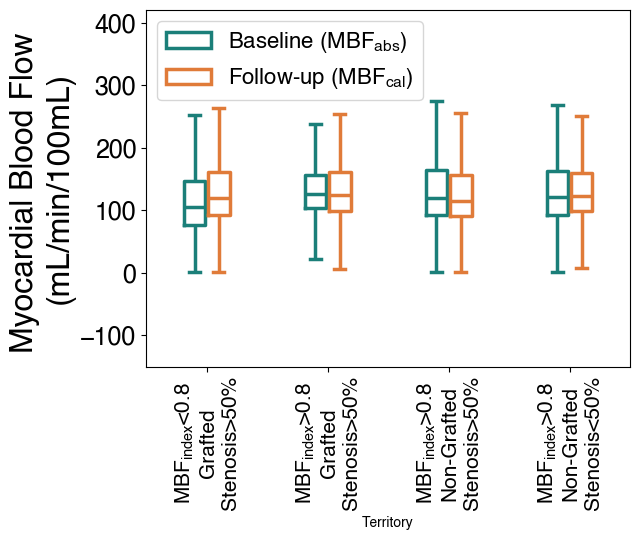

In [289]:
plt.figure(figsize=(6.5, 5.5))
ax = sns.boxplot(x='Territory', y='MBF', hue='Type', data= df_long, showfliers=False, width = 0.4,  linewidth=2.5, fill= False, gap=.1, palette={'Baseline ($\\mathrm{MBF_{abs}}$)':color1, 'Follow-up ($\\mathrm{MBF_{cal}}$)':color2})

ax.set_ylabel("Myocardial Blood Flow \n(mL/min/100mL)", fontsize = 23)
ax.tick_params(axis='x', rotation=90, labelsize=20)
ax.legend(loc = 'upper left', fontsize=16)
plt.xticks(fontsize=15)
plt.yticks(fontsize=18)
plt.ylim(-150,420)
plt.tight_layout()
plt.show()

#### Statistical Test

In [290]:
median_mbf_ischemic_A = []
median_mbf_ischemic_B = []

for _, row in df[df['is_ischemic'] == True].iterrows():
    median_mbf_ischemic_A.append(np.median(row['absMBF_A']))
    median_mbf_ischemic_B.append(np.median(row['absMBF_B']))

p_value_ischemic = WilcoxonTest(median_mbf_ischemic_A, median_mbf_ischemic_B)

Wilcoxon test statistics:  140.0
p-value:  0.00028363417528544014
number of datapoints: 40
Reject the null hypothesis: There is a significant difference between the two samples.


In [291]:
median_mbf_nonischemic_A = []
median_mbf_nonischemic_B = []

for _, row in df[(df['is_ischemic'] == False) & (df['tag'] != 'Non-grafted\nstenosis<50%') & (df['tag'] != "Non-grafted\nstenosis>50%")].iterrows():
    median_mbf_nonischemic_A.append(np.median(row['absMBF_A']))
    median_mbf_nonischemic_B.append(np.median(row['absMBF_B']))

p_value_non_ischemic = WilcoxonTest(median_mbf_nonischemic_A, median_mbf_nonischemic_B)

Wilcoxon test statistics:  188.5
p-value:  0.36530953758220774
number of datapoints: 30
Fail to reject the null hypothesis: There is no significant difference between the two samples.


In [292]:
median_mbf_stng_A = []
median_mbf_stng_B = []

for _, row in df[df['tag'] == 'Non-grafted\nstenosis>50%'].iterrows():
    median_mbf_stng_A.append(np.median(row['absMBF_A']))
    median_mbf_stng_B.append(np.median(row['absMBF_B']))

print(median_mbf_stng_A)

p_value_nongrafted_stenosis = WilcoxonTest(median_mbf_stng_A, median_mbf_stng_B)

[np.float64(118.0), np.float64(160.0), np.float64(108.0), np.float64(90.0), np.float64(147.0), np.float64(134.0), np.float64(114.0), np.float64(183.0), np.float64(100.0), np.float64(85.0), np.float64(101.0)]
Wilcoxon test statistics:  31.0
p-value:  0.8984375
number of datapoints: 11
Fail to reject the null hypothesis: There is no significant difference between the two samples.


In [293]:
median_mbf_ng_A = []
median_mbf_ng_B = []

for _, row in df[df['tag'] == 'Non-grafted\nstenosis<50%'].iterrows():
    median_mbf_ng_A.append(np.median(row['absMBF_A']))
    median_mbf_ng_B.append(np.median(row['absMBF_B']))

print(median_mbf_ng_A)
p_value_nongrafted = WilcoxonTest(median_mbf_ng_A, median_mbf_ng_B)

[np.float64(117.0), np.float64(187.0), np.float64(148.0), np.float64(149.0), np.float64(114.0), np.float64(106.0), np.float64(136.0), np.float64(95.0), np.float64(165.0), np.float64(100.0), np.float64(111.0), np.float64(154.0), np.float64(116.0), np.float64(165.0), np.float64(111.0), np.float64(96.0), np.float64(128.0), np.float64(109.0), np.float64(190.0), np.float64(98.0), np.float64(88.0), np.float64(87.0), np.float64(104.0), np.float64(111.0), np.float64(153.0), np.float64(119.0)]
Wilcoxon test statistics:  158.5
p-value:  0.6658231695349112
number of datapoints: 26
Fail to reject the null hypothesis: There is no significant difference between the two samples.


### Plot based on the severity of ischemia

In [294]:
print("TerritoryTag", "Median", "IQR", "Mean", "std")
mbf_ischemic10_A = np.concatenate(df[df['ischemic_grade'] == 1]['absMBF_A'].values)
q1, q2, q3 = np.percentile(mbf_ischemic10_A, [25, 50, 75])
average = np.mean(mbf_ischemic10_A)
std = np.std(mbf_ischemic10_A)
print("ischemic_grafted10_A", q2, q3-q1, average, std)

mbf_ischemic10_B = np.concatenate(df[df['ischemic_grade'] == 1]['absMBF_B'].values)
q1, q2, q3 = np.percentile(mbf_ischemic10_B, [25, 50, 75])
average = np.mean(mbf_ischemic10_B)
std = np.std(mbf_ischemic10_B)
print("ischemic_grafted10_B",q2, q3-q1, average, std)

mbf_ischemic20_A = np.concatenate(df[df['ischemic_grade'] == 2]['absMBF_A'].values)
q1, q2, q3 = np.percentile(mbf_ischemic20_A, [25, 50, 75])
average = np.mean(mbf_ischemic20_A)
std = np.std(mbf_ischemic20_A)
print("ischemic_grafted20_A", q2, q3-q1, average, std)

mbf_ischemic20_B = np.concatenate(df[df['ischemic_grade'] == 2]['absMBF_B'].values)
q1, q2, q3 = np.percentile(mbf_ischemic20_B, [25, 50, 75])
average = np.mean(mbf_ischemic20_B)
std = np.std(mbf_ischemic20_B)
print("ischemic_grafted20_B",q2, q3-q1, average, std)

mbf_ischemic30_A = np.concatenate(df[df['ischemic_grade'] == 3]['absMBF_A'].values)
q1, q2, q3 = np.percentile(mbf_ischemic30_A, [25, 50, 75])
average = np.mean(mbf_ischemic30_A)
std = np.std(mbf_ischemic30_A)
print("ischemic_grafted30_A", q2, q3-q1, average, std)

mbf_ischemic30_B = np.concatenate(df[df['ischemic_grade'] == 3]['absMBF_B'].values)
q1, q2, q3 = np.percentile(mbf_ischemic30_B, [25, 50, 75])
average = np.mean(mbf_ischemic30_B)
std = np.std(mbf_ischemic30_B)
print("ischemic_grafted30_B",q2, q3-q1, average, std)

mbf_nonischemic_A = np.concatenate(df[(df['ischemic_grade'] == 0) & (df['tag'] != 'Non-grafted\nstenosis<50%') & (df['tag'] != "Non-grafted\nstenosis>50%")]['absMBF_A'].values)
q1, q2, q3 = np.percentile(mbf_nonischemic_A, [25, 50, 75])
average = np.mean(mbf_nonischemic_A)
std = np.std(mbf_nonischemic_A)
print("nonischemic_grafted_A", q2, q3-q1, average, std)

mbf_nonischemic_B = np.concatenate(df[(df['ischemic_grade'] == 0) & (df['tag'] != 'Non-grafted\nstenosis<50%') & (df['tag'] != "Non-grafted\nstenosis>50%")]['absMBF_B'].values)
q1, q2, q3 = np.percentile(mbf_nonischemic_B, [25, 50, 75])
average = np.mean(mbf_nonischemic_B)
std = np.std(mbf_nonischemic_B)
print("nonischemic_grafted_B", q2, q3-q1, average, std)


TerritoryTag Median IQR Mean std
ischemic_grafted10_A 127.0 59.0 138.30215624829717 55.19366095182878
ischemic_grafted10_B 119.0 61.0 132.116607494282 57.55661672404265
ischemic_grafted20_A 112.0 66.0 130.46810220712965 69.75768695244811
ischemic_grafted20_B 122.0 68.0 136.35232923761114 66.91608842379854
ischemic_grafted30_A 93.0 72.0 110.72245032482378 69.80291414328818
ischemic_grafted30_B 116.0 71.0 129.70707725779002 63.42115170881515
nonischemic_grafted_A 120.0 42.0 122.89959457217743 38.480603143948706
nonischemic_grafted_B 143.0 51.0 145.7849222550573 49.17336952736123


In [295]:
# Create a DataFrame with each part
df_A = pd.DataFrame({
    'MBF': np.concatenate([mbf_ischemic30_A, mbf_ischemic20_A, mbf_ischemic10_A, mbf_nonischemic_A]),
    'Territory': ['<0.7'] * len(mbf_ischemic30_A) +
             ['0.7-0.8'] * len(mbf_ischemic20_A) +
             ['0.8-0.9'] * len(mbf_ischemic10_A) + 
             ['>0.9'] * len(mbf_nonischemic_A),  
    'Type': ['Baseline ($\\mathrm{MBF_{abs}}$)'] * (len(mbf_ischemic30_A) +len(mbf_ischemic20_A) +len(mbf_ischemic10_A) + len(mbf_nonischemic_A))
})

df_B = pd.DataFrame({
    'MBF': np.concatenate([mbf_ischemic30_B, mbf_ischemic20_B, mbf_ischemic10_B, mbf_nonischemic_B]),
    'Territory': ['<0.7'] * len(mbf_ischemic30_B) +
             ['0.7-0.8'] * len(mbf_ischemic20_B) +
             ['0.8-0.9'] * len(mbf_ischemic10_B) + 
             ['>0.9'] * len(mbf_nonischemic_B),
    'Type': ['Follow-up ($\\mathrm{MBF_{cal}}$)'] * (len(mbf_ischemic30_B) + len(mbf_ischemic20_B) + len(mbf_ischemic10_B) + len(mbf_nonischemic_B))
})

# Combine into a single DataFrame
df_long = pd.concat([df_A, df_B], ignore_index=True)

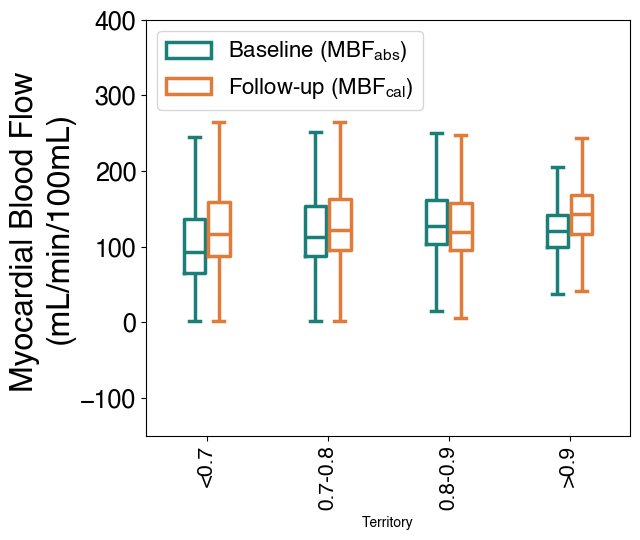

In [296]:
plt.figure(figsize=(6.5, 5.5))
ax = sns.boxplot(x='Territory', y='MBF', hue='Type', data= df_long, showfliers=False, width = 0.4, linewidth=2.5, fill= False, gap=.1, palette={'Baseline ($\\mathrm{MBF_{abs}}$)':color1, 'Follow-up ($\\mathrm{MBF_{cal}}$)':color2})

ax.set_ylabel("Myocardial Blood Flow \n(mL/min/100mL)", fontsize = 23)
ax.tick_params(axis='x', rotation=90, labelsize=18)
ax.legend(loc = 'upper left', fontsize=16)
plt.xticks(fontsize=15)
plt.yticks(fontsize=18)
plt.ylim(-150,400)
plt.tight_layout()
plt.show()

#### Statistical Tests

In [297]:
median_mbf_ischemic10_A = []
median_mbf_ischemic10_B = []

for _, row in df[df['ischemic_grade'] == 1].iterrows():
    median_mbf_ischemic10_A.append(np.median(row['absMBF_A']))
    median_mbf_ischemic10_B.append(np.median(row['absMBF_B']))

WilcoxonTest(median_mbf_ischemic10_A, median_mbf_ischemic10_B)

Wilcoxon test statistics:  95.5
p-value:  0.4866961011303135
number of datapoints: 21
Fail to reject the null hypothesis: There is no significant difference between the two samples.


np.float64(0.4866961011303135)

In [298]:
median_mbf_ischemic20_A = []
median_mbf_ischemic20_B = []

for _, row in df[df['ischemic_grade'] == 2].iterrows():
    median_mbf_ischemic20_A.append(np.median(row['absMBF_A']))
    median_mbf_ischemic20_B.append(np.median(row['absMBF_B']))

WilcoxonTest(median_mbf_ischemic20_A, median_mbf_ischemic20_B)

Wilcoxon test statistics:  58.5
p-value:  0.08230190177584372
number of datapoints: 20
Fail to reject the null hypothesis: There is no significant difference between the two samples.


np.float64(0.08230190177584372)

In [299]:
median_mbf_ischemic30_A = []
median_mbf_ischemic30_B = []

for _, row in df[df['ischemic_grade'] == 3].iterrows():
    median_mbf_ischemic30_A.append(np.median(row['absMBF_A']))
    median_mbf_ischemic30_B.append(np.median(row['absMBF_B']))

WilcoxonTest(median_mbf_ischemic30_A, median_mbf_ischemic30_B)

Wilcoxon test statistics:  21.0
p-value:  0.000850677490234375
number of datapoints: 20
Reject the null hypothesis: There is a significant difference between the two samples.


np.float64(0.000850677490234375)

In [300]:
median_mbf_ischemic0_A = []
median_mbf_ischemic0_B = []

for _, row in df[(df['ischemic_grade'] == 0) & (df['tag'] != 'Non-grafted\nstenosis<50%') & (df['tag'] != "Non-grafted\nstenosis>50%")].iterrows():
    median_mbf_ischemic0_A.append(np.median(row['absMBF_A']))
    median_mbf_ischemic0_B.append(np.median(row['absMBF_B']))

WilcoxonTest(median_mbf_ischemic0_A, median_mbf_ischemic0_B)

Wilcoxon test statistics:  4.5
p-value:  0.03125
number of datapoints: 9
Reject the null hypothesis: There is a significant difference between the two samples.


np.float64(0.03125)

### Mapping post on pre

In [56]:
dataMapped = []

for patient_id in patient_ids:
    if patient_id in Removed_Cases: 
        continue
    tags = list(PatientMetadata[PatientMetadata['patient-id'] == patient_id]['stenosis tag'])
    ischemia = list(PatientMetadata[PatientMetadata['patient-id'] == patient_id]['is-ischemic'])
    TerritoryTags = [f'post_{tag}' for tag in tags]
    cutoff = list(PatientMetadata[PatientMetadata['patient-id'] == patient_id]['cutoff'])[0]
    grafts = list(PatientMetadata[PatientMetadata['patient-id'] == patient_id]['graft'])
    graft_stenosis = list(PatientMetadata[PatientMetadata['patient-id'] == patient_id]['graft-stenosis'])
    if cutoff == 0:
        cutoff = 142
    for file in TerritoryLabels:
        if patient_id in os.path.basename(os.path.splitext(file)[0]):
            LabelFile = file
    MBF_Labels = ReadLabels(LabelFile, TerritoryTags)
    normalization_method = "classic"
    for file in VTUFiles:
        if f"{patient_id}A" in os.path.basename(os.path.splitext(file)[0]):
            MBF_A = ReadVTUFile(file)
        elif f"{patient_id}B" in os.path.basename(os.path.splitext(file)[0]):
            MBF_B = ReadVTUFile(file)
    AbsMBFData_A = CollectMBFData(MBF_A, MBF_Labels)
    AbsMBFData_B = CollectMBFData(MBF_B, MBF_Labels)

    t = "Non-grafted\nstenosis<50%"
    array_A = AbsMBFData_A[t]
    mean_A = np.mean(array_A)
    std_A = np.std(array_A)
    array_B = AbsMBFData_B[t]
    mean_B = np.mean(array_B)
    std_B = np.std(array_B)


    ScalaraArrayName = GetScalarArrayName(MBF_A)
    scalar_array_A = vtk_to_numpy(MBF_A.GetPointData().GetArray(ScalaraArrayName))
    ref = np.percentile(scalar_array_A, 75)

    threshold1 = 0.9 * ref #mbf_median_non_grafted  # 10% drop
    threshold2 = 0.8 * ref #mbf_median_non_grafted  # 20% drop
    threshold3 = 0.7 * ref #mbf_median_non_grafted  # 30% drop



    for i, t in enumerate(tags):
        AbsMBFData_B_mapped = MapNongrafted(mean_B, mean_A, std_B, std_A, AbsMBFData_B[t])
        mbf_median = np.median(AbsMBFData_A[t])
        if mbf_median > threshold1:
            is_ischemic = False
            ischemia_grade = 0
        elif threshold2 < mbf_median <= threshold1:
            is_ischemic = True
            ischemia_grade = 1
        elif threshold3 < mbf_median <= threshold2:
            is_ischemic = True
            ischemia_grade = 2
        else:
            is_ischemic = True
            ischemia_grade = 3

        data_ = {"patient_id": patient_id, "tag": t, "graft_type": grafts[i], "is_ischemic": is_ischemic, "ischemic_grade":ischemia_grade, "graft_stenosis": graft_stenosis[i], "absMBF_A": AbsMBFData_A[t], "absMBF_B": AbsMBFData_B_mapped, "rawMBF_A": AbsMBFData_A[t]}
        dataMapped.append(data_)
    t = "Non-grafted\nstenosis>50%"
    if t in MBF_Labels.keys():
        AbsMBFData_B_mapped = MapNongrafted(mean_B, mean_A, std_B, std_A, AbsMBFData_B[t])
        data_ = {"patient_id": patient_id, "tag": t, "graft_type": None, "is_ischemic": False, "ischemic_grade":0, "graft_stenosis": 0, "absMBF_A": AbsMBFData_A[t], "absMBF_B": AbsMBFData_B_mapped, "rawMBF_A": AbsMBFData_A[t]}
        dataMapped.append(data_)
    t = "Non-grafted\nstenosis<50%"
    AbsMBFData_B_mapped = MapNongrafted(mean_B, mean_A, std_B, std_A, AbsMBFData_B[t])
    data_ = {"patient_id": patient_id, "tag": t, "graft_type": None, "is_ischemic": False, "ischemic_grade":0, "graft_stenosis": 0, "absMBF_A": AbsMBFData_A[t], "absMBF_B": AbsMBFData_B_mapped, "rawMBF_A": AbsMBFData_A[t]}
    dataMapped.append(data_)


In [57]:
df = pd.DataFrame(dataMapped)

In [58]:
print("TerritoryTag", "Median", "IQR", "Mean", "std")
mbf_ischemic_A = np.concatenate(df[(df['tag'] != 'Non-grafted\nstenosis<50%') & (df['tag'] != "Non-grafted\nstenosis>50%")]['absMBF_A'].values)
q1, q2, q3 = np.percentile(mbf_ischemic_A, [25, 50, 75])
average_g = np.mean(mbf_ischemic_A)
std = np.std(mbf_ischemic_A)
print("all_grafted_A", q2, q3-q1, average_g, std)

mbf_ischemic_B = np.concatenate(df[(df['tag'] != 'Non-grafted\nstenosis<50%') & (df['tag'] != "Non-grafted\nstenosis>50%")]['absMBF_B'].values)
q1, q2, q3 = np.percentile(mbf_ischemic_B, [25, 50, 75])
average = np.mean(mbf_ischemic_B)
std = np.std(mbf_ischemic_B)
print("all_grafted_B",q2, q3-q1, average, std)

TerritoryTag Median IQR Mean std
all_grafted_A 114.0 66.0 126.86697778690359 64.78067297381784
all_grafted_B 117.2553937446372 64.99948618145535 130.0936956458794 62.917743151821455


In [59]:
print("TerritoryTag", "Median", "IQR", "Mean", "std")
mbf_ischemic_A = np.concatenate(df[(df['tag'] == 'Non-grafted\nstenosis<50%') | (df['tag'] == "Non-grafted\nstenosis>50%")]['absMBF_A'].values)
q1, q2, q3 = np.percentile(mbf_ischemic_A, [25, 50, 75])
average_ng = np.mean(mbf_ischemic_A)
std = np.std(mbf_ischemic_A)
print("all_not_grafted_A", q2, q3-q1, average_ng, std)

mbf_ischemic_B = np.concatenate(df[(df['tag'] == 'Non-grafted\nstenosis<50%') | (df['tag'] == "Non-grafted\nstenosis>50%")]['absMBF_B'].values)
q1, q2, q3 = np.percentile(mbf_ischemic_B, [25, 50, 75])
average = np.mean(mbf_ischemic_B)
std = np.std(mbf_ischemic_B)
print("all_not_grafted_B",q2, q3-q1, average, std)

TerritoryTag Median IQR Mean std
all_not_grafted_A 121.0 70.0 135.68990049194815 67.44702953780221
all_not_grafted_B 119.30178927924355 66.28561345038855 134.56918950410812 67.61141827238895


In [60]:
print("TerritoryTag", "Median", "IQR", "Mean", "std")
mbf_ischemic_A = np.concatenate(df[(df['tag'] == 'Non-grafted\nstenosis<50%')]['absMBF_A'].values)
q1, q2, q3 = np.percentile(mbf_ischemic_A, [25, 50, 75])
average_ng = np.mean(mbf_ischemic_A)
std = np.std(mbf_ischemic_A)
print("nosten_not_grafted_A", q2, q3-q1, average_ng, std)

print("TerritoryTag", "Median", "IQR", "Mean", "std")
mbf_ischemic_A = np.concatenate(df[(df['tag'] == "Non-grafted\nstenosis>50%")]['absMBF_A'].values)
q1, q2, q3 = np.percentile(mbf_ischemic_A, [25, 50, 75])
average_ng = np.mean(mbf_ischemic_A)
std = np.std(mbf_ischemic_A)
print("sten_not_grafted_A", q2, q3-q1, average_ng, std)

TerritoryTag Median IQR Mean std
nosten_not_grafted_A 121.0 70.0 135.49542030642618 66.1213015925952
TerritoryTag Median IQR Mean std
sten_not_grafted_A 120.0 73.0 136.28203037095275 71.32863030456936


In [61]:
median_mbf_ng_sten_A = [] #grafted regions
median_mbf_ng_nsten_A = [] # not grafted regions

for _, row in df[(df['tag'] == "Non-grafted\nstenosis>50%")].iterrows():
    median_mbf_ng_sten_A.append(np.median(row['absMBF_A']))
for _, row in df[(df['tag'] == 'Non-grafted\nstenosis<50%')].iterrows():
    median_mbf_ng_nsten_A.append(np.median(row['absMBF_A']))

stat, p_value_ = mannwhitneyu(median_mbf_ng_sten_A, median_mbf_ng_nsten_A, alternative="two-sided")
print(stat)
print(p_value_)
print(p_value_<0.05)

130.0
0.6777513702467113
False


In [62]:
median_mbf_g_A = [] #grafted regions
median_mbf_ng_A = [] # not grafted regions

for _, row in df[(df['tag'] != 'Non-grafted\nstenosis<50%') & (df['tag'] != "Non-grafted\nstenosis>50%")].iterrows():
    median_mbf_g_A.append(np.median(row['absMBF_A']))
for _, row in df[(df['tag'] == 'Non-grafted\nstenosis<50%') | (df['tag'] == "Non-grafted\nstenosis>50%")].iterrows():
    median_mbf_ng_A.append(np.median(row['absMBF_A']))

stat, p_value_ = mannwhitneyu(median_mbf_ng_A, median_mbf_g_A, alternative="greater")
print(stat)
print(p_value_)
print(p_value_<0.05)

1526.0
0.06551393621434572
False


In [63]:
median_mbf_sg_A = [] #with stenosis grafted
median_mbf_nsg_A = [] #not stenosis grafted

for _, row in df[df['is_ischemic'] == True].iterrows():
    median_mbf_sg_A.append(np.median(row['absMBF_A']))
for _, row in df[(df['is_ischemic'] == False) & (df['tag'] != 'Non-grafted\nstenosis<50%') & (df['tag'] != "Non-grafted\nstenosis>50%")].iterrows():
    median_mbf_nsg_A.append(np.median(row['absMBF_A']))

stat, p_value_ = mannwhitneyu(median_mbf_nsg_A, median_mbf_sg_A, alternative="greater")
print(stat)
print(p_value_)
print(p_value_<0.05)

330.0
0.1671924584919266
False


In [64]:
median_mbf_sg_B = [] #with stenosis grafted
median_mbf_nsg_B = [] #not stenosis grafted

for _, row in df[df['is_ischemic'] == True].iterrows():
    median_mbf_sg_B.append(np.median(row['absMBF_B']))
for _, row in df[(df['is_ischemic'] == False) & (df['tag'] != 'Non-grafted\nstenosis<50%') & (df['tag'] != "Non-grafted\nstenosis>50%")].iterrows():
    median_mbf_nsg_B.append(np.median(row['absMBF_B']))

stat, p_value_ = mannwhitneyu(median_mbf_nsg_B, median_mbf_sg_B, alternative="greater")
print(stat)
print(p_value_)
print(p_value_<0.05)

212.0
0.86550903325154
False


In [65]:
print("TerritoryTag", "Median", "IQR", "Mean", "std")
mbf_ischemic_A = np.concatenate(df[df['is_ischemic'] == True]['absMBF_A'].values)
q1, q2, q3 = np.percentile(mbf_ischemic_A, [25, 50, 75])
average = np.mean(mbf_ischemic_A)
std = np.std(mbf_ischemic_A)
print("ischemic_grafted_A", q2, q3-q1, average, std)

mbf_ischemic_B = np.concatenate(df[df['is_ischemic'] == True]['absMBF_B'].values)
q1, q2, q3 = np.percentile(mbf_ischemic_B, [25, 50, 75])
average = np.mean(mbf_ischemic_B)
std = np.std(mbf_ischemic_B)
print("ischemic_grafted_B",q2, q3-q1, average, std)

mbf_nonischemic_A = np.concatenate(df[(df['is_ischemic'] == False) & (df['tag'] != 'Non-grafted\nstenosis<50%') & (df['tag'] != "Non-grafted\nstenosis>50%")]['absMBF_A'].values)
q1, q2, q3 = np.percentile(mbf_nonischemic_A, [25, 50, 75])
average = np.mean(mbf_nonischemic_A)
std = np.std(mbf_nonischemic_A)
print("nonischemic_grafted_A", q2, q3-q1, average, std)

mbf_nonischemic_B = np.concatenate(df[(df['is_ischemic'] == False) & (df['tag'] != 'Non-grafted\nstenosis<50%') & (df['tag'] != "Non-grafted\nstenosis>50%")]['absMBF_B'].values)
q1, q2, q3 = np.percentile(mbf_nonischemic_B, [25, 50, 75])
average = np.mean(mbf_nonischemic_B)
std = np.std(mbf_nonischemic_B)
print("nonischemic_grafted_B", q2, q3-q1, average, std)

mbf_st_nongrafted_A = np.concatenate(df[df['tag'] == 'Non-grafted\nstenosis>50%']['absMBF_A'].values)
q1, q2, q3 = np.percentile(mbf_st_nongrafted_A, [25, 50, 75])
average = np.mean(mbf_st_nongrafted_A)
std = np.std(mbf_st_nongrafted_A)
print("stenosed_nongrafted_A", q2, q3-q1, average, std)

mbf_st_nongrafted_B = np.concatenate(df[df['tag'] == 'Non-grafted\nstenosis>50%']['absMBF_B'].values)
q1, q2, q3 = np.percentile(mbf_st_nongrafted_B, [25, 50, 75])
average = np.mean(mbf_st_nongrafted_B)
std = np.std(mbf_st_nongrafted_B)
print("stenosed_nongrafted_B", q2, q3-q1, average, std)

mbf_nongrafted_A = np.concatenate(df[df['tag'] == 'Non-grafted\nstenosis<50%']['absMBF_A'].values)
q1, q2, q3 = np.percentile(mbf_nongrafted_A, [25, 50, 75])
average = np.mean(mbf_nongrafted_A)
std = np.std(mbf_nongrafted_A)
print("nongrafted_A", q2, q3-q1, average, std)

mbf_nongrafted_B = np.concatenate(df[df['tag'] == 'Non-grafted\nstenosis<50%']['absMBF_B'].values)
q1, q2, q3 = np.percentile(mbf_nongrafted_B, [25, 50, 75])
average = np.mean(mbf_nongrafted_B)
std = np.std(mbf_nongrafted_B)
print("nongrafted_B", q2, q3-q1, average, std)


TerritoryTag Median IQR Mean std
ischemic_grafted_A 114.0 69.0 127.16177097044064 66.31042801587809
ischemic_grafted_B 117.3949001665212 66.60327457425466 130.76372243163627 64.19968206155755
nonischemic_grafted_A 120.0 42.0 122.89959457217743 38.480603143948706
nonischemic_grafted_B 115.69512791195334 47.37739956130066 121.30221115265218 41.680817139873284
stenosed_nongrafted_A 120.0 73.0 136.28203037095275 71.32863030456936
stenosed_nongrafted_B 115.15791554688711 77.79768851358531 131.95745776049063 71.6364596900864
nongrafted_A 121.0 70.0 135.49542030642618 66.1213015925952
nongrafted_B 120.33018981927053 62.88254872811487 135.3583417068397 66.32697602059488


In [66]:
df_A = pd.DataFrame({
    'MBF': np.concatenate([mbf_ischemic_A, mbf_nonischemic_A, mbf_st_nongrafted_A, mbf_nongrafted_A]),
    'Territory':
             ['$\\mathrm{MBF_{index}}$<0.9\nGrafted\nStenosis>50%'] * len(mbf_ischemic_A) + 
             ['$\\mathrm{MBF_{index}}$>0.9\nGrafted\nStenosis>50%'] * len(mbf_nonischemic_A) + 
             ['$\\mathrm{MBF_{index}}$>0.9\nNon-Grafted\nStenosis>50%'] * len(mbf_st_nongrafted_A) +
             ['$\\mathrm{MBF_{index}}$>0.9\nNon-Grafted\nStenosis<50%'] * len(mbf_nongrafted_A),
    'Type': ['Baseline ($\\mathrm{MBF_{abs}}$)'] * (len(mbf_ischemic_A) + len(mbf_nonischemic_A) + len(mbf_st_nongrafted_A) + len(mbf_nongrafted_A))
})

df_B = pd.DataFrame({
    'MBF': np.concatenate([mbf_ischemic_B, mbf_nonischemic_B, mbf_st_nongrafted_B, mbf_nongrafted_B]),
    'Territory':
             ['$\\mathrm{MBF_{index}}$<0.9\nGrafted\nStenosis>50%'] * len(mbf_ischemic_B) + 
             ['$\\mathrm{MBF_{index}}$>0.9\nGrafted\nStenosis>50%'] * len(mbf_nonischemic_B) + 
             ['$\\mathrm{MBF_{index}}$>0.9\nNon-Grafted\nStenosis>50%'] * len(mbf_st_nongrafted_B) +
             ['$\\mathrm{MBF_{index}}$>0.9\nNon-Grafted\nStenosis<50%'] * len(mbf_nongrafted_B),
    'Type': ['Follow-up ($\\mathrm{MBF_{cal}}$)'] * (len(mbf_ischemic_B) + len(mbf_nonischemic_B) + len(mbf_st_nongrafted_B) + len(mbf_nongrafted_B))
})

df_long = pd.concat([df_A, df_B], ignore_index=True)

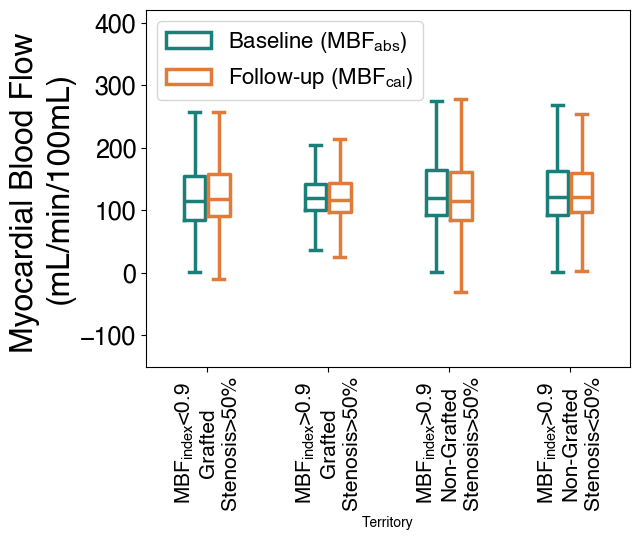

In [67]:
plt.figure(figsize=(6.5, 5.5))
ax = sns.boxplot(x='Territory', y='MBF', hue='Type', data= df_long, showfliers=False, width = 0.4,  linewidth=2.5, fill= False, gap=.1, palette={'Baseline ($\\mathrm{MBF_{abs}}$)':color1, 'Follow-up ($\\mathrm{MBF_{cal}}$)':color2})

ax.set_ylabel("Myocardial Blood Flow \n(mL/min/100mL)", fontsize = 23)
ax.tick_params(axis='x', rotation=90, labelsize=20)
ax.legend(loc = 'upper left', fontsize=16)
plt.xticks(fontsize=15)
plt.yticks(fontsize=18)
plt.ylim(-150,420)
plt.tight_layout()
plt.show()

#### Statistical Test

In [68]:
median_mbf_ischemic_A = []
median_mbf_ischemic_B = []

for _, row in df[df['is_ischemic'] == True].iterrows():
    median_mbf_ischemic_A.append(np.median(row['absMBF_A']))
    median_mbf_ischemic_B.append(np.median(row['absMBF_B']))

p_value_ischemic = WilcoxonTest(median_mbf_ischemic_A, median_mbf_ischemic_B)

Wilcoxon test statistics:  394.0
p-value:  7.454256115999521e-05
number of datapoints: 61
Reject the null hypothesis: There is a significant difference between the two samples.


In [69]:
median_mbf_nonischemic_A = []
median_mbf_nonischemic_B = []

for _, row in df[(df['is_ischemic'] == False) & (df['tag'] != 'Non-grafted\nstenosis<50%') & (df['tag'] != "Non-grafted\nstenosis>50%")].iterrows():
    median_mbf_nonischemic_A.append(np.median(row['absMBF_A']))
    median_mbf_nonischemic_B.append(np.median(row['absMBF_B']))

p_value_non_ischemic = WilcoxonTest(median_mbf_nonischemic_A, median_mbf_nonischemic_B)

Wilcoxon test statistics:  20.0
p-value:  0.8203125
number of datapoints: 9
Fail to reject the null hypothesis: There is no significant difference between the two samples.


In [70]:
median_mbf_stng_A = []
median_mbf_stng_B = []

for _, row in df[df['tag'] == 'Non-grafted\nstenosis>50%'].iterrows():
    median_mbf_stng_A.append(np.median(row['absMBF_A']))
    median_mbf_stng_B.append(np.median(row['absMBF_B']))

p_value_nongrafted_stenosis = WilcoxonTest(median_mbf_stng_A, median_mbf_stng_B)

Wilcoxon test statistics:  30.0
p-value:  0.8310546875
number of datapoints: 11
Fail to reject the null hypothesis: There is no significant difference between the two samples.


In [71]:
median_mbf_ng_A = []
median_mbf_ng_B = []

for _, row in df[df['tag'] == 'Non-grafted\nstenosis<50%'].iterrows():
    median_mbf_ng_A.append(np.median(row['absMBF_A']))
    median_mbf_ng_B.append(np.median(row['absMBF_B']))

p_value_nongrafted = WilcoxonTest(median_mbf_ng_A, median_mbf_ng_B)

Wilcoxon test statistics:  160.0
p-value:  0.7078457474708557
number of datapoints: 26
Fail to reject the null hypothesis: There is no significant difference between the two samples.


#### Plot based on the severity of ischemia

In [72]:
print("TerritoryTag", "Median", "IQR", "Mean", "std")
mbf_ischemic10_A = np.concatenate(df[df['ischemic_grade'] == 1]['absMBF_A'].values)
q1, q2, q3 = np.percentile(mbf_ischemic10_A, [25, 50, 75])
average = np.mean(mbf_ischemic10_A)
std = np.std(mbf_ischemic10_A)
print("ischemic_grafted10_A", q2, q3-q1, average, std)

mbf_ischemic10_B = np.concatenate(df[df['ischemic_grade'] == 1]['absMBF_B'].values)
q1, q2, q3 = np.percentile(mbf_ischemic10_B, [25, 50, 75])
average = np.mean(mbf_ischemic10_B)
std = np.std(mbf_ischemic10_B)
print("ischemic_grafted10_B",q2, q3-q1, average, std)

mbf_ischemic20_A = np.concatenate(df[df['ischemic_grade'] == 2]['absMBF_A'].values)
q1, q2, q3 = np.percentile(mbf_ischemic20_A, [25, 50, 75])
average = np.mean(mbf_ischemic20_A)
std = np.std(mbf_ischemic20_A)
print("ischemic_grafted20_A", q2, q3-q1, average, std)

mbf_ischemic20_B = np.concatenate(df[df['ischemic_grade'] == 2]['absMBF_B'].values)
q1, q2, q3 = np.percentile(mbf_ischemic20_B, [25, 50, 75])
average = np.mean(mbf_ischemic20_B)
std = np.std(mbf_ischemic20_B)
print("ischemic_grafted20_B",q2, q3-q1, average, std)

mbf_ischemic30_A = np.concatenate(df[df['ischemic_grade'] == 3]['absMBF_A'].values)
q1, q2, q3 = np.percentile(mbf_ischemic30_A, [25, 50, 75])
average = np.mean(mbf_ischemic30_A)
std = np.std(mbf_ischemic30_A)
print("ischemic_grafted30_A", q2, q3-q1, average, std)

mbf_ischemic30_B = np.concatenate(df[df['ischemic_grade'] == 3]['absMBF_B'].values)
q1, q2, q3 = np.percentile(mbf_ischemic30_B, [25, 50, 75])
average = np.mean(mbf_ischemic30_B)
std = np.std(mbf_ischemic30_B)
print("ischemic_grafted30_B",q2, q3-q1, average, std)

mbf_nonischemic_A = np.concatenate(df[(df['ischemic_grade'] == 0) & (df['tag'] != 'Non-grafted\nstenosis<50%') & (df['tag'] != "Non-grafted\nstenosis>50%")]['absMBF_A'].values)
q1, q2, q3 = np.percentile(mbf_nonischemic_A, [25, 50, 75])
average = np.mean(mbf_nonischemic_A)
std = np.std(mbf_nonischemic_A)
print("nonischemic_grafted_A", q2, q3-q1, average, std)

mbf_nonischemic_B = np.concatenate(df[(df['ischemic_grade'] == 0) & (df['tag'] != 'Non-grafted\nstenosis<50%') & (df['tag'] != "Non-grafted\nstenosis>50%")]['absMBF_B'].values)
q1, q2, q3 = np.percentile(mbf_nonischemic_B, [25, 50, 75])
average = np.mean(mbf_nonischemic_B)
std = np.std(mbf_nonischemic_B)
print("nonischemic_grafted_B", q2, q3-q1, average, std)


TerritoryTag Median IQR Mean std
ischemic_grafted10_A 127.0 59.0 138.30215624829717 55.19366095182878
ischemic_grafted10_B 123.25820628164304 66.5743768940823 132.40615063267546 58.706802564547544
ischemic_grafted20_A 112.0 66.0 130.46810220712965 69.75768695244811
ischemic_grafted20_B 118.4179313823901 67.68620416136781 132.14486023956846 67.37099213567376
ischemic_grafted30_A 93.0 72.0 110.72245032482378 69.80291414328818
ischemic_grafted30_B 111.13490377218679 63.20998558353736 127.16642641307996 65.62815634352577
nonischemic_grafted_A 120.0 42.0 122.89959457217743 38.480603143948706
nonischemic_grafted_B 115.69512791195334 47.37739956130066 121.30221115265218 41.680817139873284


In [73]:
# Create a DataFrame with each part
df_A = pd.DataFrame({
    'MBF': np.concatenate([mbf_ischemic30_A, mbf_ischemic20_A, mbf_ischemic10_A, mbf_nonischemic_A]),
    'Territory': ['<0.7'] * len(mbf_ischemic30_A) +
             ['0.7-0.8'] * len(mbf_ischemic20_A) +
             ['0.8-0.9'] * len(mbf_ischemic10_A) + 
             ['>0.9'] * len(mbf_nonischemic_A),  
    'Type': ['Baseline ($\\mathrm{MBF_{abs}}$)'] * (len(mbf_ischemic30_A) +len(mbf_ischemic20_A) +len(mbf_ischemic10_A) + len(mbf_nonischemic_A))
})

df_B = pd.DataFrame({
    'MBF': np.concatenate([mbf_ischemic30_B, mbf_ischemic20_B, mbf_ischemic10_B, mbf_nonischemic_B]),
    'Territory': ['<0.7'] * len(mbf_ischemic30_B) +
             ['0.7-0.8'] * len(mbf_ischemic20_B) +
             ['0.8-0.9'] * len(mbf_ischemic10_B) + 
             ['>0.9'] * len(mbf_nonischemic_B),
    'Type': ['Follow-up ($\\mathrm{MBF_{cal}}$)'] * (len(mbf_ischemic30_B) + len(mbf_ischemic20_B) + len(mbf_ischemic10_B) + len(mbf_nonischemic_B))
})

# Combine into a single DataFrame
df_long = pd.concat([df_A, df_B], ignore_index=True)

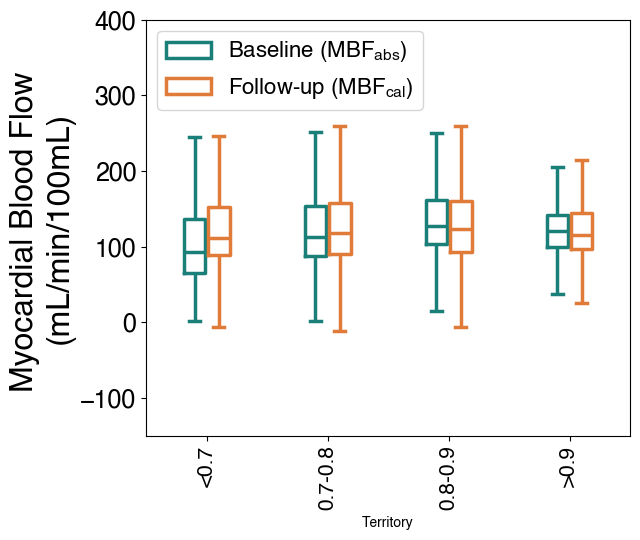

In [74]:
plt.figure(figsize=(6.5, 5.5))
ax = sns.boxplot(x='Territory', y='MBF', hue='Type', data= df_long, showfliers=False, width = 0.4, linewidth=2.5, fill= False, gap=.1, palette={'Baseline ($\\mathrm{MBF_{abs}}$)':color1, 'Follow-up ($\\mathrm{MBF_{cal}}$)':color2})

ax.set_ylabel("Myocardial Blood Flow \n(mL/min/100mL)", fontsize = 23)
ax.tick_params(axis='x', rotation=90, labelsize=18)
ax.legend(loc = 'upper left', fontsize=16)
plt.xticks(fontsize=15)
plt.yticks(fontsize=18)
plt.ylim(-150,400)
plt.tight_layout()
plt.show()

#### Statistical Test

In [75]:
median_mbf_ischemic10_A = []
median_mbf_ischemic10_B = []

for _, row in df[df['ischemic_grade'] == 1].iterrows():
    median_mbf_ischemic10_A.append(np.median(row['absMBF_A']))
    median_mbf_ischemic10_B.append(np.median(row['absMBF_B']))

WilcoxonTest(median_mbf_ischemic10_A, median_mbf_ischemic10_B)

Wilcoxon test statistics:  80.0
p-value:  0.22898578643798828
number of datapoints: 21
Fail to reject the null hypothesis: There is no significant difference between the two samples.


np.float64(0.22898578643798828)

In [76]:
median_mbf_ischemic20_A = []
median_mbf_ischemic20_B = []

for _, row in df[df['ischemic_grade'] == 2].iterrows():
    median_mbf_ischemic20_A.append(np.median(row['absMBF_A']))
    median_mbf_ischemic20_B.append(np.median(row['absMBF_B']))

WilcoxonTest(median_mbf_ischemic20_A, median_mbf_ischemic20_B)

Wilcoxon test statistics:  68.0
p-value:  0.17685317993164062
number of datapoints: 20
Fail to reject the null hypothesis: There is no significant difference between the two samples.


np.float64(0.17685317993164062)

In [77]:
median_mbf_ischemic30_A = []
median_mbf_ischemic30_B = []

for _, row in df[df['ischemic_grade'] == 3].iterrows():
    median_mbf_ischemic30_A.append(np.median(row['absMBF_A']))
    median_mbf_ischemic30_B.append(np.median(row['absMBF_B']))

WilcoxonTest(median_mbf_ischemic30_A, median_mbf_ischemic30_B)

Wilcoxon test statistics:  20.0
p-value:  0.0007076263427734375
number of datapoints: 20
Reject the null hypothesis: There is a significant difference between the two samples.


np.float64(0.0007076263427734375)

In [78]:
median_mbf_ischemic0_A = []
median_mbf_ischemic0_B = []

for _, row in df[(df['ischemic_grade'] == 0) & (df['tag'] != 'Non-grafted\nstenosis<50%') & (df['tag'] != "Non-grafted\nstenosis>50%")].iterrows():
    median_mbf_ischemic0_A.append(np.median(row['absMBF_A']))
    median_mbf_ischemic0_B.append(np.median(row['absMBF_B']))

WilcoxonTest(median_mbf_ischemic0_A, median_mbf_ischemic0_B)

Wilcoxon test statistics:  20.0
p-value:  0.8203125
number of datapoints: 9
Fail to reject the null hypothesis: There is no significant difference between the two samples.


np.float64(0.8203125)

### Results without calibration

In [79]:
dataMapped = []

for patient_id in patient_ids:
    if patient_id in Removed_Cases: 
        continue
    tags = list(PatientMetadata[PatientMetadata['patient-id'] == patient_id]['stenosis tag'])
    ischemia = list(PatientMetadata[PatientMetadata['patient-id'] == patient_id]['is-ischemic'])
    TerritoryTags = [f'post_{tag}' for tag in tags]
    cutoff = list(PatientMetadata[PatientMetadata['patient-id'] == patient_id]['cutoff'])[0]
    grafts = list(PatientMetadata[PatientMetadata['patient-id'] == patient_id]['graft'])
    graft_stenosis = list(PatientMetadata[PatientMetadata['patient-id'] == patient_id]['graft-stenosis'])
    if cutoff == 0:
        cutoff = 142
    for file in TerritoryLabels:
        if patient_id in os.path.basename(os.path.splitext(file)[0]):
            LabelFile = file
    MBF_Labels = ReadLabels(LabelFile, TerritoryTags)
    normalization_method = "classic"
    for file in VTUFiles:
        if f"{patient_id}A" in os.path.basename(os.path.splitext(file)[0]):
            MBF_A = Normalize(ReadVTUFile(file), normalization_method, cutoff/2)
        elif f"{patient_id}B" in os.path.basename(os.path.splitext(file)[0]):
            MBF_B = Normalize(ReadVTUFile(file), normalization_method, cutoff/2)
    AbsMBFData_A = CollectMBFData(MBF_A, MBF_Labels)
    AbsMBFData_B = CollectMBFData(MBF_B, MBF_Labels)

    t = "Non-grafted\nstenosis<50%"
    array_A = AbsMBFData_A[t]
    mean_A = np.mean(array_A)
    std_A = np.std(array_A)
    array_B = AbsMBFData_B[t]
    mean_B = np.mean(array_B)
    std_B = np.std(array_B)

    t = "Non-grafted\nstenosis>50%"
    if t in MBF_Labels.keys():
        array_A_ = AbsMBFData_A[t]
    mbf_median_non_grafted = np.median(MapNongrafted(mean_A, mean_B, std_A, std_B, np.concatenate([array_A, array_A_])))

    ScalaraArrayName = GetScalarArrayName(MBF_A)
    scalar_array_A = vtk_to_numpy(MBF_A.GetPointData().GetArray(ScalaraArrayName))
    ref = np.percentile(scalar_array_A, 75)

    threshold1 = 0.9 * ref #mbf_median_non_grafted  # 10% drop
    threshold2 = 0.8 * ref #mbf_median_non_grafted  # 20% drop
    threshold3 = 0.7 * ref #mbf_median_non_grafted  # 30% drop

    for i, t in enumerate(tags):
        mbf_median = np.median(AbsMBFData_A[t])
        if mbf_median > threshold1:
            is_ischemic = False
            ischemia_grade = 0
        elif threshold2 < mbf_median <= threshold1:
            is_ischemic = True
            ischemia_grade = 1
        elif threshold3 < mbf_median <= threshold2:
            is_ischemic = True
            ischemia_grade = 2
        else:
            is_ischemic = True
            ischemia_grade = 3

        data_ = {"patient_id": patient_id, "tag": t, "graft_type": grafts[i], "is_ischemic": is_ischemic, "ischemic_grade":ischemia_grade, "graft_stenosis": graft_stenosis[i], "absMBF_A": AbsMBFData_A[t], "absMBF_B": AbsMBFData_B[t], "rawMBF_A": AbsMBFData_A[t]}
        dataMapped.append(data_)
    t = "Non-grafted\nstenosis>50%"
    if t in MBF_Labels.keys():
        data_ = {"patient_id": patient_id, "tag": t, "graft_type": None, "is_ischemic": False, "ischemic_grade":0, "graft_stenosis": 0, "absMBF_A": AbsMBFData_A[t], "absMBF_B": AbsMBFData_B[t], "rawMBF_A": AbsMBFData_A[t]}
        dataMapped.append(data_)
    t = "Non-grafted\nstenosis<50%"
    data_ = {"patient_id": patient_id, "tag": t, "graft_type": None, "is_ischemic": False, "ischemic_grade":0, "graft_stenosis": 0, "absMBF_A": AbsMBFData_A[t], "absMBF_B": AbsMBFData_B[t], "rawMBF_A": AbsMBFData_A[t]}
    dataMapped.append(data_)


In [80]:
df = pd.DataFrame(dataMapped)

In [81]:
print("TerritoryTag", "Median", "IQR", "Mean", "std")
mbf_ischemic_A = np.concatenate(df[(df['tag'] != 'Non-grafted\nstenosis<50%') & (df['tag'] != "Non-grafted\nstenosis>50%")]['absMBF_A'].values)
q1, q2, q3 = np.percentile(mbf_ischemic_A, [25, 50, 75])
average_g = np.mean(mbf_ischemic_A)
std = np.std(mbf_ischemic_A)
print("all_grafted_A", q2, q3-q1, average_g, std)

mbf_ischemic_B = np.concatenate(df[(df['tag'] != 'Non-grafted\nstenosis<50%') & (df['tag'] != "Non-grafted\nstenosis>50%")]['absMBF_B'].values)
q1, q2, q3 = np.percentile(mbf_ischemic_B, [25, 50, 75])
average = np.mean(mbf_ischemic_B)
std = np.std(mbf_ischemic_B)
print("all_grafted_B",q2, q3-q1, average, std)

TerritoryTag Median IQR Mean std
all_grafted_A 114.0 66.0 126.86697778690359 64.78067297381784
all_grafted_B 121.0 67.0 133.92522540871403 62.241138084515605


In [82]:
print("TerritoryTag", "Median", "IQR", "Mean", "std")
mbf_ischemic_A = np.concatenate(df[(df['tag'] == 'Non-grafted\nstenosis<50%') | (df['tag'] == "Non-grafted\nstenosis>50%")]['absMBF_A'].values)
q1, q2, q3 = np.percentile(mbf_ischemic_A, [25, 50, 75])
average_ng = np.mean(mbf_ischemic_A)
std = np.std(mbf_ischemic_A)
print("all_not_grafted_A", q2, q3-q1, average_ng, std)

mbf_ischemic_B = np.concatenate(df[(df['tag'] == 'Non-grafted\nstenosis<50%') | (df['tag'] == "Non-grafted\nstenosis>50%")]['absMBF_B'].values)
q1, q2, q3 = np.percentile(mbf_ischemic_B, [25, 50, 75])
average = np.mean(mbf_ischemic_B)
std = np.std(mbf_ischemic_B)
print("all_not_grafted_B",q2, q3-q1, average, std)

TerritoryTag Median IQR Mean std
all_not_grafted_A 121.0 70.0 135.68990049194815 67.44702953780221
all_not_grafted_B 121.0 63.0 134.99193586295303 63.911882019185335


In [83]:
print("TerritoryTag", "Median", "IQR", "Mean", "std")
mbf_ischemic_A = np.concatenate(df[(df['tag'] == 'Non-grafted\nstenosis<50%')]['absMBF_A'].values)
q1, q2, q3 = np.percentile(mbf_ischemic_A, [25, 50, 75])
average_ng = np.mean(mbf_ischemic_A)
std = np.std(mbf_ischemic_A)
print("nosten_not_grafted_A", q2, q3-q1, average_ng, std)

print("TerritoryTag", "Median", "IQR", "Mean", "std")
mbf_ischemic_A = np.concatenate(df[(df['tag'] == "Non-grafted\nstenosis>50%")]['absMBF_A'].values)
q1, q2, q3 = np.percentile(mbf_ischemic_A, [25, 50, 75])
average_ng = np.mean(mbf_ischemic_A)
std = np.std(mbf_ischemic_A)
print("sten_not_grafted_A", q2, q3-q1, average_ng, std)

TerritoryTag Median IQR Mean std
nosten_not_grafted_A 121.0 70.0 135.49542030642618 66.1213015925952
TerritoryTag Median IQR Mean std
sten_not_grafted_A 120.0 73.0 136.28203037095275 71.32863030456936


In [84]:
median_mbf_ng_sten_A = [] #grafted regions
median_mbf_ng_nsten_A = [] # not grafted regions

for _, row in df[(df['tag'] == "Non-grafted\nstenosis>50%")].iterrows():
    median_mbf_ng_sten_A.append(np.median(row['absMBF_A']))
for _, row in df[(df['tag'] == 'Non-grafted\nstenosis<50%')].iterrows():
    median_mbf_ng_nsten_A.append(np.median(row['absMBF_A']))

stat, p_value_ = mannwhitneyu(median_mbf_ng_sten_A, median_mbf_ng_nsten_A, alternative="two-sided")
print(stat)
print(p_value_)
print(p_value_<0.05)

130.0
0.6777513702467113
False


In [85]:
median_mbf_g_A = [] #grafted regions
median_mbf_ng_A = [] # not grafted regions

for _, row in df[(df['tag'] != 'Non-grafted\nstenosis<50%') & (df['tag'] != "Non-grafted\nstenosis>50%")].iterrows():
    median_mbf_g_A.append(np.median(row['absMBF_A']))
for _, row in df[(df['tag'] == 'Non-grafted\nstenosis<50%') | (df['tag'] == "Non-grafted\nstenosis>50%")].iterrows():
    median_mbf_ng_A.append(np.median(row['absMBF_A']))

stat, p_value_ = mannwhitneyu(median_mbf_ng_A, median_mbf_g_A, alternative="greater")
print(stat)
print(p_value_)
print(p_value_<0.05)

1526.0
0.06551393621434572
False


In [86]:
median_mbf_sg_A = [] #with stenosis grafted
median_mbf_nsg_A = [] #not stenosis grafted

for _, row in df[df['is_ischemic'] == True].iterrows():
    median_mbf_sg_A.append(np.median(row['absMBF_A']))
for _, row in df[(df['is_ischemic'] == False) & (df['tag'] != 'Non-grafted\nstenosis<50%') & (df['tag'] != "Non-grafted\nstenosis>50%")].iterrows():
    median_mbf_nsg_A.append(np.median(row['absMBF_A']))

stat, p_value_ = mannwhitneyu(median_mbf_nsg_A, median_mbf_sg_A, alternative="greater")
print(stat)
print(p_value_)
print(p_value_<0.05)

330.0
0.1671924584919266
False


In [87]:
median_mbf_sg_B = [] #with stenosis grafted
median_mbf_nsg_B = [] #not stenosis grafted

for _, row in df[df['is_ischemic'] == True].iterrows():
    median_mbf_sg_B.append(np.median(row['absMBF_B']))
for _, row in df[(df['is_ischemic'] == False) & (df['tag'] != 'Non-grafted\nstenosis<50%') & (df['tag'] != "Non-grafted\nstenosis>50%")].iterrows():
    median_mbf_nsg_B.append(np.median(row['absMBF_B']))

stat, p_value_ = mannwhitneyu(median_mbf_nsg_B, median_mbf_sg_B, alternative="greater")
print(stat)
print(p_value_)
print(p_value_<0.05)

375.0
0.03962939116638956
True


In [88]:
print("TerritoryTag", "Median", "IQR", "Mean", "std")
mbf_ischemic_A = np.concatenate(df[df['is_ischemic'] == True]['absMBF_A'].values)
q1, q2, q3 = np.percentile(mbf_ischemic_A, [25, 50, 75])
average = np.mean(mbf_ischemic_A)
std = np.std(mbf_ischemic_A)
print("ischemic_grafted_A", q2, q3-q1, average, std)

mbf_ischemic_B = np.concatenate(df[df['is_ischemic'] == True]['absMBF_B'].values)
q1, q2, q3 = np.percentile(mbf_ischemic_B, [25, 50, 75])
average = np.mean(mbf_ischemic_B)
std = np.std(mbf_ischemic_B)
print("ischemic_grafted_B",q2, q3-q1, average, std)

mbf_nonischemic_A = np.concatenate(df[(df['is_ischemic'] == False) & (df['tag'] != 'Non-grafted\nstenosis<50%') & (df['tag'] != "Non-grafted\nstenosis>50%")]['absMBF_A'].values)
q1, q2, q3 = np.percentile(mbf_nonischemic_A, [25, 50, 75])
average = np.mean(mbf_nonischemic_A)
std = np.std(mbf_nonischemic_A)
print("nonischemic_grafted_A", q2, q3-q1, average, std)

mbf_nonischemic_B = np.concatenate(df[(df['is_ischemic'] == False) & (df['tag'] != 'Non-grafted\nstenosis<50%') & (df['tag'] != "Non-grafted\nstenosis>50%")]['absMBF_B'].values)
q1, q2, q3 = np.percentile(mbf_nonischemic_B, [25, 50, 75])
average = np.mean(mbf_nonischemic_B)
std = np.std(mbf_nonischemic_B)
print("nonischemic_grafted_B", q2, q3-q1, average, std)

mbf_st_nongrafted_A = np.concatenate(df[df['tag'] == 'Non-grafted\nstenosis>50%']['absMBF_A'].values)
q1, q2, q3 = np.percentile(mbf_st_nongrafted_A, [25, 50, 75])
average = np.mean(mbf_st_nongrafted_A)
std = np.std(mbf_st_nongrafted_A)
print("stenosed_nongrafted_A", q2, q3-q1, average, std)

mbf_st_nongrafted_B = np.concatenate(df[df['tag'] == 'Non-grafted\nstenosis>50%']['absMBF_B'].values)
q1, q2, q3 = np.percentile(mbf_st_nongrafted_B, [25, 50, 75])
average = np.mean(mbf_st_nongrafted_B)
std = np.std(mbf_st_nongrafted_B)
print("stenosed_nongrafted_B", q2, q3-q1, average, std)

mbf_nongrafted_A = np.concatenate(df[df['tag'] == 'Non-grafted\nstenosis<50%']['absMBF_A'].values)
q1, q2, q3 = np.percentile(mbf_nongrafted_A, [25, 50, 75])
average = np.mean(mbf_nongrafted_A)
std = np.std(mbf_nongrafted_A)
print("nongrafted_A", q2, q3-q1, average, std)

mbf_nongrafted_B = np.concatenate(df[df['tag'] == 'Non-grafted\nstenosis<50%']['absMBF_B'].values)
q1, q2, q3 = np.percentile(mbf_nongrafted_B, [25, 50, 75])
average = np.mean(mbf_nongrafted_B)
std = np.std(mbf_nongrafted_B)
print("nongrafted_B", q2, q3-q1, average, std)


TerritoryTag Median IQR Mean std
ischemic_grafted_A 114.0 69.0 127.16177097044064 66.31042801587809
ischemic_grafted_B 119.0 67.0 133.02136047394356 63.034787548613586
nonischemic_grafted_A 120.0 42.0 122.89959457217743 38.480603143948706
nonischemic_grafted_B 143.0 51.0 145.7849222550573 49.17336952736123
stenosed_nongrafted_A 120.0 73.0 136.28203037095275 71.32863030456936
stenosed_nongrafted_B 115.0 66.0 130.0695714622717 64.93896906720435
nongrafted_A 121.0 70.0 135.49542030642618 66.1213015925952
nongrafted_B 123.0 61.0 136.47926116691588 63.5232842324759


In [89]:
df_A = pd.DataFrame({
    'MBF': np.concatenate([mbf_ischemic_A, mbf_nonischemic_A, mbf_st_nongrafted_A, mbf_nongrafted_A]),
    'Territory':
             ['$\\mathrm{MBF_{index}}$<0.9\nGrafted\nStenosis>50%'] * len(mbf_ischemic_A) + 
             ['$\\mathrm{MBF_{index}}$>0.9\nGrafted\nStenosis>50%'] * len(mbf_nonischemic_A) + 
             ['$\\mathrm{MBF_{index}}$>0.9\nNon-Grafted\nStenosis>50%'] * len(mbf_st_nongrafted_A) +
             ['$\\mathrm{MBF_{index}}$>0.9\nNon-Grafted\nStenosis<50%'] * len(mbf_nongrafted_A),
    'Type': ['Baseline ($\\mathrm{MBF_{abs}}$)'] * (len(mbf_ischemic_A) + len(mbf_nonischemic_A) + len(mbf_st_nongrafted_A) + len(mbf_nongrafted_A))
})

df_B = pd.DataFrame({
    'MBF': np.concatenate([mbf_ischemic_B, mbf_nonischemic_B, mbf_st_nongrafted_B, mbf_nongrafted_B]),
    'Territory':
             ['$\\mathrm{MBF_{index}}$<0.9\nGrafted\nStenosis>50%'] * len(mbf_ischemic_B) + 
             ['$\\mathrm{MBF_{index}}$>0.9\nGrafted\nStenosis>50%'] * len(mbf_nonischemic_B) + 
             ['$\\mathrm{MBF_{index}}$>0.9\nNon-Grafted\nStenosis>50%'] * len(mbf_st_nongrafted_B) +
             ['$\\mathrm{MBF_{index}}$>0.9\nNon-Grafted\nStenosis<50%'] * len(mbf_nongrafted_B),
    'Type': ['Follow-up ($\\mathrm{MBF_{abs}}$)'] * (len(mbf_ischemic_B) + len(mbf_nonischemic_B) + len(mbf_st_nongrafted_B) + len(mbf_nongrafted_B))
})

df_long = pd.concat([df_A, df_B], ignore_index=True)

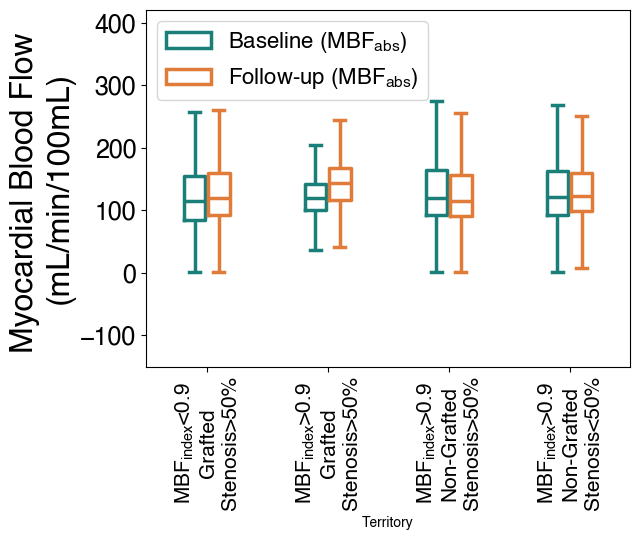

In [90]:
plt.figure(figsize=(6.5, 5.5))
ax = sns.boxplot(x='Territory', y='MBF', hue='Type', data= df_long, showfliers=False, width = 0.4,  linewidth=2.5, fill= False, gap=.1, palette={'Baseline ($\\mathrm{MBF_{abs}}$)':color1, 'Follow-up ($\\mathrm{MBF_{abs}}$)':color2})

ax.set_ylabel("Myocardial Blood Flow \n(mL/min/100mL)", fontsize = 23)
ax.tick_params(axis='x', rotation=90, labelsize=20)
ax.legend(loc = 'upper left', fontsize=16)
plt.xticks(fontsize=15)
plt.yticks(fontsize=18)
plt.ylim(-150,420)
plt.tight_layout()
plt.show()

In [91]:
median_mbf_ischemic_A = []
median_mbf_ischemic_B = []

for _, row in df[df['is_ischemic'] == True].iterrows():
    median_mbf_ischemic_A.append(np.median(row['absMBF_A']))
    median_mbf_ischemic_B.append(np.median(row['absMBF_B']))

p_value_ischemic = WilcoxonTest(median_mbf_ischemic_A, median_mbf_ischemic_B)

Wilcoxon test statistics:  583.5
p-value:  0.009307430408555152
number of datapoints: 61
Reject the null hypothesis: There is a significant difference between the two samples.


In [92]:
median_mbf_nonischemic_A = []
median_mbf_nonischemic_B = []

for _, row in df[(df['is_ischemic'] == False) & (df['tag'] != 'Non-grafted\nstenosis<50%') & (df['tag'] != "Non-grafted\nstenosis>50%")].iterrows():
    median_mbf_nonischemic_A.append(np.median(row['absMBF_A']))
    median_mbf_nonischemic_B.append(np.median(row['absMBF_B']))

p_value_non_ischemic = WilcoxonTest(median_mbf_nonischemic_A, median_mbf_nonischemic_B)

Wilcoxon test statistics:  4.5
p-value:  0.03125
number of datapoints: 9
Reject the null hypothesis: There is a significant difference between the two samples.


In [93]:
median_mbf_stng_A = []
median_mbf_stng_B = []

for _, row in df[df['tag'] == 'Non-grafted\nstenosis>50%'].iterrows():
    median_mbf_stng_A.append(np.median(row['absMBF_A']))
    median_mbf_stng_B.append(np.median(row['absMBF_B']))

p_value_nongrafted_stenosis = WilcoxonTest(median_mbf_stng_A, median_mbf_stng_B)

Wilcoxon test statistics:  31.0
p-value:  0.8984375
number of datapoints: 11
Fail to reject the null hypothesis: There is no significant difference between the two samples.


In [94]:
median_mbf_ng_A = []
median_mbf_ng_B = []

for _, row in df[df['tag'] == 'Non-grafted\nstenosis<50%'].iterrows():
    median_mbf_ng_A.append(np.median(row['absMBF_A']))
    median_mbf_ng_B.append(np.median(row['absMBF_B']))

p_value_nongrafted = WilcoxonTest(median_mbf_ng_A, median_mbf_ng_B)

Wilcoxon test statistics:  158.5
p-value:  0.6658231695349112
number of datapoints: 26
Fail to reject the null hypothesis: There is no significant difference between the two samples.


In [95]:
print("TerritoryTag", "Median", "IQR", "Mean", "std")
mbf_ischemic10_A = np.concatenate(df[df['ischemic_grade'] == 1]['absMBF_A'].values)
q1, q2, q3 = np.percentile(mbf_ischemic10_A, [25, 50, 75])
average = np.mean(mbf_ischemic10_A)
std = np.std(mbf_ischemic10_A)
print("ischemic_grafted10_A", q2, q3-q1, average, std)

mbf_ischemic10_B = np.concatenate(df[df['ischemic_grade'] == 1]['absMBF_B'].values)
q1, q2, q3 = np.percentile(mbf_ischemic10_B, [25, 50, 75])
average = np.mean(mbf_ischemic10_B)
std = np.std(mbf_ischemic10_B)
print("ischemic_grafted10_B",q2, q3-q1, average, std)

mbf_ischemic20_A = np.concatenate(df[df['ischemic_grade'] == 2]['absMBF_A'].values)
q1, q2, q3 = np.percentile(mbf_ischemic20_A, [25, 50, 75])
average = np.mean(mbf_ischemic20_A)
std = np.std(mbf_ischemic20_A)
print("ischemic_grafted20_A", q2, q3-q1, average, std)

mbf_ischemic20_B = np.concatenate(df[df['ischemic_grade'] == 2]['absMBF_B'].values)
q1, q2, q3 = np.percentile(mbf_ischemic20_B, [25, 50, 75])
average = np.mean(mbf_ischemic20_B)
std = np.std(mbf_ischemic20_B)
print("ischemic_grafted20_B",q2, q3-q1, average, std)

mbf_ischemic30_A = np.concatenate(df[df['ischemic_grade'] == 3]['absMBF_A'].values)
q1, q2, q3 = np.percentile(mbf_ischemic30_A, [25, 50, 75])
average = np.mean(mbf_ischemic30_A)
std = np.std(mbf_ischemic30_A)
print("ischemic_grafted30_A", q2, q3-q1, average, std)

mbf_ischemic30_B = np.concatenate(df[df['ischemic_grade'] == 3]['absMBF_B'].values)
q1, q2, q3 = np.percentile(mbf_ischemic30_B, [25, 50, 75])
average = np.mean(mbf_ischemic30_B)
std = np.std(mbf_ischemic30_B)
print("ischemic_grafted30_B",q2, q3-q1, average, std)

mbf_nonischemic_A = np.concatenate(df[(df['ischemic_grade'] == 0) & (df['tag'] != 'Non-grafted\nstenosis<50%') & (df['tag'] != "Non-grafted\nstenosis>50%")]['absMBF_A'].values)
q1, q2, q3 = np.percentile(mbf_nonischemic_A, [25, 50, 75])
average = np.mean(mbf_nonischemic_A)
std = np.std(mbf_nonischemic_A)
print("nonischemic_grafted_A", q2, q3-q1, average, std)

mbf_nonischemic_B = np.concatenate(df[(df['ischemic_grade'] == 0) & (df['tag'] != 'Non-grafted\nstenosis<50%') & (df['tag'] != "Non-grafted\nstenosis>50%")]['absMBF_B'].values)
q1, q2, q3 = np.percentile(mbf_nonischemic_B, [25, 50, 75])
average = np.mean(mbf_nonischemic_B)
std = np.std(mbf_nonischemic_B)
print("nonischemic_grafted_B", q2, q3-q1, average, std)


TerritoryTag Median IQR Mean std
ischemic_grafted10_A 127.0 59.0 138.30215624829717 55.19366095182878
ischemic_grafted10_B 119.0 61.0 132.116607494282 57.55661672404265
ischemic_grafted20_A 112.0 66.0 130.46810220712965 69.75768695244811
ischemic_grafted20_B 122.0 68.0 136.35232923761114 66.91608842379854
ischemic_grafted30_A 93.0 72.0 110.72245032482378 69.80291414328818
ischemic_grafted30_B 116.0 71.0 129.70707725779002 63.42115170881515
nonischemic_grafted_A 120.0 42.0 122.89959457217743 38.480603143948706
nonischemic_grafted_B 143.0 51.0 145.7849222550573 49.17336952736123


In [96]:
# Create a DataFrame with each part
df_A = pd.DataFrame({
    'MBF': np.concatenate([mbf_ischemic30_A, mbf_ischemic20_A, mbf_ischemic10_A, mbf_nonischemic_A]),
    'Territory': ['<0.7'] * len(mbf_ischemic30_A) +
             ['0.7-0.8'] * len(mbf_ischemic20_A) +
             ['0.8-0.9'] * len(mbf_ischemic10_A) + 
             ['>0.9'] * len(mbf_nonischemic_A),  
    'Type': ['Baseline ($\\mathrm{MBF_{abs}}$)'] * (len(mbf_ischemic30_A) +len(mbf_ischemic20_A) +len(mbf_ischemic10_A) + len(mbf_nonischemic_A))
})

df_B = pd.DataFrame({
    'MBF': np.concatenate([mbf_ischemic30_B, mbf_ischemic20_B, mbf_ischemic10_B, mbf_nonischemic_B]),
    'Territory': ['<0.7'] * len(mbf_ischemic30_B) +
             ['0.7-0.8'] * len(mbf_ischemic20_B) +
             ['0.8-0.9'] * len(mbf_ischemic10_B) + 
             ['>0.9'] * len(mbf_nonischemic_B),
    'Type': ['Follow-up ($\\mathrm{MBF_{abs}}$)'] * (len(mbf_ischemic30_B) + len(mbf_ischemic20_B) + len(mbf_ischemic10_B) + len(mbf_nonischemic_B))
})

# Combine into a single DataFrame
df_long = pd.concat([df_A, df_B], ignore_index=True)

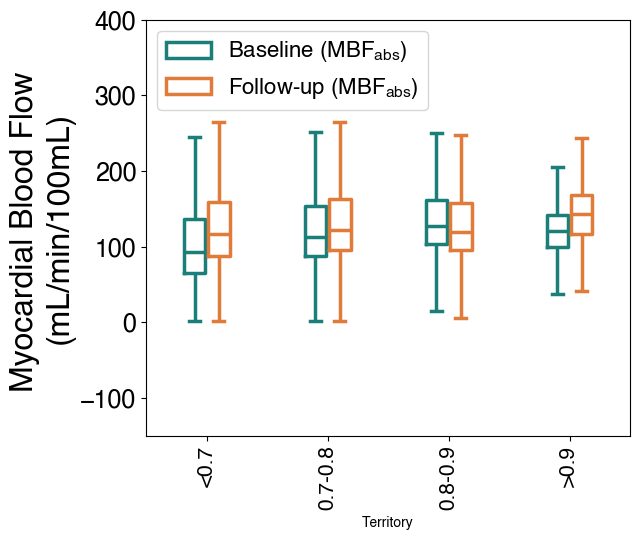

In [97]:
plt.figure(figsize=(6.5, 5.5))
ax = sns.boxplot(x='Territory', y='MBF', hue='Type', data= df_long, showfliers=False, width = 0.4, linewidth=2.5, fill= False, gap=.1, palette={'Baseline ($\\mathrm{MBF_{abs}}$)':color1, 'Follow-up ($\\mathrm{MBF_{abs}}$)':color2})

ax.set_ylabel("Myocardial Blood Flow \n(mL/min/100mL)", fontsize = 23)
ax.tick_params(axis='x', rotation=90, labelsize=18)
ax.legend(loc = 'upper left', fontsize=16)
plt.xticks(fontsize=15)
plt.yticks(fontsize=18)
plt.ylim(-150,400)
plt.tight_layout()
plt.show()

In [98]:
median_mbf_ischemic10_A = []
median_mbf_ischemic10_B = []

for _, row in df[df['ischemic_grade'] == 1].iterrows():
    median_mbf_ischemic10_A.append(np.median(row['absMBF_A']))
    median_mbf_ischemic10_B.append(np.median(row['absMBF_B']))

WilcoxonTest(median_mbf_ischemic10_A, median_mbf_ischemic10_B)

Wilcoxon test statistics:  95.5
p-value:  0.4866961011303135
number of datapoints: 21
Fail to reject the null hypothesis: There is no significant difference between the two samples.


np.float64(0.4866961011303135)

In [99]:
median_mbf_ischemic20_A = []
median_mbf_ischemic20_B = []

for _, row in df[df['ischemic_grade'] == 2].iterrows():
    median_mbf_ischemic20_A.append(np.median(row['absMBF_A']))
    median_mbf_ischemic20_B.append(np.median(row['absMBF_B']))

WilcoxonTest(median_mbf_ischemic20_A, median_mbf_ischemic20_B)

Wilcoxon test statistics:  58.5
p-value:  0.08230190177584372
number of datapoints: 20
Fail to reject the null hypothesis: There is no significant difference between the two samples.


np.float64(0.08230190177584372)

In [100]:
median_mbf_ischemic30_A = []
median_mbf_ischemic30_B = []

for _, row in df[df['ischemic_grade'] == 3].iterrows():
    median_mbf_ischemic30_A.append(np.median(row['absMBF_A']))
    median_mbf_ischemic30_B.append(np.median(row['absMBF_B']))

WilcoxonTest(median_mbf_ischemic30_A, median_mbf_ischemic30_B)

Wilcoxon test statistics:  21.0
p-value:  0.000850677490234375
number of datapoints: 20
Reject the null hypothesis: There is a significant difference between the two samples.


np.float64(0.000850677490234375)

In [101]:
median_mbf_ischemic0_A = []
median_mbf_ischemic0_B = []

for _, row in df[(df['ischemic_grade'] == 0) & (df['tag'] != 'Non-grafted\nstenosis<50%') & (df['tag'] != "Non-grafted\nstenosis>50%")].iterrows():
    median_mbf_ischemic0_A.append(np.median(row['absMBF_A']))
    median_mbf_ischemic0_B.append(np.median(row['absMBF_B']))

WilcoxonTest(median_mbf_ischemic0_A, median_mbf_ischemic0_B)

Wilcoxon test statistics:  4.5
p-value:  0.03125
number of datapoints: 9
Reject the null hypothesis: There is a significant difference between the two samples.


np.float64(0.03125)